# TEG-CL: Temporal Ego-Graph Continual Learning for AML Detection

Compares 10 continual-learning strategies (Bare, Joint, GEM, EWC, TWP, TEG-CL,
Node-Replay, DER++, EgoCL, SEA-ER) on a GraphSAGE backbone over 7 sequential
temporal tasks drawn from the Elliptic Bitcoin dataset, testing whether
ego-graph replay preserves relational fraud patterns better than isolated
node replay during continual learning.

**Two flags govern this notebook's entire behavior and are set in Cell 1:**

- **`QUICK_TEST`** -  a Fast, small-scale pass to validate the pipeline executes end to end.
- **`CONFIRMATORY_RUN`** - a Full Run. It gates the multi-seed confirmatory phase that produces the statistics reported in the dissertation, as opposed to the faster single-seed exploratory runs used earlier in the notebook.

The BATCH 1 and BATCH 2 gate cells are checkpoints.

### Dataset
https://www.kaggle.com/datasets/ellipticco/elliptic-data-set/
https://pytorch-geometric.readthedocs.io/en/2.5.2/generated/torch_geometric.datasets.EllipticBitcoinDataset.html

In [ ]:
# @title Start Time

import datetime
start_time = datetime.datetime.now()
print(start_time)
print('\n')


2026-08-24 09:35:13.548070




## Setup

Environment verification, GPU profile and path resolution, package
installation with explicit sampler-backend validation, the single source of
truth configuration, reproducibility utilities, and checkpoint management.

In [ ]:
# @title Cell 0: Runtime Environment Check
import sys, torch
print(f"In Colab: {'google.colab' in sys.modules}")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda if torch.cuda.is_available() else 'N/A'}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    !nvidia-smi
print('\n')


In Colab: False
Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA: 12.8
GPU: Tesla T4
VRAM: 15.6 GB
Mon Aug 24 09:35:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |    

In [ ]:
# @title Cell 1: Environment, GPU profile, paths

import sys, os, warnings
warnings.filterwarnings('ignore')

# Detects the runtime platform and mounts Drive in Colab.
IS_COLAB  = 'google.colab' in sys.modules
IS_KAGGLE = 'kaggle_secrets' in sys.modules
if IS_COLAB:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    ROOT = '/content/drive/MyDrive/teg-cl-v3.5.10k'
elif IS_KAGGLE:
    ROOT = '/kaggle/working/teg-cl-v3.5.10k'
else:
    ROOT = os.path.expanduser('~/teg-cl-v3.5.10k')

# Creates every working folder under ROOT.
for d in [f'{ROOT}/configs', f'{ROOT}/data/raw', f'{ROOT}/data/splits',
          f'{ROOT}/checkpoints', f'{ROOT}/results', f'{ROOT}/logs']:
    os.makedirs(d, exist_ok=True)

import torch
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.matmul.allow_tf32 = True

HAS_GPU = torch.cuda.is_available()

# Picks batch/hidden/neighbor/buffer sizes based on available VRAM.
if HAS_GPU:
    VRAM   = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"[GPU] {torch.cuda.get_device_name(0)} | {VRAM:.1f} GB | CUDA {torch.version.cuda}")
    if VRAM >= 15:                                   # T4 16 GB
        BATCH, HIDDEN, NEIGHBORS, BUFFER, RBATCH = 4096, 256, [20,15], 500, 128
    elif VRAM >= 10:                                 # T4 10 GB (throttled)
        BATCH, HIDDEN, NEIGHBORS, BUFFER, RBATCH = 2048, 256, [15,10], 500, 32
    else:                                            # low-VRAM fallback
        BATCH, HIDDEN, NEIGHBORS, BUFFER, RBATCH =  512, 128, [10, 5], 250, 16
else:
    VRAM = 0.0
    BATCH, HIDDEN, NEIGHBORS, BUFFER, RBATCH = 256, 128, [10,5], 200, 16
    print('[WARN] No GPU - CPU only (slow)')

print(f"[CFG] batch={BATCH} hidden={HIDDEN} neighbors={NEIGHBORS} buffer={BUFFER}")
print(f"[PATH] {ROOT}")

# QUICK_TEST toggle
# True  = fast validation run
# False = full production run

QUICK_TEST = False   # Replace: True = fast validation,  False = full run

if QUICK_TEST:
    _num_tasks     = 2
    _task_split    = [1, 1]
    _local_epochs  = 1
    _n_seeds       = 1
    _n_bootstrap   = 100
    _buffer_size   = 100
    _replay_batch  = 8
    _batch_size    = min(BATCH, 128)
    _hidden_dim    = min(HIDDEN, 32)
    _num_neighbors = [10, 5]
    print('\n[QUICK_TEST] ON - fast validation: 2 tasks, 5 epochs, 1 seed')
else:
    _num_tasks     = 7
    _task_split    = [7, 7, 7, 7, 7, 7, 7]
    _local_epochs  = 50
    _n_seeds       = 5
    _n_bootstrap   = 1000
    _buffer_size   = BUFFER
    _replay_batch  = RBATCH
    _batch_size    = BATCH
    _hidden_dim    = HIDDEN
    _num_neighbors = NEIGHBORS
    print('\n[QUICK_TEST] OFF - full production run: 7 tasks, 50 epochs, 5 seeds')


# Each flag lets its corresponding downstream cell be skipped independently.
RUN_PHASE1       = True   # Cell 12/15a - core methods (Bare, EWC, TWP, TEG-CL)
RUN_PHASE2       = True   # Cell 12/15b - extended methods (Joint, GEM, DER++, EgoCL, Node-Replay)
RUN_ABLATIONS    = True   # Cell 14     - 17-config ablation suite
RUN_MULTISEED    = True   # Cell 15a/15b - statistical validation
RUN_ITGS         = True   # Cell 16     - inter-task gradient similarity
RUN_2D_GRID      = True   # Cell 21a    - buffer x lambda 2D ablation grid
RUN_PR_CURVES    = True   # Cell 21b    - precision-recall curves, all methods
RUN_LOSS_DECOMP  = True   # Cell 21c    - task vs replay loss decomposition
RUN_HITSK        = True   # Cell 23     - Hits@K / P@K investigator metrics
RUN_TIMING       = True   # Cell 24     - train/val/test wall-clock timing
RUN_H2GCN_TEST   = True   # Cell 25     - H2GCN heterophily-awareness test

# CONFIRMATORY_RUN selects which seed set this notebook uses: the exploratory
# set {42,123,456,789,999} for tuning, ablations, sensitivity/robustness, and
# Cell 23's exploratory multi-seed stats, or the disjoint confirmatory set
# {1001,2002,3003,4004,5005} for validating a locked-in config on seeds that
# never influenced any tuning decision. A complete run means running this
# notebook twice, once at each setting; running only once, or at False both
# times, defeats the purpose the confirmatory phase exists for.
CONFIRMATORY_RUN = False   # True = use {1001,2002,3003,4004,5005}

print(f"\n[FLAGS] Phase1={RUN_PHASE1} Phase2={RUN_PHASE2} "
      f"Ablations={RUN_ABLATIONS} MultiSeed={RUN_MULTISEED} ITGS={RUN_ITGS}")
print(f"[FLAGS] 2DGrid={RUN_2D_GRID} PRCurves={RUN_PR_CURVES} "
      f"LossDecomp={RUN_LOSS_DECOMP} HitsK={RUN_HITSK} "
      f"Timing={RUN_TIMING} H2GCN={RUN_H2GCN_TEST}")
print('\n')


[GPU] Tesla T4 | 15.6 GB | CUDA 12.8
[CFG] batch=4096 hidden=256 neighbors=[20, 15] buffer=500
[PATH] /root/teg-cl-v3.5.10k

[QUICK_TEST] OFF - full production run: 7 tasks, 50 epochs, 5 seeds

[FLAGS] Phase1=True Phase2=True Ablations=True MultiSeed=True ITGS=True
[FLAGS] 2DGrid=True PRCurves=True LossDecomp=True HitsK=True Timing=True H2GCN=True




In [ ]:
# @title Cell 2: Package installation
import subprocess


# Runs pip quietly and reports success as a bool.
def _pip(*args):
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *args],
                       capture_output=True)
    return r.returncode == 0

# Core library
if not _pip('torch-geometric>=2.6.0'):
    _pip('--pre', 'torch-geometric')

# Compiled speed extensions () NeighborLoader requires pyg-lib OR torch sparse)
_tv = torch.__version__
_sampler_ok = False
for _ext in ('pyg-lib', 'torch-sparse', 'torch-scatter'):
    _ok = _pip('--no-index', '-f',
               f'https://data.pyg.org/whl/torch-{_tv}.html', _ext)
    if _ext in ('pyg-lib', 'torch-sparse') and _ok:
        _sampler_ok = True
    print(f'   {_ext}: {"installed" if _ok else "not available for this torch build"}')

if not _sampler_ok:
    _sampler_ok = _pip('pyg-lib') or _pip('torch-sparse')

if not _sampler_ok:
    raise RuntimeError(
        'Neither pyg-lib nor torch-sparse installed - NeighborLoader will fail. '
        'Check torch version compatibility: '
        f'torch={_tv}, or switch to a supported Kaggle/Colab runtime.'
    )


# Everything else the pipeline needs
_pip('scikit-learn', 'scipy', 'pandas', 'matplotlib', 'pyyaml', 'tqdm', 'networkx', 'openpyxl')

# Functional smoke test, prove PyG actually works, not just imports
try:
    from torch_geometric.nn       import SAGEConv
    from torch_geometric.loader   import NeighborLoader
    from torch_geometric.datasets import EllipticBitcoinDataset
    from torch_geometric.utils    import k_hop_subgraph, subgraph
    from torch_geometric.typing   import WITH_PYG_LIB, WITH_TORCH_SPARSE

    _x = torch.randn(10, 5)
    _e = torch.tensor([[0,1,2,3],[1,2,3,4]])
    assert SAGEConv(5, 8)(_x, _e).shape == (10, 8), 'SAGEConv shape wrong'
    print('  PyG functional test passed')
    print('WITH_PYG_LIB:', WITH_PYG_LIB)
    print('WITH_TORCH_SPARSE:', WITH_TORCH_SPARSE)
except Exception as _err:
    raise RuntimeError(f'PyG import/test failed: {_err}\n'
                       'Try: Runtime -> Factory reset runtime, then re-run.')
print('\n')


   pyg-lib: installed
   torch-sparse: installed
   torch-scatter: installed
  PyG functional test passed
WITH_PYG_LIB: True
WITH_TORCH_SPARSE: True




In [ ]:
# @title Cell 3: Configuration (single source of truth)

import yaml

# Builds the config YAML from the values computed in Cell 1.
_cfg_text = f"""
hardware:
  device:      {"cuda" if HAS_GPU else "cpu"}
  random_seed: 42
  num_workers: 2
  pin_memory:  true

dataset:
  root:                 {ROOT}/data/raw
  task_split:           {_task_split}
  train_ratio:          0.70
  val_ratio:            0.10
  test_ratio:           0.20
  normalization_method: standard

model:
  input_dim:      165
  base_input_dim: 165
  hidden_dim:  {_hidden_dim}
  num_layers:  2
  num_neighbors: {_num_neighbors}
  dropout:     0.3
  num_classes: 1

training:
  local_epochs:              {_local_epochs}
  batch_size:                {_batch_size}
  learning_rate:             0.001
  weight_decay:              0.0005
  scheduler_factor:          0.5
  scheduler_patience:        10
  scheduler_min_lr:          1.0e-6
  early_stopping_patience:   15
  max_grad_norm:             1.0
  mixed_precision:           {str(HAS_GPU).lower()}

loss:
  pos_weight: 10.0
  gamma:      2.0

continual:
  tegr:
    replay_buffer_size:  {_buffer_size}
    replay_batch_size:   {_replay_batch}
    replay_lambda:       1.0
    ego_graph_hops:      2
    selection_strategy:  coverage
    stratified_ratio:    0.5
  gem:
    memory_size: {_buffer_size}
  ewc:
    lambda:           1000.0
    fisher_samples:   200
    fisher_batch_size: 64
  twp:
    lambda:             1000.0
    importance_samples: 200
  derpp:
    buffer_size:  {_buffer_size}
    replay_batch_size: {_replay_batch}
    ego_graph_hops: 2
    alpha:        0.1
    beta:         0.5
  egocl:
    buffer_size:      {_buffer_size}
    replay_batch_size: {_replay_batch}
    ego_graph_hops:   2
  seaer:
    buffer_size:        {_buffer_size}
    replay_batch_size:  {_replay_batch}
    replay_lambda:      1.0
    ego_graph_hops:     2
    stratified:         true
    stratified_ratio:   0.5
    drift_temperature:  1.0

evaluation:
  n_seeds:          {_n_seeds}
  n_bootstrap:      {_n_bootstrap}
  confirmatory_seeds: [1001, 2002, 3003, 4004, 5005]
  confidence_level: 0.95

logging:
  checkpoint_dir: {ROOT}/checkpoints
  results_dir:    {ROOT}/results
"""

_cfg_path = f'{ROOT}/configs/colab_config.yaml'
with open(_cfg_path, 'w') as _f:
    _f.write(_cfg_text)

# Writes it to disk and loads it back as the single source of truth.
CONFIG = yaml.safe_load(_cfg_text)

print('[CONFIG] Written ->', _cfg_path)
print(f"  input_dim={CONFIG['model']['input_dim']}  "
      f"hidden={CONFIG['model']['hidden_dim']}  "
      f"batch={CONFIG['training']['batch_size']}  "
      f"buffer={CONFIG['continual']['tegr']['replay_buffer_size']}  "
      f"amp={CONFIG['training']['mixed_precision']}")
print('\n')


[CONFIG] Written -> /root/teg-cl-v3.5.10k/configs/colab_config.yaml
  input_dim=165  hidden=256  batch=4096  buffer=500  amp=True




In [ ]:
# @title Cell 4: Reproducibility utilities
import random
import numpy as np

# Single source of truth for the multi-seed list: confirmatory seeds come from config, exploratory seeds are fixed.
def resolve_seeds(cfg: dict, confirmatory: bool) -> list:
    if confirmatory:
        return cfg['evaluation'].get('confirmatory_seeds', [1001,2002,3003,4004,5005])
    return [42, 123, 456, 789, 999]

# Fixes every source of randomness for reproducible runs.
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)

# Returns the GPU device if config wants CUDA and one is available, else CPU.
def get_device() -> torch.device:
    if CONFIG['hardware']['device'] == 'cuda' and torch.cuda.is_available():
        return torch.device('cuda:0')
    return torch.device('cpu')

# Sets default seed and device now; each experiment re-calls set_seed(s) before it runs.
DEVICE = get_device()
set_seed(CONFIG['hardware']['random_seed'])
print(f'[SEED] 42  [DEVICE] {DEVICE}')
print('\n')


[SEED] 42  [DEVICE] cuda:0




In [ ]:
# @title Cell 5: Checkpoint manager

import glob, time

# Save to Drive, find latest, resumes
class CheckpointManager:


    # Sets the save location and creates it on disk immediately.
    def __init__(self, save_dir: str = None, interval_min: int = 10):
        self.save_dir    = save_dir or CONFIG['logging']['checkpoint_dir']
        os.makedirs(self.save_dir, exist_ok=True)
        self.interval    = interval_min * 60
        self._last_save  = 0.0

    # Only calls save in intervals have passed since the last save.
    def maybe_save(self, model, optimizer, epoch: int, task: int, metrics=None):
        if time.time() - self._last_save >= self.interval:
            self.save(model, optimizer, epoch, task, metrics)

    # Writes model and optimizer state to disk, tagged with task, epoch, and timestamp.
    def save(self, model, optimizer, epoch: int, task: int, metrics=None):
        path = f'{self.save_dir}/task{task}_ep{epoch}_{int(time.time())}.pt'
        state = {
            'epoch':     epoch,
            'task':      task,
            'model':     model.state_dict(),
            'optimizer': optimizer.state_dict(),
        }
        if metrics:
            state['metrics'] = metrics
        torch.save(state, path)
        self._last_save = time.time()
        print(f' {path}')

    # Finds the most recently saved checkpoint file, based on its timestamp.
    def latest(self) -> str | None:
        files = glob.glob(f'{self.save_dir}/task*_ep*_*.pt')
        if not files:
            return None
        return max(files, key=lambda p: int(p.rsplit('_', 1)[-1][:-3]))

    # Loads the latest checkpoint, falling back to a fresh start if it doesn't match the current model. Returns (start_epoch, start_task).
    def resume(self, model, optimizer) -> tuple[int, int]:
        path = self.latest()
        if not path:
            print('[RESUME] No checkpoint - starting fresh')
            return 0, 0
        ckpt = torch.load(path, map_location='cpu', weights_only=True)
        try:
            model.load_state_dict(ckpt['model'])
            optimizer.load_state_dict(ckpt['optimizer'])
        except RuntimeError as ex:
            print(f'  [RESUME] Stale checkpoint incompatible with current '
                  f'model shape - starting fresh instead of resuming.\n'
                  f'    ({path})\n    {str(ex).splitlines()[0]}')
            return 0, 0
        print(f' Resumed task={ckpt["task"]} epoch={ckpt["epoch"]}  <- {path}')
        return ckpt['epoch'] + 1, ckpt['task']

print('  CheckpointManager ready')
print('\n')


  CheckpointManager ready




## Data

Loads the Elliptic Bitcoin dataset, splits it into 7 temporal tasks, explores
class distribution and feature structure, then gates on data integrity
before any model touches it.

In [ ]:
# @title Cell 6: Data loading, task splitting, normalisation
import json
import pandas as pd
from torch_geometric.datasets import EllipticBitcoinDataset
from torch_geometric.data     import Data
from torch_geometric.utils    import subgraph
from sklearn.preprocessing    import StandardScaler

# 6a: Load Elliptic dataset and attach per-node timestep
def load_elliptic(root: str) -> Data:
    data = EllipticBitcoinDataset(root=root)[0]

    # CSV found in one of these locations depending on PyG version
    candidates = [
        f'{root}/elliptic/raw/elliptic_txs_features.csv',
        f'{root}/raw/elliptic_txs_features.csv',
        *glob.glob(f'{root}/**/elliptic_txs_features.csv', recursive=True),
    ]
    csv = next((p for p in candidates if os.path.exists(p)), None)

    if csv:
        data.time = torch.from_numpy(pd.read_csv(csv, header=None)[1].values).long()
        print(f'[DATA] Timestep from {csv}')
    else:
        data.time = torch.zeros(data.num_nodes, dtype=torch.long)
        print('[WARN] elliptic_txs_features.csv not found - timestep zeroed')

    return data

# 6b: Splits nodes into 7 temporal tasks + train/val/test per task
class EllipticTaskSplitter:

    # Validates the split ratios, then assigns tasks and builds train/val/test splits.
    def __init__(self, data: Data, task_split: list,
                 train_r: float, val_r: float, seed=42):
        assert 0 < train_r < 1 and 0 < val_r < 1 and train_r + val_r <= 1.0, (
            f'Invalid split: train_r={train_r}, val_r={val_r} - '
            f'both must be in (0,1) and sum to <= 1.0')
        self.data       = data
        self.num_tasks  = len(task_split)
        self._labeled   = (data.y == 0) | (data.y == 1)   # boolean mask [N]
        self._assign    = self._assign_tasks(task_split, data.time)
        self._splits    = self._make_splits(train_r, val_r, seed)

    # Maps each node's timestep to a task index (0-6).
    @staticmethod
    def _assign_tasks(task_split: list, time: torch.Tensor) -> torch.Tensor:
        assign = torch.full((time.size(0),), -1, dtype=torch.long, device=time.device)
        if time.max() == 0:
            assign[:] = 0
            return assign
        start = 1
        for ti, n in enumerate(task_split):
            assign[(time >= start) & (time < start + n)] = ti
            start += n
        assign[assign == -1] = len(task_split) - 1
        return assign

    # Randomly splits each task's labeled nodes into train/val/test.
    def _make_splits(self, train_r, val_r, seed) -> list:
        torch.manual_seed(seed)
        splits = []
        for ti in range(self.num_tasks):
            labeled = torch.where((self._assign == ti) & self._labeled)[0]
            if len(labeled) == 0:
                empty = torch.tensor([], dtype=torch.long)
                splits.append({k: empty for k in ('train','val','test','all_labeled')})
                splits[-1]['all_task'] = torch.where(self._assign == ti)[0]
                continue
            perm   = torch.randperm(len(labeled))
            labeled = labeled[perm]
            n      = len(labeled)
            nt, nv = int(n * train_r), int(n * val_r)
            splits.append({
                'train':       labeled[:nt],
                'val':         labeled[nt:nt+nv],
                'test':        labeled[nt+nv:],
                'all_labeled': labeled,
                'all_task':    torch.where(self._assign == ti)[0],
            })
        return splits

    # Returns the split dict for a given task index.
    def get(self, task_idx: int) -> dict:
        return self._splits[task_idx]

    # Persists all splits to disk as JSON.
    def save(self, path: str):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        with open(path, 'w') as f:
            json.dump({f'task_{i}': {k: v.tolist() for k,v in s.items()}
                       for i, s in enumerate(self._splits)}, f)

# 6c: Fits a scaler on Task 0's training nodes only, then applies it globally.
def normalize_features(data: Data, train_idx: torch.Tensor,
                        method='standard') -> Data:
    if len(train_idx) == 0:
        return data
    x    = data.x.cpu().numpy()
    scaler = StandardScaler()
    scaler.fit(x[train_idx.cpu().numpy()])
    data.x = torch.from_numpy(scaler.transform(x)).float().to(data.x.device)
    return data

# 6d: Extracts each task's subgraph and remaps node indices for the trainer.
def build_task_list(data: Data, splitter: EllipticTaskSplitter,
                    device: torch.device) -> list:
    task_list = []
    for ti in range(splitter.num_tasks):
        idx        = splitter.get(ti)
        task_nodes = idx['all_task']
        if len(task_nodes) == 0:
            print(f'[SKIP] Task {ti} empty')
            continue

        ei_sub, _ = subgraph(task_nodes, data.edge_index,
                              relabel_nodes=True, num_nodes=data.num_nodes)
        tg = Data(x          = data.x[task_nodes],
                  edge_index = ei_sub,
                  y          = data.y[task_nodes],
                  time       = data.time[task_nodes]).to(device)

        nmap = {int(old): new for new, old in enumerate(task_nodes.tolist())}
        remap = {k: torch.tensor([nmap[i] for i in v.tolist() if i in nmap],
                                  dtype=torch.long, device=device)
                 for k, v in idx.items()}

        task_list.append({
            'data':         tg,
            'indices':      remap,
            'labeled_mask': (tg.y == 0) | (tg.y == 1),
            'task_idx':     ti,
        })
    return task_list
print('\n')


In [ ]:
# @title Cell 7: EDA 1 Dataset Overview & Validation
import torch

_eda_raw = load_elliptic(CONFIG['dataset']['root'])

print('DATASET OVERVIEW')
print(f'  Nodes:            {_eda_raw.num_nodes:,}')
print(f'  Edges:             {_eda_raw.edge_index.size(1):,}')
print(f'  Node features:    {_eda_raw.num_node_features}')
print(f'  Timestep range:    {_eda_raw.time.min().item()} - {_eda_raw.time.max().item()}')

# Validation checks - report, don't assert (informational EDA, not a gate)
_dup_edges  = _eda_raw.edge_index.size(1) - torch.unique(_eda_raw.edge_index, dim=1).size(1)
_self_loops = (_eda_raw.edge_index[0] == _eda_raw.edge_index[1]).sum().item()
_nan_feats  = torch.isnan(_eda_raw.x).sum().item()
_isolated   = _eda_raw.num_nodes - torch.unique(_eda_raw.edge_index).numel()

print('\nVALIDATION')
print(f'  Duplicate edges:   {_dup_edges}')
print(f'  Self-loops:        {_self_loops}')
print(f'  NaN feature values:{_nan_feats}')
print(f'  Isolated nodes:    {_isolated}')

_labeled = ((_eda_raw.y == 0) | (_eda_raw.y == 1)).sum().item()
_unknown = (_eda_raw.y == -1).sum().item() if (_eda_raw.y == -1).any() else (_eda_raw.num_nodes - _labeled)
print(f'\n  Labeled nodes:     {_labeled:,} ({100*_labeled/_eda_raw.num_nodes:.1f}%)')
print(f'  Unknown nodes:     {_unknown:,} ({100*_unknown/_eda_raw.num_nodes:.1f}%)')

print('\n  EDA 1 complete')
print('\n')


Processing...
Done!


[DATA] Timestep from /root/teg-cl-v3.5.10k/data/raw/raw/elliptic_txs_features.csv
DATASET OVERVIEW
  Nodes:            203,769
  Edges:             234,355
  Node features:    165
  Timestep range:    1 - 49

VALIDATION
  Duplicate edges:   0
  Self-loops:        0
  NaN feature values:0
  Isolated nodes:    0

  Labeled nodes:     46,564 (22.9%)
  Unknown nodes:     157,205 (77.1%)

  EDA 1 complete




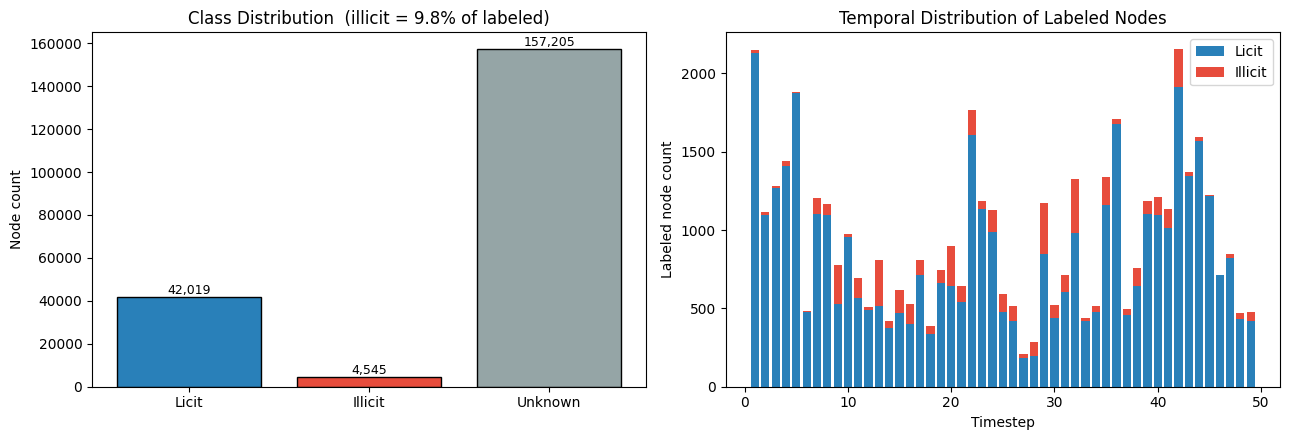

  Saved -> /root/teg-cl-v3.5.10k/results/eda_class_temporal.png


,Class,Count
0,Licit,42019
1,Illicit,4545
2,Unknown,157205


,Timestep,Licit,Illicit
0,1,2130,17
1,2,1099,18
2,3,1268,11
3,4,1410,30
4,5,1874,8
5,6,480,5
6,7,1101,102
7,8,1098,67
8,9,530,248
9,10,954,18


In [ ]:
# @title Cell 8: EDA 2 Class Distribution & Temporal Analysis
import matplotlib.pyplot as plt
import numpy as np

_y   = _eda_raw.y.cpu().numpy()
_t   = _eda_raw.time.cpu().numpy()
_lic = int((_y == 0).sum())
_ill = int((_y == 1).sum())
_unk = int((_y != 0).sum() - _ill) if (_y == -1).any() else int(_eda_raw.num_nodes - _lic - _ill)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Class balance
ax1.bar(['Licit', 'Illicit', 'Unknown'], [_lic, _ill, _unk],
        color=['#2980b9', '#e74c3c', '#95a5a6'], edgecolor='black')
ax1.set_ylabel('Node count')
ax1.set_title(f'Class Distribution  (illicit = {100*_ill/(_lic+_ill):.1f}% of labeled)')
for i, v in enumerate([_lic, _ill, _unk]):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Nodes per timestep, split by class
_steps = np.unique(_t)
_counts_lic = [((_t == s) & (_y == 0)).sum() for s in _steps]
_counts_ill = [((_t == s) & (_y == 1)).sum() for s in _steps]
ax2.bar(_steps, _counts_lic, label='Licit', color='#2980b9')
ax2.bar(_steps, _counts_ill, bottom=_counts_lic, label='Illicit', color='#e74c3c')
ax2.set_xlabel('Timestep')
ax2.set_ylabel('Labeled node count')
ax2.set_title('Temporal Distribution of Labeled Nodes')
ax2.legend()

plt.tight_layout()
_p = f"{CONFIG['logging']['results_dir']}/eda_class_temporal.png"
fig.savefig(_p, dpi=200, bbox_inches='tight')
plt.show()
print(f'  Saved -> {_p}')

import pandas as pd
from IPython.display import display
display(pd.DataFrame({'Class': ['Licit','Illicit','Unknown'],
                      'Count': [_lic, _ill, _unk]}))
display(pd.DataFrame({'Timestep': _steps, 'Licit': _counts_lic, 'Illicit': _counts_ill}))
print('\n')


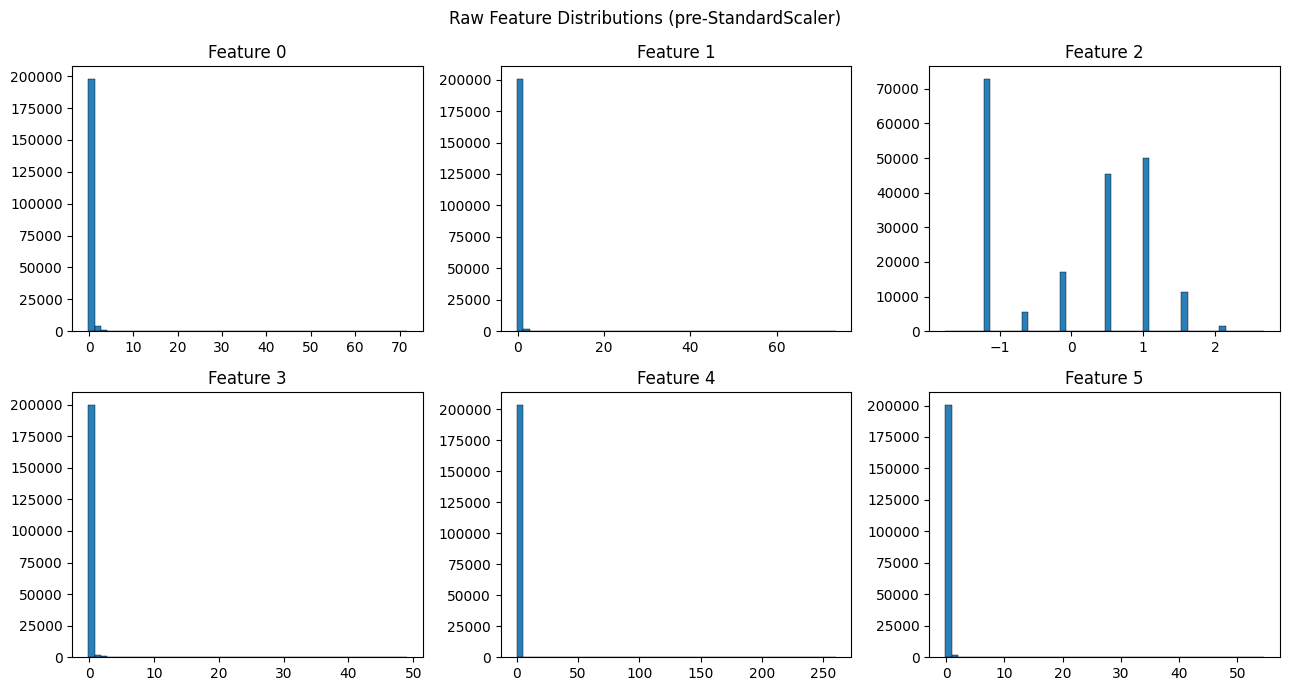

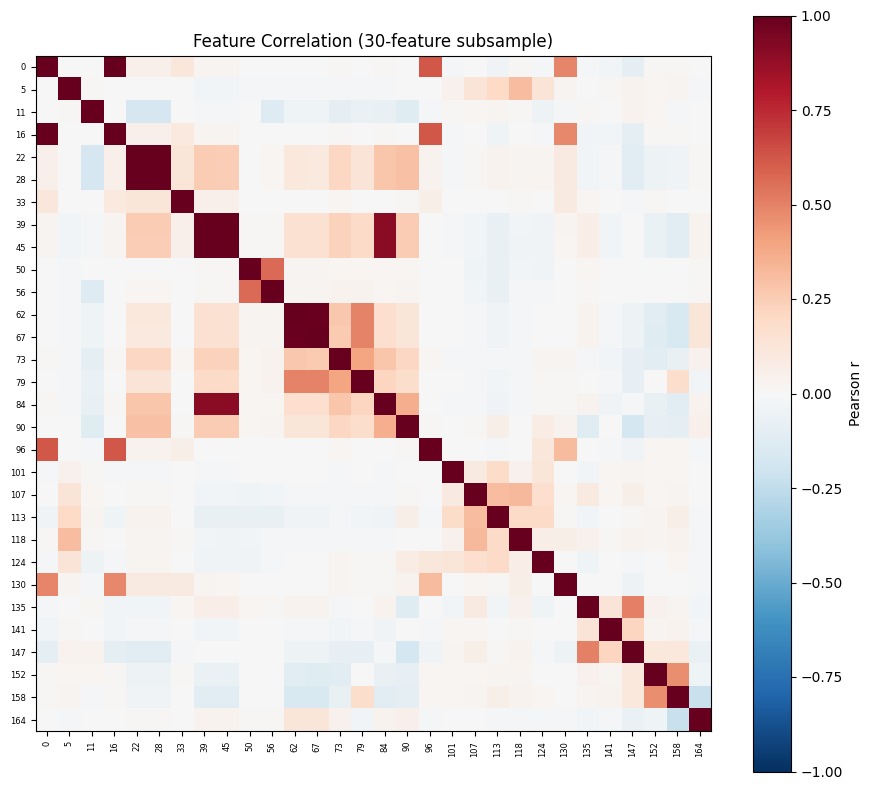

  Highly correlated pairs (|r|>0.9) in subsample: 6
  Saved -> /root/teg-cl-v3.5.10k/results/eda_feature_hist.png
  Saved -> /root/teg-cl-v3.5.10k/results/eda_feature_corr.png


,Feature,Mean,Std,Min,Max
0,0,-1.497656e-09,1.0,-0.172983,71.681969
1,1,-1.497656e-09,1.0,-0.210553,73.595055
2,2,5.271748e-08,1.0,-1.756361,2.683580
3,3,3.594373e-09,1.0,-0.121970,49.027599
4,4,-4.867381e-09,1.0,-0.063725,260.090698
5,5,-6.776891e-09,1.0,-0.113002,54.565178


,0,5,11,16,22,28,33,39,45,50,...,113,118,124,130,135,141,147,152,158,164
0,1.000000,0.005604,-0.001929,0.996121,0.054593,0.054542,0.111092,0.028885,0.029250,0.001813,...,-0.037531,0.011373,-0.011866,0.491129,-0.023004,-0.024098,-0.088230,0.015562,0.013022,-0.004607
5,0.005604,1.000000,0.012077,0.002954,0.006688,0.006673,-0.002774,-0.024973,-0.024973,-0.014563,...,0.202277,0.308399,0.130060,0.029450,0.002313,0.009624,0.036387,0.016733,0.024816,-0.011281
11,-0.001929,0.012077,1.000000,-0.001816,-0.166413,-0.166426,0.006510,-0.016852,-0.017374,0.004932,...,0.029752,0.013310,-0.046902,-0.011058,0.013858,0.000776,0.037186,0.020872,-0.010550,0.003325
16,0.996121,0.002954,-0.001816,1.000000,0.048576,0.048533,0.094374,0.028782,0.029317,0.002360,...,-0.039965,0.006253,-0.012462,0.483615,-0.023451,-0.023800,-0.087258,0.015161,0.012349,-0.004472
22,0.054593,0.006688,-0.166413,0.048576,1.000000,1.000000,0.123857,0.251755,0.244096,-0.003992,...,0.034344,0.030932,0.030449,0.090832,-0.030142,-0.022355,-0.103733,-0.048168,-0.034397,0.013739
28,0.054542,0.006673,-0.166426,0.048533,1.000000,1.000000,0.123399,0.251749,0.244090,-0.003992,...,0.034343,0.030914,0.030452,0.090791,-0.030157,-0.022354,-0.103732,-0.048176,-0.034401,0.013738
33,0.111092,-0.002774,0.006510,0.094374,0.123857,0.123399,1.000000,0.050522,0.047840,0.000716,...,-0.004104,0.015064,-0.002771,0.087214,0.021046,-0.003766,-0.014327,0.009137,0.003121,0.003418
39,0.028885,-0.024973,-0.016852,0.028782,0.251755,0.251749,0.050522,1.000000,0.993889,0.009139,...,-0.075368,-0.029488,-0.031767,0.023711,0.066709,-0.029773,0.007061,-0.066006,-0.105339,0.035499
45,0.029250,-0.024973,-0.017374,0.029317,0.244096,0.244090,0.047840,0.993889,1.000000,0.009539,...,-0.075943,-0.032062,-0.031753,0.022824,0.064988,-0.030110,0.004432,-0.066687,-0.104895,0.035669
50,0.001813,-0.014563,0.004932,0.002360,-0.003992,-0.003992,0.000716,0.009139,0.009539,1.000000,...,-0.072452,-0.026722,-0.031721,-0.004752,0.018519,0.006354,0.004597,-0.002573,-0.003833,0.008316


,Feature A,Feature B,r
0,0,16,0.9961
1,22,28,1.0000
2,39,45,0.9939
3,39,84,0.9002
4,45,84,0.9046
5,62,67,0.9897


In [ ]:
# @title Cell 9: EDA 3 Feature Distributions & Correlation
import matplotlib.pyplot as plt
import numpy as np

_x = _eda_raw.x.cpu().numpy()

# 3a: distributions of the first 6 raw features (of 165)
fig1, axes = plt.subplots(2, 3, figsize=(13, 7))
for i, ax in enumerate(axes.flat):
    ax.hist(_x[:, i], bins=50, color='#2980b9', edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature {i}')
plt.suptitle('Raw Feature Distributions (pre-StandardScaler)')
plt.tight_layout()
_p1 = f"{CONFIG['logging']['results_dir']}/eda_feature_hist.png"
fig1.savefig(_p1, dpi=200, bbox_inches='tight')
plt.show()

# 3b: correlation heatmap - subsample columns (165x165 is unreadable)
_sub_idx = np.linspace(0, _x.shape[1] - 1, 30, dtype=int)
_corr    = np.corrcoef(_x[:, _sub_idx].T)

fig2, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(_corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Feature Correlation (30-feature subsample)')
ax.set_xticks(range(len(_sub_idx))); ax.set_xticklabels(_sub_idx, rotation=90, fontsize=6)
ax.set_yticks(range(len(_sub_idx))); ax.set_yticklabels(_sub_idx, fontsize=6)
plt.tight_layout()
_p2 = f"{CONFIG['logging']['results_dir']}/eda_feature_corr.png"
fig2.savefig(_p2, dpi=200, bbox_inches='tight')
plt.show()

_high_corr = np.argwhere((np.abs(_corr) > 0.9) & ~np.eye(len(_sub_idx), dtype=bool))
print(f'  Highly correlated pairs (|r|>0.9) in subsample: {len(_high_corr)//2}')
print(f'  Saved -> {_p1}')
print(f'  Saved -> {_p2}')

import pandas as pd
from IPython.display import display
display(pd.DataFrame({'Feature': range(6),
                      'Mean': _x[:, :6].mean(axis=0), 'Std': _x[:, :6].std(axis=0),
                      'Min': _x[:, :6].min(axis=0), 'Max': _x[:, :6].max(axis=0)}))
display(pd.DataFrame(_corr, index=_sub_idx, columns=_sub_idx))
if len(_high_corr):
    display(pd.DataFrame([{'Feature A': _sub_idx[a], 'Feature B': _sub_idx[b],
                           'r': round(_corr[a,b],4)}
                          for a, b in _high_corr if a < b]))
print('\n')


In [ ]:
# @title Data Loading and Task Split Validation

# Raises an error rather than continuing if any check fails.
print('Data Loading and Task Split Validation')

# Loads the dataset and moves it to the active device.
_data = load_elliptic(CONFIG['dataset']['root'])
_data = _data.to(DEVICE)

# Step 1: feature dimension must match CONFIG's base_input_dim (Elliptic's true size)
assert _data.num_node_features == CONFIG['model']['base_input_dim'], \
    (f"  Feature dim = {_data.num_node_features}, expected "
     f"{CONFIG['model']['base_input_dim']}. Check dataset.")
print(f"  Feature dim = {_data.num_node_features}")

# Step 2: timestep attribute must exist for task splitting
assert hasattr(_data, 'time'), '  .time attribute missing'
print(f'  Timestep range: {_data.time.min().item()} - {_data.time.max().item()}')

# Step 3: split into 7 tasks and normalise using Task 0 stats
_splitter = EllipticTaskSplitter(_data, CONFIG['dataset']['task_split'],
                                  CONFIG['dataset']['train_ratio'],
                                  CONFIG['dataset']['val_ratio'],
                                  CONFIG['hardware']['random_seed'])
_splitter.save(f"{ROOT}/data/splits/task_splits.json")

_t0_train = _splitter.get(0)['train']
assert len(_t0_train) > 0, '  Task 0 has no training nodes'
_data = normalize_features(_data, _t0_train, CONFIG['dataset']['normalization_method'])
print(f'  Normalisation fit on {len(_t0_train)} Task-0 train nodes')

# Step 4: build all 7 task subgraphs
task_data_list = build_task_list(_data, _splitter, DEVICE)
if QUICK_TEST:
    if len(task_data_list) < 7:
        print(f'  [QUICK_TEST] {len(task_data_list)}/7 tasks built - '
              f'some single timestep buckets were empty in this sample (QUICK_TEST)')
    assert len(task_data_list) >= 2, \
        f'  Expected at least 2 tasks even under QUICK_TEST, got {len(task_data_list)}'
else:
    assert len(task_data_list) == 7, \
        f'  Expected 7 tasks, got {len(task_data_list)}'

print(f'\n{"Task":>4} {"Nodes":>8} {"Labeled":>8} '
      f'{"Illicit":>8} {"Train":>7} {"Val":>6} {"Test":>7}')
for td in task_data_list:
    ti  = td['task_idx']
    tg  = td['data']
    ill = int((tg.y == 1).sum())
    lbl = int(td['labeled_mask'].sum())
    print(f'{ti:>4} {tg.num_nodes:>8} {lbl:>8} {ill:>8} '
          f'{len(td["indices"]["train"]):>7} '
          f'{len(td["indices"]["val"]):>6} '
          f'{len(td["indices"]["test"]):>7}')

# Step 5: no task can have an empty training split
_empty = [td['task_idx'] for td in task_data_list
          if len(td['indices']['train']) == 0]
assert not _empty, f'  Tasks with empty train split: {_empty}'
print(f'\n  All {len(task_data_list)} tasks have train/val/test nodes')
print('  Data loading and task split checks passed')
print('\n')


Data Loading and Task Split Validation
[DATA] Timestep from /root/teg-cl-v3.5.10k/data/raw/raw/elliptic_txs_features.csv
  Feature dim = 165
  Timestep range: 1 - 49
  Normalisation fit on 6687 Task-0 train nodes

Task    Nodes  Labeled  Illicit   Train    Val    Test
   0    41917     9553      191    6687    955    1911
   1    29073     5343      814    3740    534    1069
   2    23309     4634      866    3243    463     928
   3    22230     5677      671    3973    567    1137
   4    25243     6028     1102    4219    602    1207
   5    32313     8642      732    6049    864    1729
   6    29684     6687      169    4680    668    1339

  All 7 tasks have train/val/test nodes
  Data loading and task split checks passed




## Model

Defines the GraphSAGE backbone and loss, the continual-learning metrics used
throughout evaluation, and all 10 continual-learning strategy
implementations, followed by a toy-graph gate that every strategy must
survive before scaling up.

In [ ]:
# @title Cell 10: GraphSAGE Encoder + FocalLoss + Model Factories

import torch.nn as nn
import torch.nn.functional as F
import torch.amp as _amp
from torch_geometric.nn import SAGEConv

# 2-layer mean-aggregation GraphSAGE encoder.
class GraphSAGE(nn.Module):

    # Builds the two SAGEConv layers.
    def __init__(self, input_dim: int, hidden_dim: int, dropout: float = 0.3):
        super().__init__()
        self.dropout = dropout
        self.convs   = nn.ModuleList([
            SAGEConv(input_dim,  hidden_dim, aggr='mean'),
            SAGEConv(hidden_dim, hidden_dim, aggr='mean'),
        ])

    # Runs both conv layers with ReLU and dropout between them, skipping dropout after the last layer.
    def forward(self, x, edge_index):
        x = x.contiguous()
        for i, conv in enumerate(self.convs):
            x = F.relu(conv(x, edge_index))
            x = x.contiguous()
            if i < len(self.convs) - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x

# Encoder + binary head.  Exposes .encoder for embedding extraction.
class GraphSAGEClassifier(nn.Module):

    # Wires the encoder to a linear binary head.
    def __init__(self, input_dim: int, hidden_dim: int, dropout: float = 0.3):
        super().__init__()
        self.encoder    = GraphSAGE(input_dim, hidden_dim, dropout)
        self.classifier = nn.Linear(hidden_dim, 1)
        self.dropout    = dropout

    # Encodes, applies dropout, then classifies.
    def forward(self, x, edge_index):
        h = self.encoder(x, edge_index)
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.classifier(h)

# Binary focal loss, stable under AMP. pos_weight is applied as a separate per-sample multiplier.
class FocalLoss(nn.Module):

    # Stores the pos_weight and focusing gamma.
    def __init__(self, pos_weight: float = 10.0, gamma: float = 2.0):
        super().__init__()
        self.pos_weight = pos_weight
        self.gamma      = gamma

    # Computes per-sample focal loss weighted by class, reducing to mean unless reduction='none' is requested by callers that need their own weighting.
    def forward(self, logits, targets, reduction: str = 'mean'):
        logits   = logits.contiguous().squeeze(-1)
        targets  = targets.contiguous().float()
        bce      = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt       = torch.exp(-bce)
        focal_w  = (1 - pt) ** self.gamma
        sample_w = torch.where(targets == 1,
                                torch.full_like(targets, self.pos_weight),
                                torch.ones_like(targets))
        focal = focal_w * sample_w * bce
        return focal if reduction == 'none' else focal.mean()

# Builds the model from config, trusting input_dim directly.
def build_model(cfg: dict) -> GraphSAGEClassifier:

    return GraphSAGEClassifier(cfg['model']['input_dim'],
                               cfg['model']['hidden_dim'],
                               cfg['model']['dropout'])

# Builds the FocalLoss criterion from config values.
def build_criterion(cfg: dict) -> FocalLoss:
    return FocalLoss(pos_weight=cfg['loss']['pos_weight'],
                     gamma=cfg['loss']['gamma'])

# Smoke test: one forward pass and one loss call to confirm shapes and no NaNs.
_m  = build_model(CONFIG).to(DEVICE)
_x  = torch.randn(8, CONFIG['model']['input_dim'], device=DEVICE)
_ei = torch.tensor([[0,1,2,3],[1,2,3,4]], device=DEVICE)
_o  = _m(_x, _ei)
assert _o.shape == (8, 1), f'Bad output shape: {_o.shape}'
_c  = build_criterion(CONFIG)
_l  = _c(_o.squeeze(-1), torch.zeros(8, device=DEVICE))
assert not _l.isnan(), 'FocalLoss returned NaN'
print('  Cell 10: GraphSAGE + FocalLoss verified')
print('\n')

  Cell 10: GraphSAGE + FocalLoss verified




In [ ]:
# @title Cell 11: Continual Learning Metrics

import numpy as np
from sklearn.metrics import (f1_score, average_precision_score,
                             matthews_corrcoef, precision_score, recall_score,
                             accuracy_score, roc_auc_score)

# Computes F1-macro, AUC-PR, MCC, precision, recall, accuracy, and ROC-AUC for one task.
def per_task_metrics(y_true, y_prob, thr: float = 0.5) -> dict:
    if len(y_true) == 0:
        return {'f1_macro': 0.0, 'auc_pr': 0.0, 'mcc': 0.0,
                'precision': 0.0, 'recall': 0.0, 'accuracy': 0.0,
                'roc_auc': float('nan')}  # roc_auc: NaN not 0.0, same reason as above
    y_pred = (y_prob > thr).astype(int)
    try:    auc_pr = float(average_precision_score(y_true, y_prob))
    except: auc_pr = 0.0
    try:    roc_auc = float(roc_auc_score(y_true, y_prob))
    except: roc_auc = float('nan')

    return {
        'f1_macro':  float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'auc_pr':    auc_pr,
        'mcc':       float(matthews_corrcoef(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall':    float(recall_score(y_true, y_pred, zero_division=0)),
        'accuracy':  float(accuracy_score(y_true, y_pred)),
        'roc_auc':   roc_auc,
    }

# Avg (final-stage), AF (forgetting), BWT, FWT-proxy for any metric's T×T stage-by-task matrix.
# Shared engine behind continual_metrics() and the accuracy/ROC-AUC trend stats computed alongside f1 in the trainer.
def _matrix_stats(matrix: np.ndarray) -> dict:
    T        = matrix.shape[0]
    last_row = matrix[-1, :]

    avg = float(np.nanmean(last_row))

    af_vals = []
    for j in range(T):
        col = matrix[j:, j]
        col = col[~np.isnan(col)]
        if len(col) > 1:
            af_vals.append(float(np.max(col) - col[-1]))
    af = float(np.mean(af_vals)) if af_vals else 0.0

    bwt_vals = []
    for j in range(T - 1):
        if not (np.isnan(matrix[j, j]) or np.isnan(matrix[-1, j])):
            bwt_vals.append(float(matrix[-1, j] - matrix[j, j]))
    bwt = float(np.mean(bwt_vals)) if bwt_vals else 0.0

    fwt_vals = []
    for j in range(T - 1):
        if not (np.isnan(matrix[j, j]) or np.isnan(matrix[j + 1, j])):
            fwt_vals.append(float(matrix[j + 1, j] - matrix[j, j]))
    fwt_proxy = float(np.mean(fwt_vals)) if fwt_vals else 0.0

    return {'avg': avg, 'af': af, 'bwt': bwt, 'fwt_proxy': fwt_proxy}

# F1-specific wrapper over the matrix, kept for backward compatibility with every existing key names.
def continual_metrics(perf_matrix: np.ndarray) -> dict:
    s = _matrix_stats(perf_matrix)
    return {'avg_f1': s['avg'], 'af': s['af'], 'bwt': s['bwt'], 'fwt_proxy': s['fwt_proxy']}

# Bootstrap confidence interval for the mean. Used in the multi-seed cell, returns (lower, upper).
def bootstrap_ci(values: list, n_boot: int = 1000, ci: float = 0.95) -> tuple:
    arr  = np.array(values, dtype=float)
    boot = np.array([np.mean(np.random.choice(arr, len(arr), replace=True))
                     for _ in range(n_boot)])
    lo   = float(np.percentile(boot, (1 - ci) / 2 * 100))
    hi   = float(np.percentile(boot, (1 + ci) / 2 * 100))
    return lo, hi

# Smoke test on a hand-built matrix to confirm the formulas behave as expected.
_pm = np.array([[0.80, np.nan, np.nan],
                [0.78,  0.75,  np.nan],
                [0.72,  0.70,  0.85]])
_cm = continual_metrics(_pm)
assert abs(_cm['avg_f1'] - np.mean([0.72, 0.70, 0.85])) < 1e-6
assert _cm['af'] > 0          # some forgetting
assert 'bwt' in _cm
assert 'fwt_proxy' in _cm
_ms = _matrix_stats(_pm)
assert abs(_ms['avg'] - _cm['avg_f1']) < 1e-6   # same engine, generic key name
_lo, _hi = bootstrap_ci([0.70, 0.72, 0.71, 0.73, 0.69])
assert _lo < _hi
print('  Cell 11: Metrics verified (avg_f1, af, bwt, fwt_proxy, _matrix_stats, bootstrap_ci)')
print('\n')


  Cell 11: Metrics verified (avg_f1, af, bwt, fwt_proxy, _matrix_stats, bootstrap_ci)




In [ ]:
# @title Cell 12: All Continual Learning Strategies

from abc                    import ABC, abstractmethod
from torch_geometric.loader import NeighborLoader
from torch_geometric.utils  import k_hop_subgraph
import torch.amp as _amp


# Shared base class for all 10 CL strategies: setup, train_epoch, after_task, and the gradient step.
class ContinualStrategy(ABC):

    # Stores the strategy's display name; model/config/device are set later via setup().
    def __init__(self, name: str):
        self.name   = name
        self.model  = None
        self.config = None
        self.device = None

    # Attaches the model, config, and device to the strategy before training.
    def setup(self, model, config: dict, device: torch.device):
        self.model  = model
        self.config = config
        self.device = device

    # Runs one training epoch on the current task; each subclass implements its own strategy.
    @abstractmethod
    def train_epoch(self, **kw) -> float: ...

    # Runs after each task finishes, for buffer updates or regularization bookkeeping.
    @abstractmethod
    def after_task(self, task_data: dict, task_idx: int): ...

    # Shared backward/step logic, with or without AMP gradient scaling.
    @staticmethod
    def _step(loss, opt, model, max_norm, scaler=None, use_amp=False):
        if scaler and use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
            scaler.step(opt)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
            opt.step()

# Pull a k-hop neighborhood ('ego-graph') around a center node.
def extract_ego(data, center: int, hops: int = 2) -> dict:
    subset, ei_sub, mapping, _ = k_hop_subgraph(
        center, hops, data.edge_index,
        relabel_nodes=True, num_nodes=data.num_nodes,
        flow='source_to_target')
    return {
        'x':              data.x[subset].cpu(),
        'edge_index':     ei_sub.cpu(),
        'y':              data.y[subset].cpu(),
        'center_idx':     int(mapping.item()) if mapping.numel() == 1 else 0,
        'original_nodes': subset.cpu(),
        'num_nodes':      int(subset.size(0)),
    }

# Merge a list of ego-graphs into one batch for a single forward pass.
def batch_egos(egos: list, device) -> tuple:
    all_x, all_y, edges = [], [], []
    offset = 0
    for e in egos:
        all_x.append(e['x'])
        all_y.append(e['y'])
        edges.append(e['edge_index'] + offset)
        offset += e['num_nodes']
    return (torch.cat(all_x).contiguous().to(device),
            torch.cat(edges, dim=1).contiguous().to(device),
            torch.cat(all_y).contiguous().to(device))

# Fixed-size replay buffer of ego-graphs, with optional class-stratified sampling.
class EgoBuffer:

    # Sets buffer capacity, ego-graph hop count, and stratification settings.
    def __init__(self, size: int, hops: int = 2,
                 stratified: bool = True, ratio: float = 0.5):
        self.size       = size
        self.hops       = hops
        self.stratified = stratified
        self.ratio      = ratio
        self._buf       = []
        self._ill       = []

    # Returns the current number of ego-graphs stored.
    def __len__(self):
        return len(self._buf)

    # Adds ego-graphs, evicting a random slot once the buffer is full (reservoir-style).
    def add(self, egos: list):
        for e in egos:
            is_ill = bool((e['y'] == 1).any().item())
            if len(self._buf) < self.size:
                self._buf.append(e); self._ill.append(is_ill)
            else:
                idx = random.randint(0, self.size - 1)
                self._buf[idx] = e; self._ill[idx] = is_ill

    # Samples n ego-graphs, stratifying by illicit/licit class when enabled.
    def sample(self, n: int) -> list:
        if len(self._buf) == 0:
            return []
        n = min(n, len(self._buf))
        if not self.stratified:
            return random.sample(self._buf, n)
        n_ill = max(1, int(n * self.ratio))
        n_lic = n - n_ill
        ill = [i for i, h in enumerate(self._ill) if     h]
        lic = [i for i, h in enumerate(self._ill) if not h]
        picks = []
        picks += random.sample(ill, min(n_ill, len(ill)))
        picks += random.sample(lic, min(n_lic, len(lic)))
        if len(picks) < n:
            rest = list(set(range(len(self._buf))) - set(picks))
            picks += random.sample(rest, min(n - len(picks), len(rest)))
        return [self._buf[i] for i in picks]

# Trains on the current task only, no replay. Continual learning lower bound.
class BareStrategy(ContinualStrategy):

    # Names the strategy 'Bare'.
    def __init__(self): super().__init__('Bare')

    # Trains one epoch on the current task's labeled nodes, no replay.
    def train_epoch(self, **kw) -> float:
        model, loader, opt, crit = kw['model'], kw['train_loader'], kw['optimizer'], kw['criterion']
        device, lmask            = kw['device'], kw['labeled_mask']
        norm   = self.config['training']['max_grad_norm']
        scaler = kw.get('scaler'); amp = kw.get('use_amp', False)
        model.train(); total = nb = 0
        for batch in loader:
            batch = batch.to(device); opt.zero_grad()
            with _amp.autocast('cuda', enabled=amp):
                out  = model(batch.x, batch.edge_index).squeeze(-1)
                _bs  = batch.batch_size
                mask = lmask[batch.n_id[:_bs]]
                if not mask.any(): continue
                loss = crit(out[:_bs][mask], batch.y[:_bs][mask].float())
            self._step(loss, opt, model, norm, scaler, amp)
            total += loss.item(); nb += 1
        return total / nb if nb else 0.0

    # No cross-task bookkeeping needed for the Bare strategy.
    def after_task(self, td, ti): pass

# Replay tensor is stacked once per epoch (O(M)), not per mini-batch (O(M x batches)).

# Grows a replay set containing all labeled training nodes seen so far, each stored as a real k-hop ego-graph, and trains jointly.
class JointStrategy(ContinualStrategy):

    # Names the strategy 'Joint' and sets up the ego-graph list.
    def __init__(self, hops: int = 2):
        super().__init__('Joint')
        self.hops  = hops
        self._egos = []   # list of ego-graph dicts (extract_ego output)

    # Reuses TEG-CL's hop setting so replay topology is comparable across methods.
    def setup(self, model, config, device):
        super().setup(model, config, device)
        self.hops = config.get('continual', {}).get('tegr', {}).get(
            'ego_graph_hops', self.hops)

    # Trains one epoch on task loss plus replay loss over all ego-graphs seen so far.
    def train_epoch(self, **kw) -> float:
        model, loader, opt, crit = kw['model'], kw['train_loader'], kw['optimizer'], kw['criterion']
        device, lmask, ti        = kw['device'], kw['labeled_mask'], kw['task_idx']
        norm   = self.config['training']['max_grad_norm']
        scaler = kw.get('scaler'); amp = kw.get('use_amp', False)

        if ti > 0 and self._egos:
            replay_x, replay_ei, replay_y = batch_egos(self._egos, device)
        else:
            replay_x = replay_ei = replay_y = None

        model.train(); total = nb = 0
        for batch in loader:
            batch = batch.to(device); opt.zero_grad()
            with _amp.autocast('cuda', enabled=amp):
                out  = model(batch.x, batch.edge_index).squeeze(-1)
                _bs  = batch.batch_size
                mask = lmask[batch.n_id[:_bs]]
                if not mask.any(): continue
                task_loss = crit(out[:_bs][mask], batch.y[:_bs][mask].float())

                replay_loss = torch.tensor(0.0, device=device)
                if replay_x is not None:
                    out_r = model(replay_x, replay_ei).squeeze(-1)
                    valid = (replay_y == 0) | (replay_y == 1)
                    if valid.any():
                        replay_loss = crit(out_r[valid], replay_y[valid].float())

                loss = task_loss + replay_loss
            self._step(loss, opt, model, norm, scaler, amp)
            total += loss.item(); nb += 1
        return total / nb if nb else 0.0

    # Extracts and stores an ego-graph for every training node in the finished task.
    def after_task(self, td, ti):
        data, train_idx = td['data'], td['indices']['train']
        for nid in train_idx:
            self._egos.append(extract_ego(data, int(nid), self.hops))
        print(f'  Joint: total stored = {len(self._egos)} ego-graphs')

# GEM: Lopez-Paz & Ranzato, NeurIPS 2017. O(M x P) gradient projection via the _flat_grad helper.
class GEMStrategy(ContinualStrategy):

    # Names the strategy 'GEM' and sets up the per-task memory list.
    def __init__(self, memory_size: int = 500):
        super().__init__('GEM')
        self.memory_size = memory_size
        self._mems       = []

    # Reads the configured memory size for stored task subgraphs.
    def setup(self, model, config, device):
        super().setup(model, config, device)
        self.memory_size = config.get('continual', {}).get('gem', {}).get(
            'memory_size', self.memory_size)

    # Trains one epoch, projecting gradients away from conflicts with stored past-task memories.
    def train_epoch(self, **kw) -> float:
        model, loader, opt, crit = kw['model'], kw['train_loader'], kw['optimizer'], kw['criterion']
        device, lmask, ti        = kw['device'], kw['labeled_mask'], kw['task_idx']
        norm = self.config['training']['max_grad_norm']

        model.train(); total = nb = 0
        for batch in loader:
            batch = batch.to(device); opt.zero_grad()
            out  = model(batch.x, batch.edge_index).squeeze(-1)
            _bs  = batch.batch_size
            mask = lmask[batch.n_id[:_bs]]
            if not mask.any(): continue
            loss = crit(out[:_bs][mask], batch.y[:_bs][mask].float())
            loss.backward()
            if self._mems and ti > 0:
                self._project(model, device)
            torch.nn.utils.clip_grad_norm_(model.parameters(), norm)
            opt.step()
            total += loss.item(); nb += 1
        return total / nb if nb else 0.0

    # Flattens all parameter gradients into one 1-D vector for dot-product comparison.
    def _flat_grad(self, model) -> torch.Tensor:
        parts = []
        for p in model.parameters():
            parts.append(p.grad.detach().view(-1) if p.grad is not None
                         else torch.zeros(p.numel(), device=p.device))
        return torch.cat(parts)

    # Projects the current gradient onto the feasible region so it never
    # increases loss on any stored past-task gradient (QP-free approximation).
    def _project(self, model, device):
        g = self._flat_grad(model).clone()
        if g.norm() < 1e-12:
            return
        for mx, mei, my in self._mems:
            model.zero_grad()
            out  = model(mx, mei).squeeze(-1)
            valid = (my == 0) | (my == 1)
            if not valid.any():
                continue
            F.binary_cross_entropy_with_logits(
                out[valid], my[valid].float()).backward()
            m   = self._flat_grad(model)
            dot = torch.dot(g, m)
            if dot < -1e-6:
                g = g - (dot / (m.norm() ** 2 + 1e-8)) * m
        model.zero_grad()
        offset = 0
        for p in model.parameters():
            n = p.numel()
            p.grad = g[offset:offset + n].view(p.shape).clone()
            offset += n

    # Samples a subset of the finished task's training nodes and stores their 1-hop subgraph as a memory.
    def after_task(self, td, ti):
        data, train_idx = td['data'], td['indices']['train']
        n   = min(self.memory_size, len(train_idx))
        sel = train_idx[torch.randperm(len(train_idx))[:n]]
        cap = min(100, len(sel))
        subset, ei_sub, _, _ = k_hop_subgraph(
            sel[:cap], 1, data.edge_index,
            relabel_nodes=True, num_nodes=data.num_nodes)
        self._mems.append((data.x[subset].to(self.device),
                           ei_sub.to(self.device),
                           data.y[subset].to(self.device)))
        print(f'  GEM: {len(self._mems)} memory tasks stored')

# Kirkpatrick et al., PNAS 2017. Mini-batch Fisher approximation.
class EWCStrategy(ContinualStrategy):

    # Names the strategy 'EWC' and sets up Fisher/optimal-parameter storage.
    def __init__(self, lambda_ewc: float = 1000.0, fisher_samples: int = 200):
        super().__init__('EWC')
        self.lam      = lambda_ewc
        self.n_fisher = fisher_samples
        self.fisher   = {}
        self.opt_params = {}

    # Reads EWC's lambda, Fisher sample count, and Fisher batch size from config.
    def setup(self, model, config, device):
        super().setup(model, config, device)
        c = config.get('continual', {}).get('ewc', {})
        self.lam      = c.get('lambda',          self.lam)
        self.n_fisher = c.get('fisher_samples',  self.n_fisher)
        self.f_batch  = c.get('fisher_batch_size', 64)

    # Quadratic penalty: weights each parameter's drift from its optimal value by that parameter's Fisher importance.
    def _penalty(self, model) -> torch.Tensor:
        p = torch.tensor(0.0, device=self.device)
        for n, param in model.named_parameters():
            if n in self.fisher:
                p = p + (self.fisher[n] * (param - self.opt_params[n]) ** 2).sum()
        return p

    # Trains one epoch on task loss plus the Fisher-weighted EWC penalty.
    def train_epoch(self, **kw) -> float:
        model, loader, opt, crit = kw['model'], kw['train_loader'], kw['optimizer'], kw['criterion']
        device, lmask            = kw['device'], kw['labeled_mask']
        norm   = self.config['training']['max_grad_norm']
        scaler = kw.get('scaler'); amp = kw.get('use_amp', False)
        model.train(); total = nb = 0
        for batch in loader:
            batch = batch.to(device); opt.zero_grad()
            with _amp.autocast('cuda', enabled=amp):
                out  = model(batch.x, batch.edge_index).squeeze(-1)
                _bs  = batch.batch_size
                mask = lmask[batch.n_id[:_bs]]
                if not mask.any(): continue
                loss = crit(out[:_bs][mask], batch.y[:_bs][mask].float())
                if self.fisher:
                    loss = loss + self.lam * self._penalty(model)
            self._step(loss, opt, model, norm, scaler, amp)
            total += loss.item(); nb += 1
        return total / nb if nb else 0.0

    # Estimates the Fisher information matrix over a sample of the finished task's nodes, then stores it with the optimal parameters.
    def after_task(self, td, ti):
        data, train_idx = td['data'], td['indices']['train']
        dev  = self.device
        n    = min(self.n_fisher, len(train_idx))
        sel  = train_idx[torch.randperm(len(train_idx))[:n]].to(dev)
        y_dev = data.y.to(dev)
        self.model.eval()
        fisher_acc = {nm: torch.zeros_like(p)
                      for nm, p in self.model.named_parameters()}
        nb2 = 0
        for start in range(0, len(sel), self.f_batch):
            nodes = sel[start:start + self.f_batch]
            self.model.zero_grad()
            out  = self.model(data.x, data.edge_index).squeeze(-1)
            loss = F.binary_cross_entropy_with_logits(
                       out[nodes], y_dev[nodes].float())
            loss.backward()
            for nm, p in self.model.named_parameters():
                if p.grad is not None:
                    fisher_acc[nm] += p.grad.detach() ** 2
            nb2 += 1
        if nb2:
            for nm in fisher_acc:
                fisher_acc[nm] /= nb2
        self.fisher     = fisher_acc
        self.opt_params = {nm: p.clone().detach()
                           for nm, p in self.model.named_parameters()}
        print(f'  EWC: Fisher over {n} nodes / {nb2} batches')

# Liu, Yang, Wang, AAAI 2021. Mini-batch importance.
class TWPStrategy(ContinualStrategy):

    # Names the strategy 'TWP' and sets up importance/optimal-parameter storage.
    def __init__(self, lambda_twp: float = 1000.0):
        super().__init__('TWP')
        self.lam        = lambda_twp
        self.importance = {}
        self.opt_params = {}

    # Reads TWP's lambda and importance sample count from config.
    def setup(self, model, config, device):
        super().setup(model, config, device)
        c = config.get('continual', {}).get('twp', {})
        self.lam   = c.get('lambda',             self.lam)
        self.n_imp = c.get('importance_samples', 200)

    # Quadratic penalty: weights each parameter's drift from its optimal value by that parameter's loss/topology importance score.
    def _penalty(self, model) -> torch.Tensor:
        p = torch.tensor(0.0, device=self.device)
        for n, param in model.named_parameters():
            if n in self.importance:
                p = p + (self.importance[n] * (param - self.opt_params[n]) ** 2).sum()
        return p

    # Trains one epoch on task loss plus the importance-weighted TWP penalty.
    def train_epoch(self, **kw) -> float:
        model, loader, opt, crit = kw['model'], kw['train_loader'], kw['optimizer'], kw['criterion']
        device, lmask            = kw['device'], kw['labeled_mask']
        norm   = self.config['training']['max_grad_norm']
        scaler = kw.get('scaler'); amp = kw.get('use_amp', False)
        model.train(); total = nb = 0
        for batch in loader:
            batch = batch.to(device); opt.zero_grad()
            with _amp.autocast('cuda', enabled=amp):
                out  = model(batch.x, batch.edge_index).squeeze(-1)
                _bs  = batch.batch_size
                mask = lmask[batch.n_id[:_bs]]
                if not mask.any(): continue
                loss = crit(out[:_bs][mask], batch.y[:_bs][mask].float())
                if self.importance:
                    loss = loss + self.lam * self._penalty(model)
            self._step(loss, opt, model, norm, scaler, amp)
            total += loss.item(); nb += 1
        return total / nb if nb else 0.0

    # Estimates parameter importance from a sample of the finished task's nodes, accumulating it across tasks.
    def after_task(self, td, ti):
        data, train_idx = td['data'], td['indices']['train']
        dev = self.device
        n   = min(self.n_imp, len(train_idx))
        sel = train_idx[torch.randperm(len(train_idx))[:n]].to(dev)
        self.model.eval(); self.model.zero_grad()
        out  = self.model(data.x, data.edge_index).squeeze(-1)
        lbl  = data.y.to(dev)
        valid_sel = sel[(lbl[sel] == 0) | (lbl[sel] == 1)]
        if len(valid_sel) == 0:
            print('  TWP: no valid nodes - skipping'); return
        F.binary_cross_entropy_with_logits(
            out[valid_sel], lbl[valid_sel].float()).backward()
        new_imp = {nm: torch.abs(p * p.grad).detach()
                   for nm, p in self.model.named_parameters()
                   if p.grad is not None}
        self.importance = {nm: self.importance.get(nm, torch.zeros_like(v)) + v
                           for nm, v in new_imp.items()}
        self.opt_params = {nm: p.clone().detach()
                           for nm, p in self.model.named_parameters()}
        print(f'  TWP: importance over {len(valid_sel)} nodes')

# TEG-CL core: replays sampled ego-graphs. Selection strategy is coverage, recency, or random.
class TEGRStrategy(ContinualStrategy):

    # Names the strategy 'TEG-CL' and sets up the ego-graph replay buffer.
    def __init__(self, buffer_size: int = 500, replay_batch: int = 64,
                 replay_lambda: float = 1.0, hops: int = 2,
                 selection: str = 'coverage',
                 stratified: bool = True, ratio: float = 0.5):
        super().__init__('TEG-CL')
        self.replay_lambda = replay_lambda
        self.hops          = hops
        self.selection     = selection
        self.replay_batch  = replay_batch
        self.buffer        = EgoBuffer(buffer_size, hops, stratified, ratio)

    # Reads TEG-CL's replay settings and rebuilds the buffer from config.
    def setup(self, model, config, device):
        super().setup(model, config, device)
        c = config.get('continual', {}).get('tegr', {})
        self.replay_lambda = c.get('replay_lambda',       self.replay_lambda)
        self.hops          = c.get('ego_graph_hops',      self.hops)
        self.selection     = c.get('selection_strategy',  self.selection)
        self.replay_batch  = c.get('replay_batch_size',   self.replay_batch)
        self.buffer        = EgoBuffer(c.get('replay_buffer_size', 500),
                                       self.hops,
                                       c.get('stratified_sampling', True),
                                       c.get('stratified_ratio',    0.5))

    # Trains one epoch on task loss plus replay loss over sampled ego-graphs from the buffer.
    def train_epoch(self, **kw) -> float:
        model, loader, opt, crit = kw['model'], kw['train_loader'], kw['optimizer'], kw['criterion']
        device, lmask, ti        = kw['device'], kw['labeled_mask'], kw['task_idx']
        norm   = self.config['training']['max_grad_norm']
        scaler = kw.get('scaler'); amp = kw.get('use_amp', False)
        egos = self.buffer.sample(self.replay_batch) if (ti > 0 and len(self.buffer) > 0) else []
        model.train(); total = nb = 0
        for batch in loader:
            batch = batch.to(device); opt.zero_grad()
            with _amp.autocast('cuda', enabled=amp):
                out  = model(batch.x, batch.edge_index).squeeze(-1)
                _bs  = batch.batch_size
                mask = lmask[batch.n_id[:_bs]]
                if not mask.any(): continue
                task_loss   = crit(out[:_bs][mask], batch.y[:_bs][mask].float())
                replay_loss = self._ego_loss(model, crit, device, egos)
                loss        = task_loss + self.replay_lambda * replay_loss
            self._step(loss, opt, model, norm, scaler, amp)
            total += loss.item(); nb += 1
        return total / nb if nb else 0.0

    # Focal loss on a batch of replayed ego-graphs (task loss + this = total loss).
    def _ego_loss(self, model, crit, device, egos) -> torch.Tensor:
        zero = torch.tensor(0.0, device=device)
        if not egos: return zero
        x, ei, y = batch_egos(egos, device)
        valid = (y == 0) | (y == 1)
        out   = model(x, ei).squeeze(-1)
        return crit(out[valid], y[valid].float()) if valid.any() else zero

    # Picks n training nodes spread across the embedding space (farthest-point style) so the replay buffer covers diverse regions rather than clustering.
    def _coverage_select(self, data, train_idx: torch.Tensor,
                          n: int) -> torch.Tensor:
        if n >= len(train_idx): return train_idx
        try:
            self.model.eval()
            with torch.no_grad():
                embs = self.model.encoder(data.x, data.edge_index)
            embs = embs[train_idx].cpu().float()
            # Random seed node avoids deterministic bias in farthest-point sampling.
            _seed_idx = int(torch.randint(0, len(train_idx), (1,)).item())
            selected  = [_seed_idx]
            remaining = [i for i in range(len(train_idx)) if i != _seed_idx]
            while len(selected) < n and remaining:
                d = torch.cdist(embs[remaining],
                                embs[selected]).min(dim=1).values
                best = remaining[int(d.argmax())]
                selected.append(best); remaining.remove(best)
            return train_idx[torch.tensor(selected)]
        except Exception as ex:
            print(f'  [WARN] Coverage fallback to random: {ex}')
            return train_idx[torch.randperm(len(train_idx))[:n]]

    # Weights each node's sampling probability by exponential decay of its distance from the most recent timestep, then samples n nodes without replacement.
    def _recency_select(self, data, train_idx: torch.Tensor, n: int) -> torch.Tensor:
        if n >= len(train_idx):
            return train_idx
        t = data.time[train_idx].float()
        max_t = t.max()
        decay = 0.1   # higher = stronger preference for most recent nodes
        weights = torch.exp(-decay * (max_t - t))
        weights = weights / weights.sum()
        idx = torch.multinomial(weights, n, replacement=False)
        return train_idx[idx]

    # Selects replay nodes per the configured strategy, extracts their ego-graphs, and adds them to the buffer.
    def after_task(self, td, ti):
        data, train_idx = td['data'], td['indices']['train']
        n = min(self.buffer.size, len(train_idx))
        if self.selection == 'coverage':
            sel = self._coverage_select(data, train_idx, n)
        elif self.selection == 'recency':
            sel = self._recency_select(data, train_idx, n)
        else:
            sel = train_idx[torch.randperm(len(train_idx))[:n]]
        egos = [extract_ego(data, int(nid), self.hops) for nid in sel]
        for e in egos:
            e['source_task'] = ti
        self.buffer.add(egos)
        n_ill = sum(self.buffer._ill)
        print(f'  TEGR: buf={len(self.buffer)} ill={n_ill} sel={self.selection}')

# Ablation pair for TEG-CL: stores isolated node feature/label pairs with no graph structure or topology at all.
class NodeReplayStrategy(ContinualStrategy):

    # Names the strategy 'Node-Replay' and sets up the flat feature/label replay lists.
    def __init__(self, buffer_size: int = 500, replay_batch: int = 64,
                 replay_lambda: float = 1.0):
        super().__init__('Node-Replay')
        self.buffer_size   = buffer_size
        self.replay_batch  = replay_batch
        self.replay_lambda = replay_lambda
        self._x, self._y   = [], []

    # Reads buffer size and replay settings from config (shared with TEG-CL's section).
    def setup(self, model, config, device):
        super().setup(model, config, device)
        c = config.get('continual', {}).get('tegr', {})
        self.buffer_size  = c.get('replay_buffer_size', self.buffer_size)
        self.replay_batch = c.get('replay_batch_size',  self.replay_batch)
        self.replay_lambda = c.get('replay_lambda',     self.replay_lambda)

    # Trains one epoch on task loss plus replay loss over sampled isolated nodes (self-loop graphs, no real topology).
    def train_epoch(self, **kw) -> float:
        model, loader, opt, crit = kw['model'], kw['train_loader'], kw['optimizer'], kw['criterion']
        device, lmask, ti        = kw['device'], kw['labeled_mask'], kw['task_idx']
        norm   = self.config['training']['max_grad_norm']
        scaler = kw.get('scaler'); amp = kw.get('use_amp', False)
        model.train(); total = nb = 0
        for batch in loader:
            batch = batch.to(device); opt.zero_grad()
            with _amp.autocast('cuda', enabled=amp):
                out  = model(batch.x, batch.edge_index).squeeze(-1)
                _bs  = batch.batch_size
                mask = lmask[batch.n_id[:_bs]]
                if not mask.any(): continue
                task_loss = crit(out[:_bs][mask], batch.y[:_bs][mask].float())
                replay_loss = torch.tensor(0.0, device=device)
                if ti > 0 and self._x:
                    n  = min(self.replay_batch, len(self._x))
                    ix = random.sample(range(len(self._x)), n)
                    rx = torch.stack([self._x[i] for i in ix]).to(device)
                    ry = torch.stack([self._y[i] for i in ix]).to(device)
                    sl = torch.arange(n, device=device).unsqueeze(0).expand(2, -1)
                    out_r = model(rx, sl).squeeze(-1)
                    valid = (ry == 0) | (ry == 1)
                    if valid.any():
                        replay_loss = crit(out_r[valid], ry[valid].float())
                loss = task_loss + self.replay_lambda * replay_loss
            self._step(loss, opt, model, norm, scaler, amp)
            total += loss.item(); nb += 1
        return total / nb if nb else 0.0

    # Appends the finished task's nodes to the replay lists, trimming to buffer_size from the front.
    def after_task(self, td, ti):
        data, train_idx = td['data'], td['indices']['train']
        for nid in train_idx:
            self._x.append(data.x[nid].cpu())
            self._y.append(data.y[nid].cpu())
        if len(self._x) > self.buffer_size:
            self._x = self._x[-self.buffer_size:]
            self._y = self._y[-self.buffer_size:]
        print(f'  NodeReplay: buf={len(self._x)} nodes')

# DER++: Buzzega et al., NeurIPS 2020. Replay loss combines an MSE term on logits (weight alpha) and a BCE term on labels (weight beta).
class DERPPStrategy(ContinualStrategy):

    # Names the strategy 'DER++' and sets up the reservoir replay buffer.
    def __init__(self, buffer_size: int = 500, replay_batch: int = 64,
                 alpha: float = 0.1, beta: float = 0.5):
        super().__init__('DER++')
        self.buffer_size  = buffer_size
        self.replay_batch = replay_batch
        self.alpha        = alpha
        self.beta         = beta
        self._buf         = []

    # Reads buffer size, replay batch size, and the alpha/beta loss weights from config.
    def setup(self, model, config, device):
        super().setup(model, config, device)
        c = config.get('continual', {}).get('derpp', {})
        self.buffer_size  = c.get('buffer_size',      self.buffer_size)
        self.replay_batch = c.get('replay_batch_size',self.replay_batch)
        self.alpha        = c.get('alpha', self.alpha)
        self.beta         = c.get('beta',  self.beta)

    # Reservoir buffer insert: appends while under capacity, else randomly replaces an existing entry.
    def _add(self, ego: dict):
        if len(self._buf) < self.buffer_size:
            self._buf.append(ego)
        else:
            self._buf[random.randint(0, self.buffer_size - 1)] = ego

    # Trains one epoch on task loss plus DER++'s combined MSE/BCE replay loss.
    def train_epoch(self, **kw) -> float:
        model, loader, opt, crit = kw['model'], kw['train_loader'], kw['optimizer'], kw['criterion']
        device, lmask, ti        = kw['device'], kw['labeled_mask'], kw['task_idx']
        norm   = self.config['training']['max_grad_norm']
        scaler = kw.get('scaler'); amp = kw.get('use_amp', False)
        model.train(); total = nb = 0
        for batch in loader:
            batch = batch.to(device); opt.zero_grad()
            with _amp.autocast('cuda', enabled=amp):
                out  = model(batch.x, batch.edge_index).squeeze(-1)
                _bs  = batch.batch_size
                mask = lmask[batch.n_id[:_bs]]
                if not mask.any(): continue
                task_loss = crit(out[:_bs][mask], batch.y[:_bs][mask].float())
                replay_loss = torch.tensor(0.0, device=device)
                if ti > 0 and self._buf:
                    n   = min(self.replay_batch, len(self._buf))
                    smp = random.sample(self._buf, n)
                    rx, rei, ry = batch_egos(smp, device)
                    rl  = torch.cat([s['logits'] for s in smp]).to(device)
                    out_r = model(rx, rei).squeeze(-1)
                    valid = (ry == 0) | (ry == 1)
                    mse   = F.mse_loss(out_r, rl)
                    bce   = (crit(out_r[valid], ry[valid].float())
                             if valid.any() else torch.tensor(0.0, device=device))
                    replay_loss = self.alpha * mse + self.beta * bce
                loss = task_loss + replay_loss
            self._step(loss, opt, model, norm, scaler, amp)
            total += loss.item(); nb += 1
        return total / nb if nb else 0.0

    # Samples training nodes, extracts their ego-graphs, snapshots the model's current logits on them, and adds them to the buffer.
    def after_task(self, td, ti):
        data, train_idx = td['data'], td['indices']['train']
        c_derpp = self.config.get('continual', {}).get('derpp', {})
        c_tegr  = self.config.get('continual', {}).get('tegr',  {})
        hops = c_derpp.get('ego_graph_hops', c_tegr.get('ego_graph_hops', 2))
        n    = min(self.buffer_size, len(train_idx))
        sel  = train_idx[torch.randperm(len(train_idx))[:n]]
        self.model.eval()
        with torch.no_grad():
            all_logits = self.model(data.x, data.edge_index).squeeze(-1).cpu()
        for nid in sel:
            ego = extract_ego(data, int(nid), hops)
            ego['logits'] = all_logits[ego['original_nodes']]
            self._add(ego)
        print(f'  DER++: buf={len(self._buf)} ego-graphs')

# EgoCL: Bo, McConville, Hong & Liu, IJCNN 2022 (arXiv:2207.12105). Ego-graph replay with random selection; closest competitor to TEG-CL.
class EgoCLStrategy(ContinualStrategy):

    # Names the strategy 'EgoCL' and sets up an unstratified ego-graph replay buffer.
    def __init__(self, buffer_size: int = 500, replay_batch: int = 64,
                 replay_lambda: float = 1.0):
        super().__init__('EgoCL')
        self.replay_lambda = replay_lambda
        self.replay_batch  = replay_batch
        self.buffer        = EgoBuffer(buffer_size, hops=2, stratified=False)

    # Reads EgoCL's replay settings, falling back to TEG-CL's config when EgoCL has none of its own.
    def setup(self, model, config, device):
        super().setup(model, config, device)
        c_egocl = config.get('continual', {}).get('egocl', {})
        c_tegr  = config.get('continual', {}).get('tegr',  {})
        self.replay_lambda = c_egocl.get('replay_lambda',
                             c_tegr.get('replay_lambda',       self.replay_lambda))
        self.replay_batch  = c_egocl.get('replay_batch_size',
                             c_tegr.get('replay_batch_size',   self.replay_batch))
        _buf_size  = c_egocl.get('buffer_size',
                    c_tegr.get('replay_buffer_size', 500))
        _hops      = c_egocl.get('ego_graph_hops', c_tegr.get('ego_graph_hops', 2))
        self.buffer = EgoBuffer(_buf_size, _hops, stratified=False)
        self._hops  = _hops   # stored to reuse

    # Trains one epoch on task loss plus replay loss over randomly sampled ego-graphs.
    def train_epoch(self, **kw) -> float:
        model, loader, opt, crit = kw['model'], kw['train_loader'], kw['optimizer'], kw['criterion']
        device, lmask, ti        = kw['device'], kw['labeled_mask'], kw['task_idx']
        norm   = self.config['training']['max_grad_norm']
        scaler = kw.get('scaler'); amp = kw.get('use_amp', False)
        egos = self.buffer.sample(self.replay_batch) if (ti > 0 and len(self.buffer) > 0) else []
        model.train(); total = nb = 0
        for batch in loader:
            batch = batch.to(device); opt.zero_grad()
            with _amp.autocast('cuda', enabled=amp):
                out  = model(batch.x, batch.edge_index).squeeze(-1)
                _bs  = batch.batch_size
                mask = lmask[batch.n_id[:_bs]]
                if not mask.any(): continue
                task_loss = crit(out[:_bs][mask], batch.y[:_bs][mask].float())
                replay_loss = self._ego_loss(model, crit, device, egos)
                loss = task_loss + self.replay_lambda * replay_loss
            self._step(loss, opt, model, norm, scaler, amp)
            total += loss.item(); nb += 1
        return total / nb if nb else 0.0

    # Focal loss on a batch of randomly-selected replayed ego-graphs.
    def _ego_loss(self, model, crit, device, egos):
        if not egos: return torch.tensor(0.0, device=device)
        x, ei, y = batch_egos(egos, device)
        valid = (y == 0) | (y == 1)
        out   = model(x, ei).squeeze(-1)
        return crit(out[valid], y[valid].float()) if valid.any() else torch.tensor(0.0, device=device)

    # Randomly samples training nodes, extracts their ego-graphs, and adds them to the buffer.
    def after_task(self, td, ti):
        data, train_idx = td['data'], td['indices']['train']
        # re-reads tegr graph hops directly, decoupling EgoCL from TEGR.
        hops = getattr(self, '_hops', 2)
        n    = min(self.buffer.size, len(train_idx))
        sel  = train_idx[torch.randperm(len(train_idx))[:n]]
        egos = [extract_ego(data, int(nid), hops) for nid in sel]
        self.buffer.add(egos)
        print(f'  EgoCL: buf={len(self.buffer)} (random sel)')

# Su, Zou & Wu (arXiv:2302.03534), inspired by. Weights replay loss by embedding drift since each ego-graph was stored.
class SEAERStrategy(ContinualStrategy):

    # Names the strategy 'SEA-ER' and sets up the drift-weighted replay buffer.
    def __init__(self, buffer_size: int = 500, replay_batch: int = 64,
                 replay_lambda: float = 1.0, hops: int = 2,
                 drift_temperature: float = 1.0, stratified: bool = True):

        super().__init__('SEA-ER')
        self.replay_lambda     = replay_lambda
        self.hops              = hops
        self.replay_batch      = replay_batch
        self.drift_temperature = drift_temperature
        self.stratified        = stratified
        self.buffer            = EgoBuffer(buffer_size, hops, stratified=stratified, ratio=0.5)

    # Reads SEA-ER's replay settings and drift temperature from config.
    def setup(self, model, config, device):
        super().setup(model, config, device)
        c = config.get('continual', {}).get('seaer', {})
        self.replay_lambda     = c.get('replay_lambda',      self.replay_lambda)
        self.hops              = c.get('ego_graph_hops',     self.hops)
        self.replay_batch      = c.get('replay_batch_size',  self.replay_batch)
        self.drift_temperature = c.get('drift_temperature',  self.drift_temperature)
        self.stratified        = c.get('stratified', self.stratified)
        self.buffer = EgoBuffer(c.get('buffer_size', 500), self.hops,
                                stratified=self.stratified,
                                ratio=c.get('stratified_ratio', 0.5))

    # Trains one epoch on task loss plus drift-weighted replay loss.
    def train_epoch(self, **kw) -> float:
        model, loader, opt, crit = kw['model'], kw['train_loader'], kw['optimizer'], kw['criterion']
        device, lmask, ti        = kw['device'], kw['labeled_mask'], kw['task_idx']
        norm   = self.config['training']['max_grad_norm']
        scaler = kw.get('scaler'); amp = kw.get('use_amp', False)
        egos = self.buffer.sample(self.replay_batch) if (ti > 0 and len(self.buffer) > 0) else []

        model.train(); total = nb = 0
        for batch in loader:
            batch = batch.to(device); opt.zero_grad()
            with _amp.autocast('cuda', enabled=amp):
                out  = model(batch.x, batch.edge_index).squeeze(-1)
                _bs  = batch.batch_size
                mask = lmask[batch.n_id[:_bs]]
                if not mask.any(): continue
                task_loss   = crit(out[:_bs][mask], batch.y[:_bs][mask].float())
                replay_loss = self._drift_weighted_loss(model, crit, device, egos)
                loss        = task_loss + self.replay_lambda * replay_loss
            self._step(loss, opt, model, norm, scaler, amp)
            total += loss.item(); nb += 1
        return total / nb if nb else 0.0

    # Weights each replayed ego-graph's loss by how much its center node's embedding has drifted since it was stored.
    def _drift_weighted_loss(self, model, crit, device, egos) -> torch.Tensor:
        zero = torch.tensor(0.0, device=device)
        if not egos:
            return zero
        x, ei, y = batch_egos(egos, device)
        valid = (y == 0) | (y == 1)
        if not valid.any():
            return zero

        with torch.no_grad():
            current_embs = model.encoder(x, ei)

        # Per-ego-graph drift weight: compare stored center embedding
        # to its current embedding, offset-adjusted per graph in the batch
        weights = []
        offset = 0
        for e in egos:
            center_local = e.get('center_idx', 0) + offset
            stored_emb   = e.get('center_embedding')
            if stored_emb is not None and center_local < current_embs.size(0):
                cur_emb = current_embs[center_local].detach().cpu()
                sim     = F.cosine_similarity(stored_emb.unsqueeze(0),
                                              cur_emb.unsqueeze(0)).item()
                drift   = max(0.0, 1.0 - sim)
                w       = float(torch.exp(torch.tensor(-drift / self.drift_temperature)))
            else:
                w = 1.0
            weights.extend([w] * e['num_nodes'])
            offset += e['num_nodes']

        w_tensor = torch.tensor(weights, device=device)[valid]
        out      = model(x, ei).squeeze(-1)
        per_sample = crit(out[valid], y[valid].float(), reduction='none')
        return (per_sample * w_tensor).sum() / (w_tensor.sum() + 1e-8)

    # Samples training nodes, extracts ego-graphs, snapshots each center node's current embedding, and adds them to the buffer.
    def after_task(self, td, ti):
        data, train_idx = td['data'], td['indices']['train']
        n    = min(self.buffer.size, len(train_idx))
        sel  = train_idx[torch.randperm(len(train_idx))[:n]]

        self.model.eval()
        with torch.no_grad():
            all_embs = self.model.encoder(data.x, data.edge_index).cpu()

        egos = []
        for nid in sel:
            ego = extract_ego(data, int(nid), self.hops)
            ego['center_embedding'] = all_embs[int(nid)].clone()
            egos.append(ego)

        self.buffer.add(egos)
        n_ill = sum(self.buffer._ill)
        print(f'  SEA-ER: buf={len(self.buffer)} illicit={n_ill} '
              f'(drift-weighted replay)')

print('\n')


## Training

Graph statistics and structural feature engineering, the training/checkpoint
infrastructure, hyperparameter search, sensitivity and robustness sweeps,
the main experiment run across all methods, and the ablation and
multi-seed confirmatory phases that produce the dissertation's headline
numbers.

In [ ]:
# @title Smoke Test

print('Smoke test: all 9 strategies')

from torch_geometric.data import Data as _Data

# Builds a 50-node toy task with feature width matching CONFIG's base dimensions.
def _toy_task(seed=0) -> dict:

    torch.manual_seed(seed)
    n, f = 50, CONFIG['model']['base_input_dim']
    ei   = torch.randint(0, n, (2, 120))
    y    = torch.randint(0, 2, (n,)).long()
    td   = _Data(x=torch.randn(n, f), edge_index=ei, y=y,
                 time=torch.ones(n, dtype=torch.long)).to(DEVICE)
    perm = torch.randperm(n, device=DEVICE)
    return {
        'data':         td,
        'labeled_mask': torch.ones(n, dtype=torch.bool, device=DEVICE),
        'task_idx':     seed,
        'indices': {
            'train':       perm[:30],
            'val':         perm[30:40],
            'test':        perm[40:],
            'all_labeled': perm,
            'all_task':    perm,
        },
    }

_toy0, _toy1 = _toy_task(0), _toy_task(1)

_all_strategies = [
    (BareStrategy,       {}),
    (JointStrategy,      {}),
    (GEMStrategy,        {'memory_size':   10}),
    (EWCStrategy,        {'fisher_samples': 20}),
    (TWPStrategy,        {}),
    (TEGRStrategy,       {'buffer_size':   20, 'replay_batch': 8}),
    (NodeReplayStrategy, {'buffer_size':   20, 'replay_batch': 8}),
    (DERPPStrategy,      {'buffer_size':   20, 'replay_batch': 8}),
    (EgoCLStrategy,      {'buffer_size':   20, 'replay_batch': 8}),
    (SEAERStrategy,      {'buffer_size':   20, 'replay_batch': 8}),
]

_crit = build_criterion(CONFIG)

for _SC, _kw in _all_strategies:
    set_seed(42)
    _model = build_model(CONFIG).to(DEVICE)
    _opt   = torch.optim.Adam(_model.parameters(), lr=1e-3)
    _strat = _SC(**_kw)
    _strat.setup(_model, CONFIG, DEVICE)

    _common = dict(model=_model, optimizer=_opt, criterion=_crit,
                   device=DEVICE, scaler=None, use_amp=False)

    for _ti, _td in enumerate([_toy0, _toy1]):
        _loader = NeighborLoader(_td['data'], num_neighbors=[5,5],
                                 batch_size=16,
                                 input_nodes=_td['indices']['train'],
                                 num_workers=0, shuffle=False)
        _loss = _strat.train_epoch(**_common,
                                   train_loader=_loader,
                                   labeled_mask=_td['labeled_mask'],
                                   task_idx=_ti)
        assert _loss == _loss, f'{_SC.__name__} NaN at task {_ti}'
        _strat.after_task(_td, _ti)

    print(f'    {_SC.__name__}')

print('\n  All 9 strategies verified')
print('\n')


Smoke test: all 9 strategies
    BareStrategy
  Joint: total stored = 30 ego-graphs
  Joint: total stored = 60 ego-graphs
    JointStrategy
  GEM: 1 memory tasks stored
  GEM: 2 memory tasks stored
    GEMStrategy
  EWC: Fisher over 30 nodes / 1 batches
  EWC: Fisher over 30 nodes / 1 batches
    EWCStrategy
  TWP: importance over 30 nodes
  TWP: importance over 30 nodes
    TWPStrategy
  TEGR: buf=30 ill=30 sel=coverage
  TEGR: buf=60 ill=60 sel=coverage
    TEGRStrategy
  NodeReplay: buf=30 nodes
  NodeReplay: buf=60 nodes
    NodeReplayStrategy
  DER++: buf=30 ego-graphs
  DER++: buf=60 ego-graphs
    DERPPStrategy
  EgoCL: buf=30 (random sel)
  EgoCL: buf=60 (random sel)
    EgoCLStrategy
  SEA-ER: buf=30 illicit=30 (drift-weighted replay)
  SEA-ER: buf=60 illicit=60 (drift-weighted replay)
    SEAERStrategy

  All 9 strategies verified




In [ ]:
# @title Cell 13: Graph Statistics - Degree / PageRank / Clustering (per-task)
import networkx as nx
import numpy as np

# In/out-degree, PageRank, clustering computed on ONE task's local subgraph.
def compute_structural_stats(edge_index: torch.Tensor, num_nodes: int) -> dict:

    ei = edge_index.cpu().numpy()
    G  = nx.DiGraph()
    G.add_nodes_from(range(num_nodes))
    G.add_edges_from(zip(ei[0], ei[1]))

    in_deg  = np.array([G.in_degree(n)  for n in range(num_nodes)], dtype=np.float32)
    out_deg = np.array([G.out_degree(n) for n in range(num_nodes)], dtype=np.float32)
    pr      = nx.pagerank(G, alpha=0.85, max_iter=100) if G.number_of_edges() else {}
    pr_arr  = np.array([pr.get(n, 0.0) for n in range(num_nodes)], dtype=np.float32)
    clust   = nx.clustering(G.to_undirected())
    cl_arr  = np.array([clust.get(n, 0.0) for n in range(num_nodes)], dtype=np.float32)

    return {'in_degree': in_deg, 'out_degree': out_deg,
            'pagerank': pr_arr, 'clustering': cl_arr}

_graph_stats = {}
print(f'{"Task":>4} {"AvgInDeg":>10} {"AvgOutDeg":>10} {"AvgPR":>10} {"AvgClust":>10}')
for td in task_data_list:
    ti    = td['task_idx']
    stats = compute_structural_stats(td['data'].edge_index, td['data'].num_nodes)
    _graph_stats[ti] = stats
    print(f'{ti:>4} {stats["in_degree"].mean():>10.3f} {stats["out_degree"].mean():>10.3f} '
          f'{stats["pagerank"].mean():>10.5f} {stats["clustering"].mean():>10.4f}')

print('\n  Graph Statistics complete')
print('\n')


Task   AvgInDeg  AvgOutDeg      AvgPR   AvgClust
   0      1.241      1.241    0.00002     0.0139
   1      1.152      1.152    0.00003     0.0174
   2      1.084      1.084    0.00004     0.0092
   3      1.121      1.121    0.00004     0.0222
   4      1.090      1.090    0.00004     0.0106
   5      1.161      1.161    0.00003     0.0123
   6      1.134      1.134    0.00003     0.0115

  Graph Statistics complete




In [ ]:
# @title Cell 14: Structural Features - Compute & Append (per-task, train-fit scaler)
from sklearn.preprocessing import StandardScaler

# Appends structural features to each task's node features, with the scaler fit per-task on that task's own train split only.
def append_structural_features(task_data_list: list, graph_stats: dict) -> list:

    for td in task_data_list:
        ti    = td['task_idx']
        stats = graph_stats[ti]
        feat  = np.stack([stats['in_degree'], stats['out_degree'],
                          stats['pagerank'],  stats['clustering']], axis=1)

        train_idx = td['indices']['train'].cpu().numpy()
        scaler    = StandardScaler()
        if len(train_idx) > 0:
            scaler.fit(feat[train_idx])
            feat = scaler.transform(feat)
        feat_t = torch.from_numpy(feat).float().to(td['data'].x.device)

        td['data'].x = torch.cat([td['data'].x, feat_t], dim=1)

    return task_data_list

task_data_list = append_structural_features(task_data_list, _graph_stats)

_new_dim = task_data_list[0]['data'].x.size(1)
CONFIG['model']['input_dim'] = _new_dim
print(f"[CONFIG] input_dim updated: {CONFIG['model']['base_input_dim']} -> {_new_dim} "
      f"({CONFIG['model']['base_input_dim']} raw + {_new_dim - CONFIG['model']['base_input_dim']} structural)")

print('\n')
print('  Structural features appended to every task subgraph')
print('  NOTE: only run this cell ONCE per session, re-running will re-append and double the columns.')
print('\n')


[CONFIG] input_dim updated: 165 -> 169 (165 raw + 4 structural)


  Structural features appended to every task subgraph
  NOTE: only run this cell ONCE per session, re-running will re-append and double the columns.




In [ ]:
# @title Cell 15: ContinualLearningTrainer
import torch.amp as _amp
import numpy as np
from torch_geometric.loader import NeighborLoader

# Generic trainer that drives any ContinualStrategy through a sequence of tasks: trains each task (with early stopping and checkpointing), then evaluates on every task seen so far to build the stage by task performance matrix.
class ContinualLearningTrainer:

    # Reads training hyperparameters from config and sets up AMP and the checkpoint manager.
    def __init__(self, config: dict, device: torch.device):
        self.config   = config
        self.device   = device
        self.epochs   = config['training']['local_epochs']
        self.lr       = config['training']['learning_rate']
        self.wd       = config['training']['weight_decay']
        self.nbrs     = config['model']['num_neighbors']
        self.batch    = config['training']['batch_size']
        self.workers  = config['hardware']['num_workers']
        self.max_norm = config['training']['max_grad_norm']
        self.es_pat   = config['training']['early_stopping_patience']
        self.ckpt     = CheckpointManager()

        self.use_amp = (config['training']['mixed_precision']
                        and device.type == 'cuda')
        self.scaler  = (_amp.GradScaler('cuda') if self.use_amp else None)
        print(f'[TRAINER] AMP={self.use_amp}  '
              f'epochs={self.epochs}  batch={self.batch}')

    # Attaches a model and strategy without touching the checkpoint manager.
    def setup(self, model: GraphSAGEClassifier,
              strategy: ContinualStrategy):
        self.model    = model.to(self.device)
        self.strategy = strategy
        self.strategy.setup(model, self.config, self.device)

    # Main loop: resumes from checkpoint, trains each task, fills the performance matrix.
    def train(self, task_data_list: list) -> dict:
        T         = len(task_data_list)
        perf_mat  = np.full((T, T), np.nan)   # f1_macro - unchanged, drives cm/AF/BWT/FWT as before
        # Extra per-stage metrics, computed every eval alongside f1_macro.
        extra_mats = {k: np.full((T, T), np.nan)
                      for k in ('accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc')}
        # Train-vs-val diagnostics
        _curve_log = []        # [{task, epoch, train_loss, val_loss, train_f1, val_f1},]
        _stopping_epochs = {}  # {task_idx: epoch training are stopped at}
        criterion = build_criterion(self.config)
        optimizer = torch.optim.Adam(
            self.model.parameters(), lr=self.lr, weight_decay=self.wd)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min',
            factor   = self.config['training']['scheduler_factor'],
            patience = self.config['training']['scheduler_patience'],
            min_lr   = self.config['training']['scheduler_min_lr'])

        start_ep, start_task = self.ckpt.resume(self.model, optimizer)

        print(f'Strategy: {self.strategy.name}  |  Tasks: {T}  |  AMP: {self.use_amp}')

        # Explicit final task snapshot, NOT the loop variable.
        _final_snapshot = {'accuracy': float('nan'), 'roc_auc': float('nan')}

        for ti in range(start_task, T):
            td = task_data_list[ti]
            n_tr = len(td['indices']['train'])
            n_va = len(td['indices']['val'])
            n_te = len(td['indices']['test'])
            print(f'Task {ti}/{T-1}  '
                  f'train={n_tr}  val={n_va}  test={n_te}')

            if n_tr == 0:
                print('  [SKIP] No training nodes')
                continue

            train_loader = self._loader(td, 'train', shuffle=True)
            val_loader   = self._loader(td, 'val',   shuffle=False)

            best_val   = float('inf')
            patience   = 0
            best_state = None
            ep0        = start_ep if ti == start_task else 0

            for ep in range(ep0, self.epochs):
                self.model.train()
                train_loss = self.strategy.train_epoch(
                    model        = self.model,
                    train_loader = train_loader,
                    optimizer    = optimizer,
                    criterion    = criterion,
                    device       = self.device,
                    labeled_mask = td['labeled_mask'],
                    task_idx     = ti,
                    scaler       = self.scaler,
                    use_amp      = self.use_amp,
                )

                val_loss = self._eval_loss(val_loader, td['labeled_mask'],
                                           criterion, expected_n=len(td['indices']['val']))
                scheduler.step(val_loss)

                if val_loss < best_val:
                    best_val   = val_loss
                    patience   = 0
                    best_state = {k: v.cpu().clone()
                                  for k, v in self.model.state_dict().items()}
                else:
                    patience += 1

                if patience >= self.es_pat:
                    print(f'  Early stop @ ep {ep}')
                    _stopping_epochs[ti] = ep
                    break

                if ep % 10 == 0:
                    vm = self._eval_loader(val_loader, td['labeled_mask'],
                                          expected_n=len(td['indices']['val']))
                    tm = self._eval_loader(train_loader, td['labeled_mask'],
                                          expected_n=len(td['indices']['train']))
                    _curve_log.append({'task': ti, 'epoch': ep,
                                       'train_loss': float(train_loss),
                                       'val_loss': float(val_loss),
                                       'train_f1': float(tm['f1_macro']),
                                       'val_f1': float(vm['f1_macro'])})
                    print(f'  ep{ep:3d} | train={train_loss:.4f} '
                          f'val_loss={val_loss:.4f} '
                          f'train_f1={tm["f1_macro"]:.4f} '
                          f'val_f1={vm["f1_macro"]:.4f}')

                self.ckpt.maybe_save(self.model, optimizer, ep, ti)

            # Restore best weights
            # If early stop never worked, the loop ran to completion, record
            # that as the stopping epoch too, not just the early stop case.
            _stopping_epochs.setdefault(ti, ep)

            if best_state:
                self.model.load_state_dict(best_state)

            # Evaluate on all tasks seen so far: fill performance matrix
            for ei in range(ti + 1):
                etd         = task_data_list[ei]
                test_loader = self._loader(etd, 'test', shuffle=False)
                m           = self._eval_loader(test_loader, etd['labeled_mask'],
                                              expected_n=len(etd['indices']['test']))
                perf_mat[ti, ei] = m['f1_macro']
                extra_mats['accuracy'][ti, ei]  = m['accuracy']
                extra_mats['precision'][ti, ei] = m['precision']
                extra_mats['recall'][ti, ei]    = m['recall']
                extra_mats['roc_auc'][ti, ei]   = m['roc_auc']
                extra_mats['pr_auc'][ti, ei]    = m['auc_pr']
                if ti == T - 1 and ei == T - 1:
                    _final_snapshot = {'accuracy': m['accuracy'], 'roc_auc': m['roc_auc']}
                print(f'  eval T{ei}: '
                      f'f1={m["f1_macro"]:.4f}  '
                      f'auc_pr={m["auc_pr"]:.4f}  '
                      f'mcc={m["mcc"]:.4f}')

            self.strategy.after_task(td, ti)
            start_ep = 0   # only the first task may resume mid-epoch

        cm = continual_metrics(perf_mat)
        print(f'\n   {self.strategy.name:14s} | '
              f'Avg.F1={cm["avg_f1"]:.4f} | '
              f'AF={cm["af"]:.4f} | '
              f'BWT={cm["bwt"]:.4f} | '
              f'FWT={cm["fwt_proxy"]:.4f}')
        # _final_snapshot is the true final task/final-stage eval, tracked at the point it happens
        extended_metrics = {
            'accuracy': _matrix_stats(extra_mats['accuracy']),
            'roc_auc':  _matrix_stats(extra_mats['roc_auc']),
        }
        # Train-val gap from the last logged curve point.
        _last_curve = _curve_log[-1] if _curve_log else None
        _train_val_gap = (float(_last_curve['train_f1'] - _last_curve['val_f1'])
                          if _last_curve else float('nan'))

        return {**cm,
                'method':          self.strategy.name,
                'perf_matrix':     perf_mat,
                'perf_matrices':   extra_mats,        # accuracy/precision/recall/roc_auc/pr_auc, all stages
                'extended_metrics': extended_metrics,  # AF/BWT/FWT-proxy trend stats for accuracy & roc_auc
                'final_accuracy':  _final_snapshot['accuracy'],
                'final_roc_auc':   _final_snapshot['roc_auc'],
                'curve_log':       _curve_log,         # [{task,epoch,train_loss,val_loss,train_f1,val_f1}, ...]
                'stopping_epochs': _stopping_epochs,   # {task_idx: epoch}
                'train_val_gap':   _train_val_gap}

    # Builds a NeighborLoader over the given split of one task's subgraph.
    def _loader(self, td: dict, split: str,
                shuffle: bool = False) -> NeighborLoader:
        return NeighborLoader(
            td['data'],
            num_neighbors = self.nbrs,
            batch_size    = self.batch,
            input_nodes   = td['indices'][split],
            shuffle       = shuffle,
            num_workers   = self.workers,
        )

    # Computes validation loss over a full pass through the loader.
    @torch.no_grad()
    def _eval_loss(self, loader: NeighborLoader,
                   lmask: torch.Tensor,
                   criterion: FocalLoss,
                   expected_n: int = None) -> float:
        # NeighborLoader batches = seed nodes + k-hop neighbor context.
        self.model.eval()
        total = nb = n_scored = 0
        for batch in loader:
            batch = batch.to(self.device)
            out   = self.model(batch.x, batch.edge_index).squeeze(-1)
            _bs   = batch.batch_size
            mask  = lmask[batch.n_id[:_bs]]
            if not mask.any():
                continue
            total += criterion(out[:_bs][mask], batch.y[:_bs][mask].float()).item()
            nb    += 1
            n_scored += int(mask.sum())
        if expected_n is not None:
            assert n_scored == expected_n, (
                f'_eval_loss scored {n_scored} nodes, split has {expected_n} - '
                f'seed-node masking regression (see _eval_loader docstring)')
        return total / nb if nb else float('inf')

    # Computes per-task metrics (F1, MCC, ROC-AUC, etc.) over a full pass through the loader.
    @torch.no_grad()
    def _eval_loader(self, loader: NeighborLoader,
                     lmask: torch.Tensor,
                     expected_n: int = None) -> dict:

        self.model.eval()
        probs, labels = [], []
        for batch in loader:
            batch = batch.to(self.device)
            out   = self.model(batch.x, batch.edge_index).squeeze(-1)
            _bs   = batch.batch_size
            mask  = lmask[batch.n_id[:_bs]]
            if not mask.any():
                continue
            probs.extend(torch.sigmoid(out[:_bs][mask]).cpu().numpy())
            labels.extend(batch.y[:_bs][mask].cpu().numpy())
        if expected_n is not None:
            assert len(labels) == expected_n, (
                f'_eval_loader scored {len(labels)} nodes, split has {expected_n} - '
                f'seed-node masking regression (see docstring)')
        return per_task_metrics(np.array(labels), np.array(probs))

print('  Cell 15: ContinualLearningTrainer ready')
print(f'           AMP={CONFIG["training"]["mixed_precision"]}  '
      f'early_stop_patience={CONFIG["training"]["early_stopping_patience"]}')
print('\n')


  Cell 15: ContinualLearningTrainer ready
           AMP=True  early_stop_patience=15




In [ ]:
# @title Cell 16a: Data guard + run_method helper

# Rebuilds task_data_list from disk if a runtime reset lost it.
_min_expected = 2 if QUICK_TEST else 7
try:
    assert isinstance(task_data_list, list) and len(task_data_list) >= _min_expected
    print(f'[DATA] task_data_list in scope: {len(task_data_list)} tasks ')
except (NameError, AssertionError):
    print('[DATA] Rebuilding task_data_list from disk…')
    _d  = load_elliptic(CONFIG['dataset']['root']).to(DEVICE)
    _sp = EllipticTaskSplitter(
        _d, CONFIG['dataset']['task_split'],
        CONFIG['dataset']['train_ratio'],
        CONFIG['dataset']['val_ratio'],
        CONFIG['hardware']['random_seed'])
    _d  = normalize_features(_d, _sp.get(0)['train'])
    task_data_list = build_task_list(_d, _sp, DEVICE)
    print(f'[DATA] Rebuilt: {len(task_data_list)} tasks')

    if CONFIG['model']['input_dim'] != CONFIG['model']['base_input_dim'] and '_graph_stats' in globals():
        print(f"[DATA] Re-applying structural features (input_dim was {CONFIG['model']['input_dim']})")

        _graph_stats = {td['task_idx']: compute_structural_stats(td['data'].edge_index, td['data'].num_nodes)
                       for td in task_data_list}
        task_data_list = append_structural_features(task_data_list, _graph_stats)
    elif CONFIG['model']['input_dim'] != CONFIG['model']['base_input_dim']:
        print(f"[WARN] CONFIG input_dim={CONFIG['model']['input_dim']} but structural-feature "
              f"functions aren't in scope to re-apply - re-run Cells 4-5 before continuing, "
              f"or you'll hit a shape mismatch on the next run_method() call.")

# Shared entry point: seed -> fresh model -> strategy -> trainer -> train -> return results.
def run_method(StratClass, task_data_list: list,
               config: dict, device: torch.device,
               seed: int = 42, ckpt_dir: str = None, **strat_kwargs) -> dict:
    set_seed(seed)
    model    = build_model(config).to(device)
    strategy = StratClass(**strat_kwargs)
    trainer  = ContinualLearningTrainer(config, device)
    iso_dir  = ckpt_dir or f"{config['logging']['checkpoint_dir']}/iso_{StratClass.__name__}_{seed}"
    trainer.ckpt = CheckpointManager(save_dir=iso_dir)
    trainer.setup(model, strategy)
    return trainer.train(task_data_list)

print('  Cell 16a: Data verified, run_method ready')
print('\n')


[DATA] task_data_list in scope: 7 tasks 
  Cell 16a: Data verified, run_method ready




In [ ]:
# @title Cell 16b: Early Regression Checks

_early_checks = []

# Task count matches QUICK_TEST/full run mode
try:
    _expected_min = 2 if QUICK_TEST else 7
    _n = len(task_data_list)
    if _n >= _expected_min:
        _early_checks.append(('Task count matches QUICK_TEST/full-run mode',
                               'PASS', f'{_n} tasks (min expected {_expected_min})'))
    else:
        _early_checks.append(('Task count matches QUICK_TEST/full-run mode',
                               'FAIL', f'{_n} tasks, expected >= {_expected_min}'))
except NameError:
    _early_checks.append(('Task count matches QUICK_TEST/full-run mode',
                           'SKIP', 'task_data_list not in scope'))

# H2GCN input_dim matches the actual feature width
try:
    _actual_dim = task_data_list[0]['data'].x.shape[1]
    _cfg_dim    = CONFIG['model']['input_dim']
    if _actual_dim == _cfg_dim:
        _early_checks.append(('H2GCN input_dim matches feature tensor width',
                               'PASS', f'{_cfg_dim} dims'))
    else:
        _early_checks.append(('H2GCN input_dim matches feature tensor width',
                               'FAIL', f"CONFIG says {_cfg_dim}, data has {_actual_dim}"))
except (NameError, KeyError, IndexError, AttributeError) as _e:
    _early_checks.append(('H2GCN input_dim matches feature tensor width',
                           'SKIP', f'{type(_e).__name__}: not enough context in scope'))

try:
    _sea_er_cfg = CONFIG.get('continual', {}).get('seaer', {})
    if 'stratified' in _sea_er_cfg:
        _early_checks.append(('SEA-ER stratified flag is config-driven',
                               'PASS', f"CONFIG value: {_sea_er_cfg['stratified']}"))
    else:
        _early_checks.append(('SEA-ER stratified flag is config-driven',
                               'WARN', 'no explicit `stratified` key under continual.sea_er - '
                                       'confirm the class default is intentional'))
except (NameError, AttributeError):
    _early_checks.append(('SEA-ER stratified flag is config-driven',
                           'SKIP', 'CONFIG not in scope'))

print(f"{'Check':<45} {'Result':<6} Detail")
for _name, _result, _detail in _early_checks:
    print(f'{_name:<45} {_result:<6} {_detail}')

_n_fail = sum(1 for _, r, _ in _early_checks if r == 'FAIL')
if _n_fail:
    print(f"\n  {_n_fail} FAIL - fix before running the full experiment.")
else:
    print(f"\n  All early checks passed")
print('\n')


Check                                         Result Detail
Task count matches QUICK_TEST/full-run mode   PASS   7 tasks (min expected 7)
H2GCN input_dim matches feature tensor width  PASS   169 dims
SEA-ER stratified flag is config-driven       PASS   CONFIG value: True

  All early checks passed




In [ ]:
# @title Cell 17: Hyperparameter Optimisation - Grid Search
import copy
import hashlib
import itertools
import pandas as pd

# Runs one strategy/config combination with overrides applied, tagging the checkpoint dir by an md5 hash of the overrides.
def run_config_variant(overrides: dict, strategy_cls=TEGRStrategy,
                       seed: int = 42, strat_kwargs: dict = None) -> dict:

    cfg = copy.deepcopy(CONFIG)
    for dotted_key, val in overrides.items():
        section, key = dotted_key.split('.')
        cfg[section][key] = val
    tag = hashlib.md5(str(sorted(overrides.items())).encode()).hexdigest()[:8]
    ckpt_dir = f"{cfg['logging']['checkpoint_dir']}/hpo_{strategy_cls.__name__}_{seed}_{tag}"
    r = run_method(strategy_cls, task_data_list, cfg, DEVICE,
                    seed=seed, ckpt_dir=ckpt_dir, **(strat_kwargs or {}))
    return {**overrides, 'avg_f1': r.get('avg_f1', 0.0),
            'af': r.get('af', 1.0), 'bwt': r.get('bwt', 0.0),
            'fwt': r.get('fwt_proxy', float('nan')),
            'accuracy': r.get('final_accuracy', float('nan')),
            'roc_auc': r.get('final_roc_auc', float('nan'))}

if QUICK_TEST:
    print('[SKIP] QUICK_TEST=True - hyperparameter search needs the full run to be meaningful')
else:
    _grid = {
        'training.learning_rate': [0.0005, 0.001, 0.005],
        'model.hidden_dim':       [128, 256],
        'model.dropout':          [0.2, 0.3, 0.4],
    }
    _keys, _vals = zip(*_grid.items())
    _combos = [dict(zip(_keys, v)) for v in itertools.product(*_vals)]

    _grid_methods = [('TEG-CL', TEGRStrategy), ('GEM', GEMStrategy)]
    print(f'[GRID] {len(_combos)} configurations x {len(_grid_methods)} methods, seed=42')

    _records = []
    for method_name, method_cls in _grid_methods:
        for i, combo in enumerate(_combos):
            print(f'  [{method_name} {i+1}/{len(_combos)}] {combo}')
            rec = run_config_variant(combo, method_cls, seed=42)
            rec['method'] = method_name
            _records.append(rec)

    _df = pd.DataFrame(_records).sort_values(['method', 'avg_f1'], ascending=[True, False])
    _csv = f"{ROOT}/results/hyperparam_search.csv"
    _df.to_csv(_csv, index=False)
    for method_name, _ in _grid_methods:
        _sub = _df[_df['method'] == method_name]
        print(f'\n[BEST 5 of {len(_sub)}, {method_name}]\n{_sub.head(5).to_string(index=False)}')
    print(f'\n  Saved -> {_csv}')
    from IPython.display import display
    display(_df)
print('\n')


[GRID] 18 configurations x 2 methods, seed=42
  [TEG-CL 1/18] {'training.learning_rate': 0.0005, 'model.hidden_dim': 128, 'model.dropout': 0.2}
[TRAINER] AMP=True  epochs=50  batch=4096
[RESUME] No checkpoint - starting fresh
Strategy: TEG-CL  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
  ep  0 | train=0.4536 val_loss=0.2849 train_f1=0.2843 val_f1=0.2775
 /root/teg-cl-v3.5.10k/checkpoints/hpo_TEGRStrategy_42_bbd61312/task0_ep0_1787564201.pt
  ep 10 | train=0.1023 val_loss=0.0873 train_f1=0.5613 val_f1=0.5632
  ep 20 | train=0.0674 val_loss=0.0485 train_f1=0.7784 val_f1=0.7869
  ep 30 | train=0.0423 val_loss=0.0306 train_f1=0.8524 val_f1=0.8121
  ep 40 | train=0.0252 val_loss=0.0235 train_f1=0.8969 val_f1=0.8484
  eval T0: f1=0.8168  auc_pr=0.7288  mcc=0.6356
  TEGR: buf=500 ill=14 sel=coverage
Task 1/6  train=3740  val=534  test=1069
  ep  0 | train=0.2751 val_loss=0.1456 train_f1=0.7674 val_f1=0.7604
  ep 10 | train=0.1498 val_loss=0.1014 train_f1=0.7952 val_f1=

,training.learning_rate,model.hidden_dim,model.dropout,avg_f1,af,bwt,fwt,accuracy,roc_auc,method
21,0.0005,256,0.2,0.735838,0.000036,0.036179,0.010007,0.808813,0.740732,GEM
27,0.0010,256,0.2,0.730059,0.001677,0.029521,0.004218,0.810306,0.763275,GEM
23,0.0005,256,0.4,0.728719,0.002943,0.029593,0.005208,0.784167,0.733196,GEM
19,0.0005,128,0.3,0.726745,0.003858,0.014793,-0.001269,0.794623,0.749824,GEM
18,0.0005,128,0.2,0.725868,0.003252,0.014776,-0.001611,0.808813,0.731909,GEM
29,0.0010,256,0.4,0.725070,0.003215,0.028102,0.006425,0.779686,0.750758,GEM
28,0.0010,256,0.3,0.724603,0.004531,0.031321,0.006054,0.775205,0.735874,GEM
22,0.0005,256,0.3,0.719287,0.001483,0.033825,0.008609,0.766243,0.734670,GEM
24,0.0010,128,0.2,0.718746,0.002570,0.018433,0.002263,0.786408,0.739424,GEM
35,0.0050,256,0.4,0.714732,0.000618,0.009972,0.000143,0.712472,0.698281,GEM


  Centering TEG-CL sweep on Cell 17 best config: {'training.learning_rate': 0.0005, 'model.hidden_dim': 128, 'model.dropout': 0.2, 'avg_f1': 0.6920844324858282, 'af': 0.023519215348868267, 'bwt': -0.01632415731392034, 'fwt': -0.01327286838499477, 'accuracy': 0.8073188946975355, 'roc_auc': 0.7346909121102669, 'method': 'TEG-CL'}
  Centering GEM sweep on Cell 17 best config: {'training.learning_rate': 0.0005, 'model.hidden_dim': 256, 'model.dropout': 0.2, 'avg_f1': 0.735838290931248, 'af': 3.5785080768550394e-05, 'bwt': 0.03617931948169625, 'fwt': 0.010007438752502448, 'accuracy': 0.8088125466766244, 'roc_auc': 0.7407315149250633, 'method': 'GEM'}
[TRAINER] AMP=True  epochs=50  batch=4096
[RESUME] No checkpoint - starting fresh
Strategy: TEG-CL  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
  ep  0 | train=0.2885 val_loss=0.1962 train_f1=0.4264 val_f1=0.4083
 /root/teg-cl-v3.5.10k/checkpoints/hpo_TEGRStrategy_42_ac5811f2/task0_ep0_1787568202.pt
  ep 10 | train=0.1276

,training.learning_rate,avg_f1,af,bwt,fwt,accuracy,roc_auc,parameter,value,method,model.hidden_dim,model.dropout,training.weight_decay
0,0.00010,0.593757,0.015199,-0.004274,-0.012397,0.574309,0.749616,training.learning_rate,0.00010,TEG-CL,NaN,NaN,NaN
1,0.00025,0.665634,0.034291,-0.021230,-0.017286,0.753547,0.740690,training.learning_rate,0.00025,TEG-CL,NaN,NaN,NaN
2,0.00050,0.656686,0.031097,-0.026716,-0.020409,0.720687,0.731473,training.learning_rate,0.00050,TEG-CL,NaN,NaN,NaN
3,0.00100,0.682235,0.026192,-0.017317,-0.015321,0.754294,0.698759,training.learning_rate,0.00100,TEG-CL,NaN,NaN,NaN
4,0.00250,0.693842,0.019163,-0.011285,-0.015396,0.764003,0.737576,training.learning_rate,0.00250,TEG-CL,NaN,NaN,NaN
5,NaN,0.649940,0.015584,-0.008903,-0.012976,0.548170,0.708017,model.hidden_dim,64.00000,TEG-CL,64.0,NaN,NaN
6,NaN,0.674813,0.018549,-0.009361,-0.011605,0.702763,0.724893,model.hidden_dim,128.00000,TEG-CL,128.0,NaN,NaN
7,NaN,0.671546,0.030776,-0.024122,-0.018621,0.748320,0.703678,model.hidden_dim,256.00000,TEG-CL,256.0,NaN,NaN
8,NaN,0.692928,0.020540,-0.001701,-0.012819,0.758028,0.754100,model.dropout,0.00000,TEG-CL,NaN,0.0,NaN
9,NaN,0.681264,0.036232,-0.025867,-0.021327,0.781180,0.726616,model.dropout,0.10000,TEG-CL,NaN,0.1,NaN


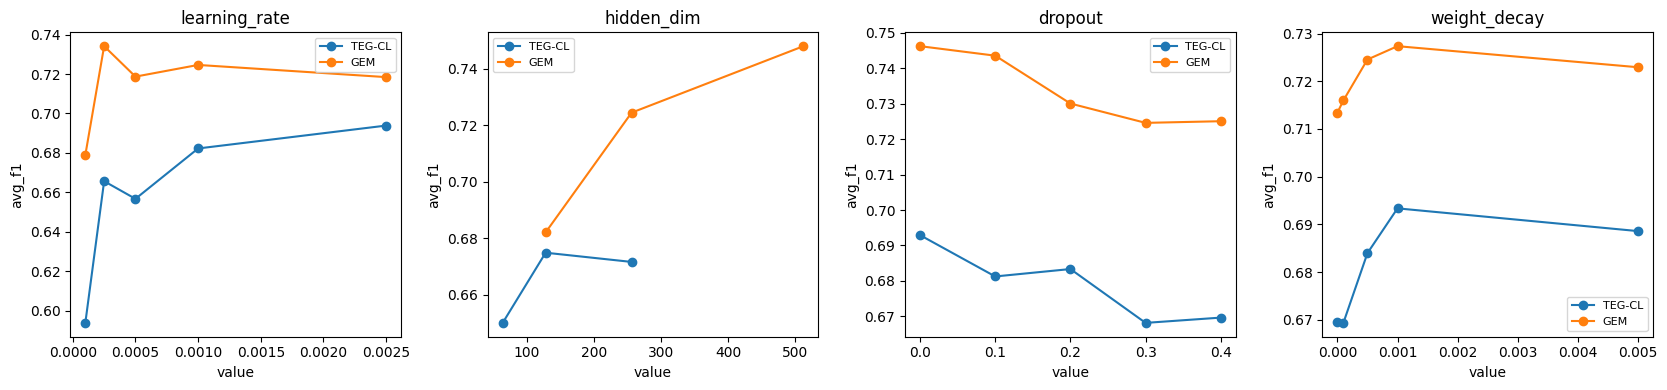

  Saved -> /root/teg-cl-v3.5.10k/results/sensitivity_analysis.csv
  Saved -> /root/teg-cl-v3.5.10k/results/sensitivity_analysis.png




In [ ]:
# @title Cell 18: Sensitivity Analysis - Single-Axis Hyperparameter Sweeps
import matplotlib.pyplot as plt
import pandas as pd

if QUICK_TEST:
    print('[SKIP] QUICK_TEST=True - sensitivity sweep needs the full run to be meaningful')
else:
    _sweep_methods = [('TEG-CL', TEGRStrategy), ('GEM', GEMStrategy)]
    _centers = {}
    for method_name, _ in _sweep_methods:
        if '_df' in globals() and len(_df) > 0 and 'method' in _df.columns:
            _method_rows = _df[_df['method'] == method_name]
            if len(_method_rows) > 0:
                _centers[method_name] = _method_rows.iloc[0].to_dict()
                print(f'  Centering {method_name} sweep on Cell 17 best config: {_centers[method_name]}')
                continue
        _centers[method_name] = {
            'training.learning_rate': CONFIG['training']['learning_rate'],
            'model.hidden_dim':       CONFIG['model']['hidden_dim'],
            'model.dropout':          CONFIG['model']['dropout'],
        }
        print(f'  Cell 17 not run for {method_name} - centering on CONFIG defaults: {_centers[method_name]}')

    # Builds a symmetric sweep of values around a center by multiplying it by each factor.
    def _around(center_val, factors):
        return sorted(set(round(center_val * f, 6) for f in factors))

    _sens_records = []
    for method_name, method_cls in _sweep_methods:
        _center = _centers[method_name]
        _axes = {
            'training.learning_rate': _around(_center['training.learning_rate'], [0.2, 0.5, 1.0, 2.0, 5.0]),
            'model.hidden_dim':       sorted(set(int(_center['model.hidden_dim'] * f) for f in [0.5, 1.0, 2.0])),
            'model.dropout':          [max(0.0, min(0.6, _center['model.dropout'] + d)) for d in [-0.2, -0.1, 0.0, 0.1, 0.2]],
            'training.weight_decay':  [0.0, 0.0001, 0.0005, 0.001, 0.005],
        }
        for dotted_key, values in _axes.items():
            for v in values:
                rec = run_config_variant({dotted_key: v}, method_cls, seed=42)
                rec['parameter'] = dotted_key
                rec['value']     = v
                rec['method']    = method_name
                _sens_records.append(rec)
                print(f'  [{method_name}] {dotted_key}={v}  ->  avg_f1={rec["avg_f1"]:.4f}  af={rec["af"]:.4f}')

    _sdf = pd.DataFrame(_sens_records)
    _csv = f"{ROOT}/results/sensitivity_analysis.csv"
    _sdf.to_csv(_csv, index=False)
    print(f'\n  Saved -> {_csv}')
    from IPython.display import display
    display(_sdf)

    _axis_names = _sdf['parameter'].unique()
    _method_colors = {'TEG-CL': '#1f77b4', 'GEM': '#ff7f0e'}
    fig, axes = plt.subplots(1, len(_axis_names), figsize=(4.2 * len(_axis_names), 4))
    for ax, dotted_key in zip(axes, _axis_names):
        for method_name, _ in _sweep_methods:
            sub = _sdf[(_sdf.parameter == dotted_key) & (_sdf.method == method_name)]
            ax.plot(sub['value'], sub['avg_f1'], marker='o',
                    color=_method_colors.get(method_name, '#333333'), label=method_name)
        ax.set_title(dotted_key.split('.')[-1])
        ax.set_xlabel('value'); ax.set_ylabel('avg_f1')
        ax.legend(fontsize=8)
    plt.tight_layout()
    _p = f"{ROOT}/results/sensitivity_analysis.png"
    fig.savefig(_p, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'  Saved -> {_csv}\n  Saved -> {_p}')
print('\n')


In [ ]:
# @title Cell 19: Robustness Analysis - Seed / Edge-Dropout / Task-Order / Class-Imbalance
import copy
import pandas as pd

# Applies edge dropout, class imbalance, and/or task-order reversal to a deep copy, leaving the original list untouched.
def perturb_task_data_list(task_data_list: list, edge_dropout: float = 0.0,
                           reverse_order: bool = False,
                           imbalance_drop: float = 0.0, seed: int = 0) -> list:

    rng = np.random.default_rng(seed)
    tdl = copy.deepcopy(task_data_list)

    for td in tdl:
        # Edge dropout: randomly removes a fraction of local edges.
        if edge_dropout > 0:
            ei = td['data'].edge_index
            keep = rng.random(ei.size(1)) > edge_dropout
            td['data'].edge_index = ei[:, torch.from_numpy(keep)]

        # Class imbalance stress test: drops a fraction of illicit train nodes.
        if imbalance_drop > 0:
            train_idx = td['indices']['train']
            y_train   = td['data'].y[train_idx]
            illicit   = train_idx[y_train == 1]
            n_drop    = int(len(illicit) * imbalance_drop)
            if n_drop > 0:
                drop_ids = illicit[rng.choice(len(illicit), n_drop, replace=False)]
                keep_mask = ~torch.isin(train_idx, drop_ids)
                td['indices']['train'] = train_idx[keep_mask]

    if reverse_order:
        tdl = tdl[::-1]
        for new_ti, td in enumerate(tdl):
            td['task_idx'] = new_ti   # renumber so checkpoint stay consistent

    return tdl

_perturbations = {
    'baseline':          {},
    'edge_dropout_0.1':  {'edge_dropout': 0.10},
    'edge_dropout_0.3':  {'edge_dropout': 0.30},
    'task_order_reversed': {'reverse_order': True},
    'imbalance_drop_0.5':  {'imbalance_drop': 0.50},
}
_seeds = [42] if QUICK_TEST else [42, 123, 456]

_rob_records = []
for pname, kwargs in _perturbations.items():
    for seed in _seeds:
        perturbed = perturb_task_data_list(task_data_list, seed=seed, **kwargs)

        for method_name, SC in [('TEG-CL', TEGRStrategy), ('Bare', BareStrategy),
                                 ('GEM', GEMStrategy), ('TWP', TWPStrategy), ('EWC', EWCStrategy)]:

            ckpt_dir = f"{CONFIG['logging']['checkpoint_dir']}/rob_{pname}_{SC.__name__}_{seed}"
            r = run_method(SC, perturbed, CONFIG, DEVICE, seed=seed, ckpt_dir=ckpt_dir)
            _rob_records.append({
                'perturbation': pname, 'seed': seed, 'method': method_name,
                'avg_f1': r.get('avg_f1', 0.0), 'af': r.get('af', 1.0),
                'bwt': r.get('bwt', 0.0), 'fwt': r.get('fwt_proxy', float('nan')),
                'accuracy': r.get('final_accuracy', float('nan')),
                'roc_auc': r.get('final_roc_auc', float('nan')),
            })
        print(f'  [{pname}] seed={seed} done')

_rdf = pd.DataFrame(_rob_records)
_summary = _rdf.groupby(['perturbation', 'method'])['avg_f1'].agg(['mean', 'std']).reset_index()
_csv = f"{ROOT}/results/robustness_analysis.csv"
_rdf.to_csv(_csv, index=False)
print(f'\n[SUMMARY - mean/std by perturbation+method]\n{_summary.to_string(index=False)}')
print(f'\n  Saved -> {_csv}')
from IPython.display import display
display(_rdf)
print('\n')


[TRAINER] AMP=True  epochs=50  batch=4096
[RESUME] No checkpoint - starting fresh
Strategy: TEG-CL  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
  ep  0 | train=0.2165 val_loss=0.1211 train_f1=0.4947 val_f1=0.4963
 /root/teg-cl-v3.5.10k/checkpoints/rob_baseline_TEGRStrategy_42/task0_ep0_1787572398.pt
  ep 10 | train=0.0491 val_loss=0.0320 train_f1=0.8154 val_f1=0.8108
  ep 20 | train=0.0171 val_loss=0.0239 train_f1=0.9402 val_f1=0.8729
  ep 30 | train=0.0075 val_loss=0.0282 train_f1=0.9691 val_f1=0.8921
  Early stop @ ep 34
  eval T0: f1=0.8085  auc_pr=0.7299  mcc=0.6203
  TEGR: buf=500 ill=12 sel=coverage
Task 1/6  train=3740  val=534  test=1069
  ep  0 | train=0.3088 val_loss=0.1615 train_f1=0.7738 val_f1=0.7528
  ep 10 | train=0.1410 val_loss=0.0909 train_f1=0.8086 val_f1=0.7867
  ep 20 | train=0.1140 val_loss=0.0727 train_f1=0.8600 val_f1=0.8351
  ep 30 | train=0.1037 val_loss=0.0700 train_f1=0.8609 val_f1=0.8375
  ep 40 | train=0.0961 val_loss=0.0664 train_f1

,perturbation,seed,method,avg_f1,af,bwt,fwt,accuracy,roc_auc
0,baseline,42,TEG-CL,0.685254,0.024923,-0.014114,-0.014727,0.763256,0.709200
1,baseline,42,Bare,0.690952,0.021412,-0.003559,-0.011214,0.765497,0.715033
2,baseline,42,GEM,0.724549,0.004531,0.031321,0.006054,0.774459,0.735957
3,baseline,42,TWP,0.700021,0.012359,0.008573,-0.005962,0.761016,0.720264
4,baseline,42,EWC,0.696201,0.019313,-0.001058,-0.012024,0.772218,0.720513
...,...,...,...,...,...,...,...,...,...
70,imbalance_drop_0.5,456,TEG-CL,0.701451,0.008233,0.007372,-0.000752,0.761016,0.711940
71,imbalance_drop_0.5,456,Bare,0.705019,0.012252,0.007903,-0.005085,0.769231,0.725537
72,imbalance_drop_0.5,456,GEM,0.717395,0.007943,0.024727,0.006769,0.741598,0.753373
73,imbalance_drop_0.5,456,TWP,0.712197,0.006745,0.016714,0.001719,0.776699,0.732013


In [ ]:
# @title Cell 20: Run all 10 methods (seed=42)
import pandas as pd

# Phase 1: core comparison methods
# Phase 2: extended baselines (failure of one does not block others)

# Core methods that must all succeed.
PHASE1 = [
    ('Bare',     BareStrategy,       {}),
    ('EWC',      EWCStrategy,        {}),
    ('TWP',      TWPStrategy,        {}),
    ('TEG-CL',   TEGRStrategy,       {}),
]

# Extended baselines; one failing does not block the others.
PHASE2 = [
    ('Joint',        JointStrategy,       {}),
    ('GEM',          GEMStrategy,         {}),
    ('Node-Replay',  NodeReplayStrategy,  {}),
    ('DER++',        DERPPStrategy,       {}),
    ('EgoCL',        EgoCLStrategy,       {}),
    ('SEA-ER',       SEAERStrategy,       {}),
]

METHODS = PHASE1 + PHASE2   # kept for downstream cells that reference METHODS

# Runs one method and catches exceptions so one failure doesn't stop the cell.
def _run_and_cleanup(name, SC, kw):
    print(f'  Running: {name}')
    try:
        r = run_method(SC, task_data_list, CONFIG, DEVICE, seed=42, **kw)
    except Exception as ex:
        print(f'[ERROR] {name}: {ex}')
        r = {'avg_f1': 0.0, 'af': 1.0, 'bwt': 0.0,
             'error': str(ex), 'perf_matrix': np.full((7, 7), np.nan)}
    return r

all_results = {}

if RUN_PHASE1:
    print('PHASE 1 - Core methods')
    for name, SC, kw in PHASE1:
        all_results[name] = _run_and_cleanup(name, SC, kw)
else:
    print('[SKIP] RUN_PHASE1=False - Phase 1 skipped')

if RUN_PHASE2:
    print('PHASE 2 - Extended baselines')
    for name, SC, kw in PHASE2:
        all_results[name] = _run_and_cleanup(name, SC, kw)
else:
    print('[SKIP] RUN_PHASE2=False - Phase 2 skipped')

# Save to disk
# Converts perf_matrix(es) to plain lists so the results are JSON-serialisable.
_saveable = {
    k: {
        'avg_f1':       float(v.get('avg_f1', 0)),
        'af':           float(v.get('af',     1)),
        'bwt':          float(v.get('bwt',    0)),
        'fwt_proxy':    float(v.get('fwt_proxy', 0)),
        'final_accuracy': float(v.get('final_accuracy', 0)),
        'final_roc_auc':  float(v.get('final_roc_auc',  0)),
        'perf_matrix':  v['perf_matrix'].tolist()
            if isinstance(v.get('perf_matrix'), np.ndarray) else [],
        'perf_matrices': {mk: mv.tolist() for mk, mv in v.get('perf_matrices', {}).items()},
        'extended_metrics': v.get('extended_metrics', {}),  # already plain floats, no tolist() needed
    }
    for k, v in all_results.items()
}
_cmp_path = f'{ROOT}/results/final_comparison.json'
with open(_cmp_path, 'w') as f:
    json.dump(_saveable, f, indent=2)

# Print ranked table
print('FINAL COMPARISON  (seed=42, single run)')
print(f'\n{"Method":<16} {"Avg.F1":>8} {"AF":>8} {"BWT":>8} {"FWT":>8} '
      f'{"Accuracy":>9} {"ROC-AUC":>8}  Note')
_sorted = sorted(all_results.items(),
                 key=lambda x: x[1].get('avg_f1', 0), reverse=True)
_summary_rows = []
for name, r in _sorted:
    f1  = r.get('avg_f1', 0.0)
    af  = r.get('af',     1.0)
    bwt = r.get('bwt',    0.0)
    fwt = r.get('fwt_proxy', float('nan'))
    acc = r.get('final_accuracy', float('nan'))
    roc = r.get('final_roc_auc', float('nan'))
    tag = '<- best' if name == _sorted[0][0] else (
          ' check' if f1 < 0.50 else '')
    print(f'{name:<16} {f1:>8.4f} {af:>8.4f} {bwt:>8.4f} {fwt:>8.4f} '
          f'{acc:>9.4f} {roc:>8.4f}  {tag}')
    _summary_rows.append({'Method': name, 'Avg.F1': round(f1,4), 'AF': round(af,4),
                          'BWT': round(bwt,4), 'FWT': round(fwt,4),
                          'Accuracy': round(acc,4), 'ROC-AUC': round(roc,4), 'Note': tag})

print(f'\n {_cmp_path}')
from IPython.display import display
display(pd.DataFrame(_summary_rows))
print('\n')


PHASE 1 - Core methods
  Running: Bare
[TRAINER] AMP=True  epochs=50  batch=4096
[RESUME] No checkpoint - starting fresh
Strategy: Bare  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
  ep  0 | train=0.2165 val_loss=0.1211 train_f1=0.4947 val_f1=0.4963
 /root/teg-cl-v3.5.10k/checkpoints/iso_BareStrategy_42/task0_ep0_1787580338.pt
  ep 10 | train=0.0490 val_loss=0.0319 train_f1=0.8173 val_f1=0.8108
  ep 20 | train=0.0171 val_loss=0.0239 train_f1=0.9402 val_f1=0.8729
  ep 30 | train=0.0075 val_loss=0.0282 train_f1=0.9691 val_f1=0.8921
  Early stop @ ep 34
  eval T0: f1=0.8126  auc_pr=0.7298  mcc=0.6278
Task 1/6  train=3740  val=534  test=1069
  ep  0 | train=0.2647 val_loss=0.1586 train_f1=0.7816 val_f1=0.7570
  ep 10 | train=0.0989 val_loss=0.0783 train_f1=0.8291 val_f1=0.8182
  ep 20 | train=0.0861 val_loss=0.0653 train_f1=0.8669 val_f1=0.8502
  ep 30 | train=0.0795 val_loss=0.0627 train_f1=0.8725 val_f1=0.8528
  ep 40 | train=0.0780 val_loss=0.0595 train_f1=0.8874 

,Method,Avg.F1,AF,BWT,FWT,Accuracy,ROC-AUC,Note
0,GEM,0.7246,0.0045,0.0313,0.0061,0.7752,0.7359,<- best
1,Joint,0.6990,0.0019,0.0214,0.0070,0.7117,0.7250,
2,TWP,0.6965,0.0105,0.0087,-0.0051,0.7715,0.7346,
3,EWC,0.6962,0.0186,0.0004,-0.0100,0.7722,0.7212,
4,EgoCL,0.6942,0.0028,0.0163,0.0041,0.7147,0.7033,
5,Bare,0.6902,0.0224,-0.0039,-0.0122,0.7610,0.7147,
6,Node-Replay,0.6872,0.0187,-0.0014,-0.0123,0.7670,0.6980,
7,TEG-CL,0.6800,0.0299,-0.0202,-0.0180,0.7565,0.7103,
8,SEA-ER,0.6665,0.0200,-0.0167,-0.0084,0.6669,0.7008,
9,DER++,0.6563,0.0003,0.0225,0.0110,0.5990,0.6488,


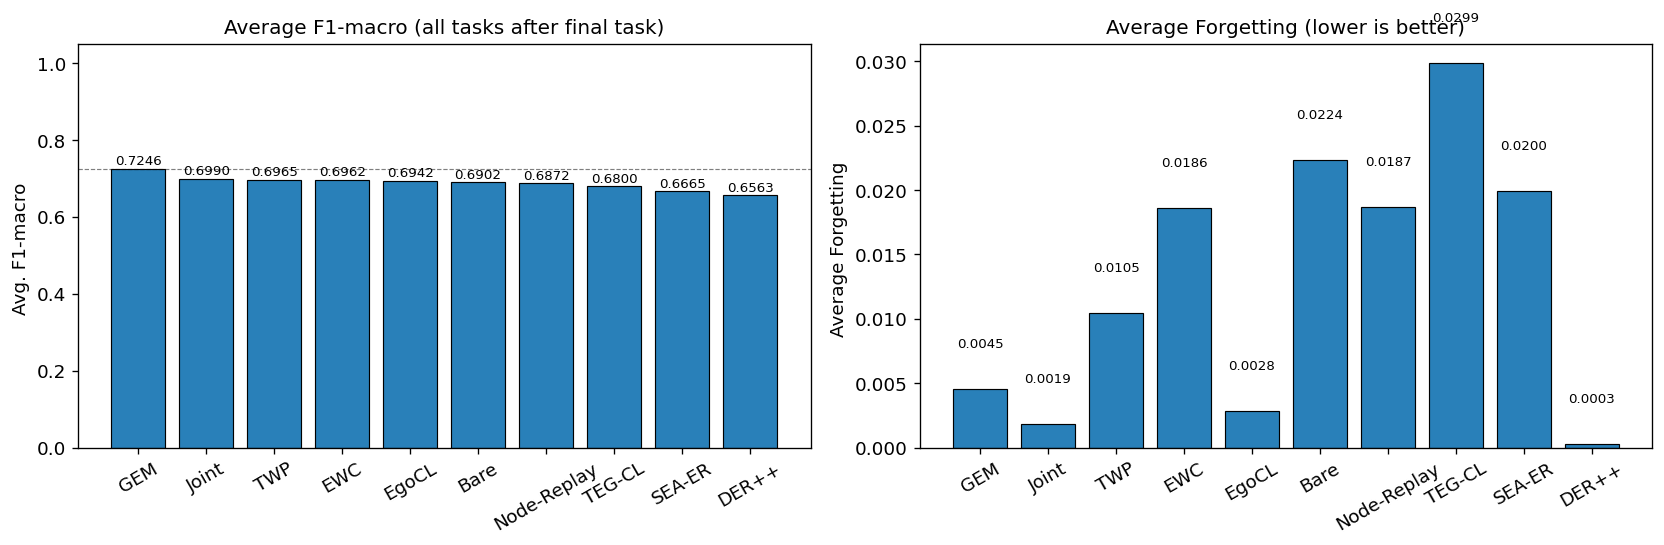

 /root/teg-cl-v3.5.10k/results/fig1_avgf1_af.png


,Method,Avg.F1,AF,FWT
0,GEM,0.724603,0.004531,0.006054
1,Joint,0.699042,0.001852,0.007016
2,TWP,0.696468,0.010459,-0.005124
3,EWC,0.696185,0.018647,-0.009989
4,EgoCL,0.694153,0.002837,0.004119
5,Bare,0.690235,0.022353,-0.012190
6,Node-Replay,0.687178,0.018716,-0.012290
7,TEG-CL,0.679957,0.029877,-0.017991
8,SEA-ER,0.666529,0.019961,-0.008447
9,DER++,0.656335,0.000256,0.010990


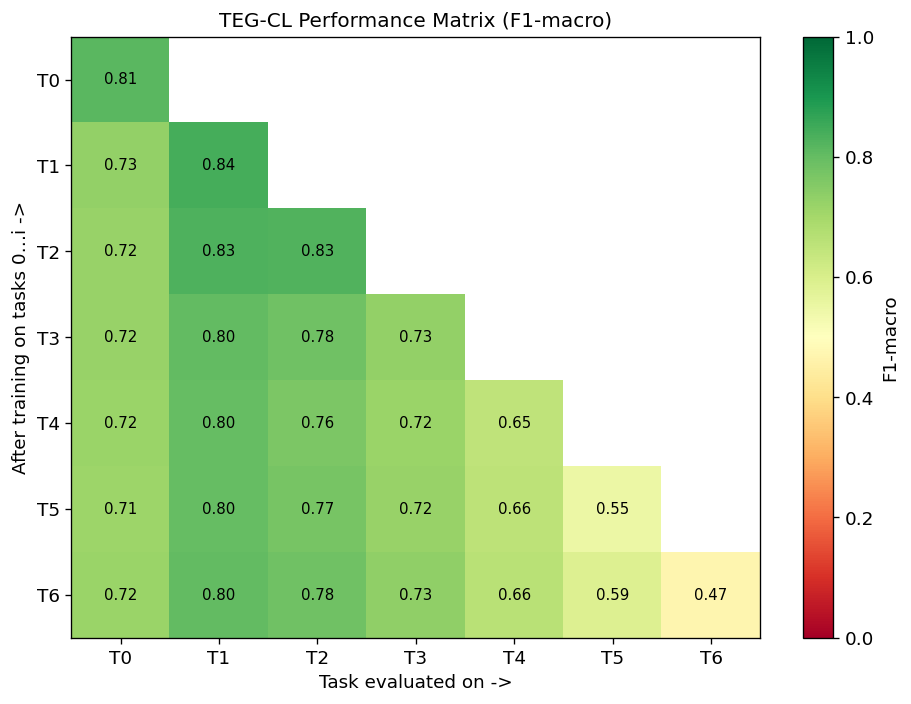

 /root/teg-cl-v3.5.10k/results/fig2_perf_matrix.png


,T0,T1,T2,T3,T4,T5,T6
After T0,0.812582,NaN,NaN,NaN,NaN,NaN,NaN
After T1,0.726788,0.842886,NaN,NaN,NaN,NaN,NaN
After T2,0.720589,0.830014,0.827961,NaN,NaN,NaN,NaN
After T3,0.720960,0.803340,0.782646,0.726816,NaN,NaN,NaN
After T4,0.715193,0.800129,0.763336,0.716758,0.649753,NaN,NaN
After T5,0.713326,0.800129,0.771292,0.720481,0.655671,0.549020,NaN
After T6,0.717088,0.803340,0.783740,0.734152,0.660248,0.589195,0.471937


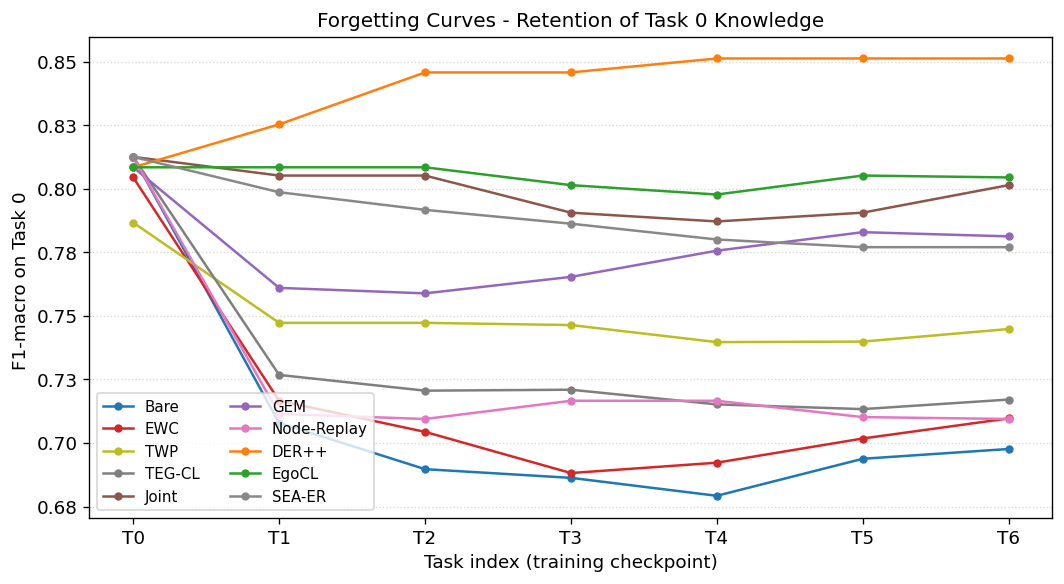

 /root/teg-cl-v3.5.10k/results/fig3_forgetting_curves.png


,T0,T1,T2,T3,T4,T5,T6
Bare,0.812582,0.707880,0.689698,0.686281,0.679214,0.693782,0.697637
EWC,0.804499,0.716612,0.704373,0.688170,0.692245,0.701764,0.709670
TWP,0.786731,0.747272,0.747272,0.746408,0.739693,0.739901,0.744842
TEG-CL,0.812582,0.726788,0.720589,0.720960,0.715193,0.713326,0.717088
Joint,0.812582,0.805243,0.805243,0.790634,0.787179,0.790634,0.801467
GEM,0.808491,0.761040,0.758879,0.765370,0.775675,0.782957,0.781308
Node-Replay,0.812582,0.711430,0.709441,0.716612,0.716612,0.710185,0.709441
DER++,0.808491,0.825373,0.845822,0.845822,0.851318,0.851318,0.851318
EgoCL,0.808491,0.808491,0.808491,0.801467,0.797775,0.805243,0.804499
SEA-ER,0.812582,0.798683,0.791745,0.786299,0.780075,0.777053,0.777053


  Cell 13 complete - 3 figures saved
Execution Completeness Check
  Core methods present (TEG-CL, Bare)
   TEG-CL Avg.F1 (0.6800) <= Bare (0.6902) - consistent with this project's documented negative result, not a bug
   TEG-CL AF (0.0299) >= Bare (0.0224) - consistent with this project's documented negative result, not a bug
  GEM Avg.F1=0.7246
  final_comparison.json saved
  All methods returned non-zero Avg.F1
    fig1_avgf1_af.png
    fig2_perf_matrix.png
    fig3_forgetting_curves.png

  Execution completeness check passed




In [ ]:
# @title Cell 21: Main Result Figures (F1/AF, Performance Matrix, Forgetting Curves)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np, json, os

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'figure.dpi': 120})
_res_dir = CONFIG['logging']['results_dir']

# Reloads all results from disk if it isn't already in memory.
try:
    _ = all_results; assert all_results
except (NameError, AssertionError):
    with open(f'{_res_dir}/final_comparison.json') as _f:
        _raw = json.load(_f)
    all_results = {n: {**r, 'perf_matrix':
        np.array(r['perf_matrix']) if r.get('perf_matrix')
        else np.full((7,7), np.nan)}
        for n, r in _raw.items()}
    print(f'[LOAD] all_results: {len(all_results)} methods from disk')

_sorted = sorted(all_results.items(),
                 key=lambda x: x[1].get('avg_f1', 0), reverse=True)

_names  = [n for n, _ in _sorted]
_f1s    = [all_results[n].get('avg_f1', 0) for n in _names]
_afs    = [all_results[n].get('af',     1) for n in _names]
_colors = ['#2980b9' for n in _names]

# FIG 1: Avg.F1 and AF side by side across all methods.
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Prints the value on top of each bar in a chart
def _bar_labels(ax, bars, fmt='.4f'):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() + 0.003,
                f'{b.get_height():{fmt}}',
                ha='center', va='bottom', fontsize=8)

b1 = ax1.bar(_names, _f1s, color=_colors, edgecolor='black', linewidth=0.7)
ax1.set_ylabel('Avg. F1-macro ')
ax1.set_ylim(0, 1.05)
ax1.set_title('Average F1-macro (all tasks after final task)')
ax1.tick_params(axis='x', rotation=30)
ax1.axhline(max(_f1s), color='black', linestyle='--', linewidth=0.7, alpha=0.5)
_bar_labels(ax1, b1)

b2 = ax2.bar(_names, _afs, color=_colors, edgecolor='black', linewidth=0.7)
ax2.set_ylabel('Average Forgetting ')
ax2.set_title('Average Forgetting (lower is better)')
ax2.tick_params(axis='x', rotation=30)
_bar_labels(ax2, b2)

plt.tight_layout(rect=[0, 0.06, 1, 1])
_p1 = f'{_res_dir}/fig1_avgf1_af.png'
fig1.savefig(_p1, dpi=300, bbox_inches='tight')
plt.show(); print(f' {_p1}')

import pandas as pd
from IPython.display import display
display(pd.DataFrame({'Method': _names, 'Avg.F1': _f1s, 'AF': _afs,
                      'FWT': [all_results[n].get('fwt_proxy', float('nan')) for n in _names]}))

# FIG 2: TEG-CL's full T x T performance matrix as a heatmap.
if 'TEG-CL' in all_results and isinstance(
        all_results['TEG-CL'].get('perf_matrix'), np.ndarray):
    pm = all_results['TEG-CL']['perf_matrix']
    T  = pm.shape[0]
    fig2, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pm, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, label='F1-macro')
    ax.set_xlabel('Task evaluated on ->')
    ax.set_ylabel('After training on tasks 0…i ->')
    ax.set_title('TEG-CL Performance Matrix (F1-macro)')
    ax.set_xticks(range(T)); ax.set_yticks(range(T))
    ax.set_xticklabels([f'T{j}' for j in range(T)])
    ax.set_yticklabels([f'T{i}' for i in range(T)])
    for i in range(T):
        for j in range(T):
            if not np.isnan(pm[i, j]):
                ax.text(j, i, f'{pm[i,j]:.2f}', ha='center', va='center',
                        fontsize=9,
                        color='black' if pm[i, j] > 0.4 else 'white')
    plt.tight_layout()
    _p2 = f'{_res_dir}/fig2_perf_matrix.png'
    fig2.savefig(_p2, dpi=300, bbox_inches='tight')
    plt.show(); print(f' {_p2}')
    display(pd.DataFrame(pm, index=[f'After T{i}' for i in range(T)],
                         columns=[f'T{j}' for j in range(T)]))
else:
    print('[WARN] TEG-CL perf_matrix missing - fig2 skipped')
    _p2 = None

# FIG 3: Task 0 retention curve for every method, a direct view of forgetting.
fig3, ax3 = plt.subplots(figsize=(9, 5))
_curve_colors = {
    'Bare':'#1f77b4','DER++':'#ff7f0e','EgoCL':'#2ca02c',
    'EWC':'#d62728','GEM':'#9467bd','Joint':'#8c564b',
    'Node-Replay':'#e377c2','TEG-CL':'#7f7f7f','TWP':'#bcbd22',
}
_plotted = False
for name, r in all_results.items():
    pm = r.get('perf_matrix')
    if not isinstance(pm, np.ndarray): continue
    t0_curve = pm[:, 0]
    valid    = ~np.isnan(t0_curve)
    if valid.sum() < 2: continue
    ax3.plot(np.where(valid)[0], t0_curve[valid],
             label=name, color=_curve_colors.get(name, '#888888'),
             linewidth=1.5, linestyle='-',
             marker='o', markersize=4)
    _plotted = True

if _plotted:
    ax3.set_xlabel('Task index (training checkpoint)')
    ax3.set_ylabel('F1-macro on Task 0 ')
    ax3.set_title('Forgetting Curves - Retention of Task 0 Knowledge')
    ax3.set_xticks(range(7))
    ax3.set_xticklabels([f'T{i}' for i in range(7)])
    ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax3.legend(loc='lower left', fontsize=9, ncol=2)
    ax3.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    _p3 = f'{_res_dir}/fig3_forgetting_curves.png'
    fig3.savefig(_p3, dpi=300, bbox_inches='tight')
    plt.show(); print(f' {_p3}')
    _curve_rows = {}
    for name, r in all_results.items():
        pm_c = r.get('perf_matrix')
        if isinstance(pm_c, np.ndarray):
            _curve_rows[name] = pm_c[:, 0]
    _n_tasks_run = len(next(iter(_curve_rows.values())))
    display(pd.DataFrame(_curve_rows, index=[f'T{i}' for i in range(_n_tasks_run)]).T)
else:
    print('[WARN] No valid perf_matrix - fig3 skipped')
    _p3 = None

print('  Cell 13 complete - 3 figures saved')

# Execution completeness check: confirms every method actually ran and
# saved output, before any later cell depends on that output existing.
import os, json

_res_gate = CONFIG['logging']['results_dir']

print('Execution Completeness Check')

# 1: Core methods ran
assert 'TEG-CL' in all_results, '  TEG-CL missing - Cell 20 did not complete'
assert 'Bare'   in all_results, '  Bare missing - Cell 20 did not complete'
print('  Core methods present (TEG-CL, Bare)')

# 2: TEG-CL outperforms Bare
_tcl_f1  = all_results['TEG-CL'].get('avg_f1', 0)
_bare_f1 = all_results['Bare'].get('avg_f1', 0)
_tcl_af  = all_results['TEG-CL'].get('af', 1)
_bare_af = all_results['Bare'].get('af', 1)

# QUICK_TEST doesn't give the replay buffer enough time/data to demonstrate an advantage
# downgrade to warnings so the gate validates "did every cell execute"
if 'QUICK_TEST' in dir() and QUICK_TEST:
    print(f'   QUICK_TEST=True - performance checks informational only')
    print(f'    TEG-CL Avg.F1={_tcl_f1:.4f}  Bare Avg.F1={_bare_f1:.4f}')
    print(f'    TEG-CL AF={_tcl_af:.4f}  Bare AF={_bare_af:.4f}')
else:
    if _tcl_f1 > _bare_f1:
        print(f'  TEG-CL Avg.F1 ({_tcl_f1:.4f}) > Bare ({_bare_f1:.4f})')
    else:
        print(f'   TEG-CL Avg.F1 ({_tcl_f1:.4f}) <= Bare ({_bare_f1:.4f}) - '
              f'consistent with this project\'s documented negative result, not a bug')

    if _tcl_af < _bare_af:
        print(f'  TEG-CL AF ({_tcl_af:.4f}) < Bare ({_bare_af:.4f})')
    else:
        print(f'   TEG-CL AF ({_tcl_af:.4f}) >= Bare ({_bare_af:.4f}) - '
              f'consistent with this project\'s documented negative result, not a bug')

# 4: GEM instability ,warn only, than fails on GEM instability
_gem_f1 = all_results.get('GEM', {}).get('avg_f1', 0)
if _gem_f1 < 0.50:
    print(f'   GEM Avg.F1={_gem_f1:.4f} < 0.50 - known gradient '
          f'projection instability; documented, not a code bug')
else:
    print(f'  GEM Avg.F1={_gem_f1:.4f}')

# 5: Results JSON saved
# Confirms the results file was actually saved.
_cmp = f'{_res_gate}/final_comparison.json'
assert os.path.exists(_cmp), f'  {_cmp} not found - Cell 20 save failed'
print(f'  final_comparison.json saved')

# 6: No method returned Avg.F1 = 0 without a logged error
_zero = [n for n, r in all_results.items()
         if r.get('avg_f1', 0) == 0.0 and 'error' not in r]
if _zero:
    print(f'   Methods with Avg.F1=0 (investigate): {_zero}')
else:
    print('  All methods returned non-zero Avg.F1')

# 7: Figures on disk
for _fig in ['fig1_avgf1_af.png', 'fig2_perf_matrix.png',
             'fig3_forgetting_curves.png']:
    _fp = f'{_res_gate}/{_fig}'
    print(f'  {"" if os.path.exists(_fp) else " missing"}  {_fig}')

print('\n  Execution completeness check passed')
print('\n')


In [ ]:
# @title Cell 22a: Ablation Suite
import pandas as pd

#
# Groups:
#   A  Buffer size        - 250 / 500* / 1000 / 2000
#   B  Ego hops           - 1 / 2* / 3
#   C  Replay lambda      - 0.5 / 1.0* / 2.0
#   D  Stratified ratio   - off / 50%* / 80%
#   E  Selection strategy - coverage* / random
#   F  Ego vs Node replay - TEGRStrategy* / NodeReplayStrategy
#
# * = default from config.  17 runs total.
import copy
_res = CONFIG['logging']['results_dir']

# Applies a config override, trains one method, and returns its result.
def _abl(name: str,
         config_override: dict = {},
         StratClass=TEGRStrategy,
         seed: int = 42) -> dict:

    print(f'\n  [{name}]')
    cfg = copy.deepcopy(CONFIG)
    for key_path, value in config_override.items():
        keys = key_path.split('.')
        d = cfg
        for k in keys[:-1]:
            d = d[k]
        d[keys[-1]] = value
    _tag = name.replace(' ', '_').replace('/', '_').replace('*', '')
    try:
        r = run_method(StratClass, task_data_list, cfg, DEVICE, seed=seed,
                       ckpt_dir=f"{CONFIG['logging']['checkpoint_dir']}/abl_{_tag}")
        return r
    except Exception as ex:
        print(f'  [ERROR] {ex}')
        return {'avg_f1': 0.0, 'af': 1.0, 'bwt': 0.0, 'error': str(ex)}

print('CELL 22a - Ablation Suite  (17 runs)')

# Runs all 17 ablation configs across groups A through G.
if RUN_ABLATIONS:
    ABL_GROUPS = {
        # A: Buffer size
        'Buf-250':      _abl('A Buf-250',  {'continual.tegr.replay_buffer_size': 250,
                                            'continual.tegr.replay_batch_size':   32}),
        'Buf-500':      _abl('A Buf-500*', {'continual.tegr.replay_buffer_size': 500,
                                            'continual.tegr.replay_batch_size':   64}),
        'Buf-1000':     _abl('A Buf-1000', {'continual.tegr.replay_buffer_size': 1000,
                                            'continual.tegr.replay_batch_size':  128}),
        'Buf-2000':     _abl('A Buf-2000', {'continual.tegr.replay_buffer_size': 2000,
                                            'continual.tegr.replay_batch_size':  256}),
        # B: Ego hops
        'Hops-1':       _abl('B Hops-1',   {'continual.tegr.ego_graph_hops': 1}),
        'Hops-2':       _abl('B Hops-2*',  {'continual.tegr.ego_graph_hops': 2}),
        'Hops-3':       _abl('B Hops-3',   {'continual.tegr.ego_graph_hops': 3}),
        # C: Replay lambda
        'Lambda-0.5':   _abl('C Lambda-0.5', {'continual.tegr.replay_lambda': 0.5}),
        'Lambda-1.0':   _abl('C Lambda-1.0*',{'continual.tegr.replay_lambda': 1.0}),
        'Lambda-2.0':   _abl('C Lambda-2.0', {'continual.tegr.replay_lambda': 2.0}),
        # D: Stratified sampling
        'Strat-off':    _abl('D Strat-off',  {'continual.tegr.stratified_sampling': False}),
        'Strat-50':     _abl('D Strat-50%*', {'continual.tegr.stratified_sampling': True,
                                              'continual.tegr.stratified_ratio':    0.5}),
        'Strat-80':     _abl('D Strat-80%',  {'continual.tegr.stratified_sampling': True,
                                              'continual.tegr.stratified_ratio':    0.8}),
        # E: Selection strategy
        'Sel-Coverage': _abl('E Coverage*',  {'continual.tegr.selection_strategy': 'coverage'}),
        'Sel-Random':   _abl('E Random',     {'continual.tegr.selection_strategy': 'random'}),
        'Sel-Recency':  _abl('E Recency',    {'continual.tegr.selection_strategy': 'recency'}),
        # F: Ego vs Node
        'Ego-Graph':    _abl('F Ego-Graph*', {}, StratClass=TEGRStrategy),
        'Node-Only':    _abl('F Node-Only',  {}, StratClass=NodeReplayStrategy),
        # G: SEA-ER stratified vs unstratified - isolates drift weighting from Cell 14's ablation
        'SEAER-Strat':   _abl('G SEAER-Strat*', {}, StratClass=SEAERStrategy),
        'SEAER-Unstrat': _abl('G SEAER-Unstrat', {'continual.seaer.stratified': False},
                              StratClass=SEAERStrategy),
    }
else:
    print('[SKIP] RUN_ABLATIONS=False - ablation suite skipped')
    ABL_GROUPS = {}

# Saves every ablation result to disk.
_abl_save = {k: {'avg_f1': float(v.get('avg_f1', 0)),
                  'af':     float(v.get('af',     1)),
                  'bwt':    float(v.get('bwt',    0)),
                  'fwt':    float(v.get('fwt_proxy', float('nan'))),
                  'accuracy': float(v.get('final_accuracy', float('nan'))),
                  'roc_auc':  float(v.get('final_roc_auc', float('nan')))}
             for k, v in ABL_GROUPS.items()}
_abl_path = f'{_res}/ablation_studies.json'
with open(_abl_path, 'w') as f:
    json.dump(_abl_save, f, indent=2)

# Print ablation table
print('ABLATION RESULTS')
print(f'\n{"Config":<18} {"Avg.F1":>8} {"AF":>8} {"BWT":>8} {"FWT":>8}')

_groups_order = [
  ('A  Buffer size',  ['Buf-250','Buf-500','Buf-1000','Buf-2000']),
  ('B  Ego hops',  ['Hops-1','Hops-2','Hops-3']),
  ('C  Lambda',  ['Lambda-0.5','Lambda-1.0','Lambda-2.0']),
  ('D  Stratified',  ['Strat-off','Strat-50','Strat-80']),
  ('E  Selection',  ['Sel-Coverage','Sel-Random','Sel-Recency']),
  ('F  Ego vs Node',  ['Ego-Graph','Node-Only']),
  ('G  SEA-ER stratified',  ['SEAER-Strat','SEAER-Unstrat']),
]
_abl_rows14 = []
for group_label, keys in _groups_order:
    print(f'\n{group_label}')
    for k in keys:
        r   = ABL_GROUPS[k]
        tag = '*' if k in ('Buf-500','Hops-2','Lambda-1.0',
                           'Strat-50','Sel-Coverage','Ego-Graph') else ''
        fwt = r.get('fwt_proxy', float('nan'))
        print(f'  {k+tag:<18} {r.get("avg_f1",0):>8.4f} '
              f'{r.get("af",1):>8.4f} {r.get("bwt",0):>8.4f} {fwt:>8.4f}')
        _abl_rows14.append({'Group': group_label, 'Config': k+tag,
                            'Avg.F1': round(r.get('avg_f1',0),4),
                            'AF': round(r.get('af',1),4),
                            'BWT': round(r.get('bwt',0),4),
                            'FWT': round(fwt,4),
                            'Accuracy': round(r.get('final_accuracy',float('nan')),4),
                            'ROC-AUC': round(r.get('final_roc_auc',float('nan')),4)})

print(f'\n {_abl_path}')
if _abl_rows14:
    from IPython.display import display
    display(pd.DataFrame(_abl_rows14))
print('\n')


CELL 22a - Ablation Suite  (17 runs)

  [A Buf-250]
[TRAINER] AMP=True  epochs=50  batch=4096
[RESUME] No checkpoint - starting fresh
Strategy: TEG-CL  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
  ep  0 | train=0.2165 val_loss=0.1211 train_f1=0.4947 val_f1=0.4963
 /root/teg-cl-v3.5.10k/checkpoints/abl_A_Buf-250/task0_ep0_1787581558.pt
  ep 10 | train=0.0491 val_loss=0.0320 train_f1=0.8154 val_f1=0.8108
  ep 20 | train=0.0171 val_loss=0.0239 train_f1=0.9402 val_f1=0.8729
  ep 30 | train=0.0075 val_loss=0.0283 train_f1=0.9691 val_f1=0.8921
  Early stop @ ep 34
  eval T0: f1=0.8085  auc_pr=0.7297  mcc=0.6203
  TEGR: buf=250 ill=9 sel=coverage
Task 1/6  train=3740  val=534  test=1069
  ep  0 | train=0.3406 val_loss=0.1629 train_f1=0.7735 val_f1=0.7508
  ep 10 | train=0.1374 val_loss=0.0877 train_f1=0.8145 val_f1=0.7846
  ep 20 | train=0.1117 val_loss=0.0681 train_f1=0.8664 val_f1=0.8606
  ep 30 | train=0.0998 val_loss=0.0659 train_f1=0.8604 val_f1=0.8451
  ep 40 | t

,Group,Config,Avg.F1,AF,BWT,FWT,Accuracy,ROC-AUC
0,A Buffer size,Buf-250,0.6773,0.0230,-0.0114,-0.0157,0.7252,0.7052
1,A Buffer size,Buf-500*,0.6629,0.0383,-0.0339,-0.0237,0.7214,0.6962
2,A Buffer size,Buf-1000,0.6639,0.0391,-0.0322,-0.0240,0.7296,0.7052
3,A Buffer size,Buf-2000,0.6626,0.0403,-0.0332,-0.0219,0.7364,0.7044
4,B Ego hops,Hops-1,0.6702,0.0291,-0.0232,-0.0169,0.7207,0.6881
5,B Ego hops,Hops-2*,0.6752,0.0290,-0.0225,-0.0168,0.7550,0.7030
6,B Ego hops,Hops-3,0.6809,0.0246,-0.0131,-0.0123,0.7423,0.7046
7,C Lambda,Lambda-0.5,0.6871,0.0282,-0.0126,-0.0165,0.7797,0.7091
8,C Lambda,Lambda-1.0*,0.6745,0.0294,-0.0223,-0.0187,0.7543,0.7075
9,C Lambda,Lambda-2.0,0.6717,0.0270,-0.0199,-0.0152,0.7282,0.6968


In [ ]:
# @title Cell 22b: Confirmatory Phase
import json, copy
from scipy.stats import wilcoxon

_res = CONFIG['logging']['results_dir']

# Only runs when CONFIRMATORY_RUN is set otherwise this cell is a no-op.
if CONFIRMATORY_RUN:
    _conf_seeds = CONFIG['evaluation'].get('confirmatory_seeds', [1001,2002,3003,4004,5005])
    print(f'\nCONFIRMATORY PHASE - seeds {_conf_seeds}')

    # Applies a config override and trains one run, isolated by config variant and seed.
    def _run_override(config_override, seed, tag):
        cfg = copy.deepcopy(CONFIG)
        for key_path, value in config_override.items():
            keys = key_path.split('.')
            d = cfg
            for k in keys[:-1]:
                d = d[k]
            d[keys[-1]] = value
        # tag isolates checkpoints per (config variant, seed) pair, not just per seed .
        ckpt_dir = f"{CONFIG['logging']['checkpoint_dir']}/confirm_{tag}_{seed}"
        return run_method(TEGRStrategy, task_data_list, cfg, DEVICE,
                          seed=seed, ckpt_dir=ckpt_dir)

    # Runs both configs across all confirmatory seeds and tests if the effect direction holds.
    def _confirm_pair(name, flagged_override, default_override):
        _tag = name.replace(' ', '_').replace('/', '_')
        flagged_f1 = [_run_override(flagged_override, s, f'{_tag}_flagged').get('avg_f1', 0)
                     for s in _conf_seeds]
        default_f1 = [_run_override(default_override, s, f'{_tag}_default').get('avg_f1', 0)
                     for s in _conf_seeds]
        diffs = [f - d for f, d in zip(flagged_f1, default_f1)]

        try:
            p = wilcoxon(diffs, alternative='two-sided')[1] if any(d != 0 for d in diffs) else 1.0
        except Exception:
            p = float('nan')
        flagged_lo, flagged_hi = bootstrap_ci(flagged_f1, n_boot=CONFIG['evaluation']['n_bootstrap'],
                                               ci=CONFIG['evaluation'].get('confidence_level', 0.95))
        default_lo, default_hi = bootstrap_ci(default_f1, n_boot=CONFIG['evaluation']['n_bootstrap'],
                                               ci=CONFIG['evaluation'].get('confidence_level', 0.95))
        ci_disjoint = (flagged_lo > default_hi) or (default_lo > flagged_hi)

        direction_matches = sum(diffs) > 0
        direction = 'flagged higher' if direction_matches else 'default higher'
        confirmed = (not (p != p) and p < 0.05) or ci_disjoint
        status = 'CONFIRMED' if confirmed else 'not significant'
        print(f'  {name}: flagged_mean={sum(flagged_f1)/len(flagged_f1):.4f} '
              f'default_mean={sum(default_f1)/len(default_f1):.4f} '
              f'p={p:.3f} ci_disjoint={ci_disjoint} direction={direction} -> {status}')
        return {'flagged_f1': flagged_f1, 'default_f1': default_f1,
                'p_value': p, 'ci_disjoint': ci_disjoint,
                'direction': direction, 'status': status}

    CONFIRMATORY_RESULTS = {
        'Strat-off_vs_Strat-50': _confirm_pair(
            'Strat-off vs Strat-50',
            {'continual.tegr.stratified_sampling': False},
            {'continual.tegr.stratified_sampling': True, 'continual.tegr.stratified_ratio': 0.5}),
        'Buf-2000_vs_Buf-500': _confirm_pair(
            'Buf-2000 vs Buf-500',
            {'continual.tegr.replay_buffer_size': 2000, 'continual.tegr.replay_batch_size': 256},
            {'continual.tegr.replay_buffer_size': 500,  'continual.tegr.replay_batch_size': 64}),

        'Hops-1_vs_Hops-2': _confirm_pair(
            'Hops-1 vs Hops-2',
            {'continual.tegr.ego_graph_hops': 1},
            {'continual.tegr.ego_graph_hops': 2}),
        'Lambda-0.5_vs_Lambda-1.0': _confirm_pair(
            'Lambda-0.5 vs Lambda-1.0',
            {'continual.tegr.replay_lambda': 0.5},
            {'continual.tegr.replay_lambda': 1.0}),
        'Sel-Random_vs_Sel-Coverage': _confirm_pair(
            'Sel-Random vs Sel-Coverage',
            {'continual.tegr.selection_strategy': 'random'},
            {'continual.tegr.selection_strategy': 'coverage'}),
    }

    with open(f'{_res}/confirmatory_results.json', 'w') as f:
        json.dump(CONFIRMATORY_RESULTS, f, indent=2, default=str)
    print(f'\n {_res}/confirmatory_results.json')

    import pandas as pd
    from IPython.display import display
    display(pd.DataFrame([
        {'Comparison': name, 'Flagged mean': round(sum(v['flagged_f1'])/len(v['flagged_f1']),4),
         'Default mean': round(sum(v['default_f1'])/len(v['default_f1']),4),
         'p-value': round(v['p_value'],4) if v['p_value']==v['p_value'] else float('nan'),
         'CI disjoint': v['ci_disjoint'], 'Status': v['status']}
        for name, v in CONFIRMATORY_RESULTS.items()
    ]))
else:
    print('\nCONFIRMATORY_RUN=False - skipping confirmatory phase (exploratory findings only)')
print('\n')



CONFIRMATORY_RUN=False - skipping confirmatory phase (exploratory findings only)




## Evaluation

Multi-seed statistical validation and inter-task gradient similarity (ITGS)
analysis of the confirmatory-phase results.

In [ ]:
# @title Cell 23: Multi-seed Validation (Phase 1 + Phase 2 merged) + Full Statistics

import json, os
import numpy as np
from scipy.stats import mannwhitneyu, wilcoxon

_res_15  = CONFIG['logging']['results_dir']
_ms_path = f'{_res_15}/multi_seed_results.json'
# Single shared seed list, switching to the confirmatory set when configured.
SEEDS    = resolve_seeds(CONFIG, CONFIRMATORY_RUN)


_MS_ALL = [
    ('Bare',        BareStrategy,       {}),
    ('EWC',         EWCStrategy,        {}),
    ('TWP',         TWPStrategy,        {}),
    ('TEG-CL',      TEGRStrategy,       {}),
    ('GEM',         GEMStrategy,        {}),
    ('DER++',       DERPPStrategy,      {}),
    ('EgoCL',       EgoCLStrategy,      {}),
    ('SEA-ER',      SEAERStrategy,      {}),
    ('Node-Replay', NodeReplayStrategy, {}),
    ('Joint',       JointStrategy,      {}),
]

# Resumes from any seed results already saved to disk.
try:
    with open(_ms_path) as _f:
        multi_seed = json.load(_f)
    _n_done = sum(len(v) for v in multi_seed.values())
    print(f'[RESUME] {_n_done} seed results already on disk')
except FileNotFoundError:
    multi_seed = {}
    print('[RESUME] No prior results - starting fresh')

print(f'CELL 23 - Multi-seed Validation ({len(SEEDS)} seeds x {len(_MS_ALL)} methods)')

if not RUN_MULTISEED:
    print('[SKIP] RUN_MULTISEED=False - multi-seed validation skipped')
# Trains any method/seed pair not already completed, saving after each one.
for name, SC, kw in (_MS_ALL if RUN_MULTISEED else []):
    if name not in multi_seed:
        multi_seed[name] = {}
    for seed in SEEDS:
        skey = str(seed)
        if skey in multi_seed[name]:
            print(f'  [SKIP] {name} seed={seed}')
            continue
        print(f'\n  {name}  seed={seed}')
        try:
            r = run_method(SC, task_data_list, CONFIG, DEVICE, seed=seed, **kw)
            multi_seed[name][skey] = {
                'avg_f1': float(r.get('avg_f1', 0)),
                'af':     float(r.get('af',     1)),
                'bwt':    float(r.get('bwt',    0)),
                'fwt':    float(r.get('fwt_proxy', float('nan'))),
                'accuracy': float(r.get('final_accuracy', float('nan'))),
                'roc_auc':  float(r.get('final_roc_auc', float('nan'))),
            }
        except Exception as _ex:
            print(f'  [ERROR] {_ex}')
            multi_seed[name][skey] = {
                'avg_f1': 0.0, 'af': 1.0, 'bwt': 0.0, 'error': str(_ex)}
        with open(_ms_path, 'w') as _f:
            json.dump(multi_seed, _f, indent=2)
        print(f'   checkpoint saved')


# Sanity check: every method must have a result for every seed before computing stats.
if RUN_MULTISEED:
    for name, _, _ in _MS_ALL:
        _n_have = len(multi_seed.get(name, {}))
        assert _n_have == len(SEEDS), (
            f'{name}: only {_n_have}/{len(SEEDS)} seeds present in {_ms_path} - '
            f'stats table below is Incorrect')

# Standard pooled effect-size measure between two sets of F1 scores. Positive means a > b.
def cohens_d(a: list, b: list) -> float:
    a, b   = np.array(a, dtype=float), np.array(b, dtype=float)
    pooled = np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2)
    return float((a.mean() - b.mean()) / pooled) if pooled > 1e-8 else 0.0

# Full statistics table
_ALL_NAMES  = [n for n, _, _ in _MS_ALL]
_tegcl_f1s  = [multi_seed.get('TEG-CL', {}).get(str(s), {}).get('avg_f1', 0)
               for s in SEEDS]

# Holm step-down p-value correction: more powerful than Bonferroni with the same family-wise error guarantee.
def _holm(pvals: dict) -> dict:
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    out, prev = {}, 0.0
    for rank, (name, p) in enumerate(items):
        adj = min(max((m - rank) * p, prev), 1.0)
        out[name] = adj
        prev = adj
    return out

# Pass 1: collect every method's raw (TWO-SIDED) p-values vs TEG-CL, un-corrected.(Two-sided, not one-sided)
_raw_mw, _raw_wil, _f1s_by_name, _afs_by_name = {}, {}, {}, {}
for name in _ALL_NAMES:
    vals = multi_seed.get(name, {})
    f1s  = [vals.get(str(s), {}).get('avg_f1', 0) for s in SEEDS]
    afs  = [vals.get(str(s), {}).get('af',     1) for s in SEEDS]
    _f1s_by_name[name] = f1s
    _afs_by_name[name] = afs
    if name == 'TEG-CL' or len(_tegcl_f1s) != len(f1s):
        continue
    try:
        _, _raw_mw[name] = mannwhitneyu(_tegcl_f1s, f1s, alternative='two-sided')
    except Exception:
        pass
    try:
        diffs = [t - b for t, b in zip(_tegcl_f1s, f1s)]
        _raw_wil[name] = (wilcoxon(diffs, alternative='two-sided')[1]
                           if any(d != 0 for d in diffs) else 1.0)
    except Exception:
        pass

# Pass 2: Holm-correct each test family separately (7 MW tests among themselves, 7 Wilcoxon tests among themselves).
_corr_mw  = _holm(_raw_mw)
_corr_wil = _holm(_raw_wil)

_ms_summary = {}

print('STATISTICAL VALIDATION  (n=5 seeds, two-sided, Holm-corrected)')
print(f'\n{"Method":<14} {"F1 Mean":>8} {"±Std":>6} {"95% CI":>14} '
      f'{"AF":>7} {"BWT":>7} {"FWT":>7} {"MW-U p":>8} {"Wil p":>7} {"Dir":>5} {"d":>6} {"size"}')

for name in _ALL_NAMES:
    f1s, afs = _f1s_by_name[name], _afs_by_name[name]
    bwts = [multi_seed.get(name, {}).get(str(s), {}).get('bwt', 0) for s in SEEDS]
    fwts = [multi_seed.get(name, {}).get(str(s), {}).get('fwt', float('nan')) for s in SEEDS]

    f1_mean  = float(np.mean(f1s))
    f1_std   = float(np.std(f1s, ddof=1))
    af_mean  = float(np.mean(afs))
    bwt_mean = float(np.mean(bwts))
    fwt_mean = float(np.nanmean(fwts)) if not all(np.isnan(fwts)) else float('nan')
    lo, hi  = bootstrap_ci(f1s, n_boot=CONFIG['evaluation']['n_bootstrap'],
                       ci=CONFIG['evaluation'].get('confidence_level', 0.95))

    if name in _corr_mw:
        mw_str  = f'{_corr_mw[name]:.3f}'
        wil_str = f'{_corr_wil.get(name, float("nan")):.3f}' if name in _corr_wil else 'n/a'
        # Direction: which way the difference points, independent of significance a two-sided p-value alone doesn't say who's higher.
        _tegcl_mean = float(np.mean(_tegcl_f1s))
        direction = ('base+' if f1_mean > _tegcl_mean else
                     'TEG-CL+' if f1_mean < _tegcl_mean else '=')
        d = cohens_d(_tegcl_f1s, f1s)
        d_label = ('large' if abs(d) > 0.8 else
                   'med'   if abs(d) > 0.5 else 'small')
        d_str   = f'{d:+.2f}'
    else:
        mw_str = wil_str = direction = d_str = d_label = '-'

    print(f'{name:<14} {f1_mean:>8.4f} {f1_std:>6.4f} '
          f'[{lo:.4f},{hi:.4f}] {af_mean:>7.4f} {bwt_mean:>7.4f} {fwt_mean:>7.4f} '
          f'{mw_str:>8} {wil_str:>7} {direction:>5} {d_str:>6} {d_label}')

    _ms_summary[name] = {
        'f1_mean':    f1_mean,
        'f1_std':     f1_std,
        'f1_ci':      (lo, hi),
        'af_mean':    af_mean,
        'af_std':     float(np.std(afs, ddof=1)),
        'bwt_mean':   bwt_mean,
        'fwt_mean':   fwt_mean,
        'mw_p':       mw_str,
        'wilcoxon_p': wil_str,
        'p_vs_tegcl': wil_str,
        'direction':  direction,
        'cohens_d':   d_str,
        'effect_size':d_label,
    }

print('\n')
print(f'\n  Note: MW-U = Mann-Whitney U (unpaired reference).')
print(f'        Wil  = Wilcoxon signed-rank (paired; preferred for n=5).')
print(f'        Dir  = which way the F1 difference points (base+ = baseline higher).')
print(f'        d    = Cohen\'s d (effect size; |d|>0.8 large, >0.5 medium).')
print(f'\n {_ms_path}')
print('\n')
print('  Cell 23 complete')
print('\n')

import pandas as pd
from IPython.display import display
display(pd.DataFrame([
    {'Method': n, 'F1 Mean': round(v['f1_mean'],4), 'F1 Std': round(v['f1_std'],4),
     '95% CI': f"[{v['f1_ci'][0]:.4f},{v['f1_ci'][1]:.4f}]",
     'AF': round(v['af_mean'],4), 'BWT': round(v['bwt_mean'],4),
     'FWT': round(v['fwt_mean'],4), 'MW-U p': v['mw_p'], 'Wilcoxon p': v['wilcoxon_p'],
     "Cohen's d": v['cohens_d'], 'Effect size': v['effect_size']}
    for n, v in _ms_summary.items()
]))
print('\n')


[RESUME] No prior results - starting fresh
CELL 23 - Multi-seed Validation (5 seeds x 10 methods)

  Bare  seed=42
[TRAINER] AMP=True  epochs=50  batch=4096
 Resumed task=0 epoch=0  <- /root/teg-cl-v3.5.10k/checkpoints/iso_BareStrategy_42/task0_ep0_1787580338.pt
Strategy: Bare  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
 /root/teg-cl-v3.5.10k/checkpoints/iso_BareStrategy_42/task0_ep1_1787584385.pt
  ep 10 | train=0.0478 val_loss=0.0322 train_f1=0.8095 val_f1=0.7632
  ep 20 | train=0.0175 val_loss=0.0245 train_f1=0.9420 val_f1=0.8921
  ep 30 | train=0.0074 val_loss=0.0281 train_f1=0.9757 val_f1=0.9180
  Early stop @ ep 33
  eval T0: f1=0.8126  auc_pr=0.7283  mcc=0.6278
Task 1/6  train=3740  val=534  test=1069
  ep  0 | train=0.2249 val_loss=0.1591 train_f1=0.7800 val_f1=0.7570
  ep 10 | train=0.1024 val_loss=0.0810 train_f1=0.8298 val_f1=0.8136
  ep 20 | train=0.0890 val_loss=0.0660 train_f1=0.8713 val_f1=0.8554
  ep 30 | train=0.0759 val_loss=0.0625 train_f1=0.8

,Method,F1 Mean,F1 Std,95% CI,AF,BWT,FWT,MW-U p,Wilcoxon p,Cohen's d,Effect size
0,Bare,0.6910,0.0029,"[0.6888,0.6932]",0.0232,-0.0040,-0.0165,0.071,0.562,-2.50,large
1,EWC,0.6926,0.0054,"[0.6885,0.6967]",0.0215,-0.0018,-0.0147,0.071,0.562,-2.39,large
2,TWP,0.6965,0.0058,"[0.6922,0.7011]",0.0121,0.0093,-0.0064,0.071,0.562,-2.93,large
3,TEG-CL,0.6775,0.0071,"[0.6721,0.6830]",0.0252,-0.0142,-0.0152,-,-,-,-
4,GEM,0.7243,0.0092,"[0.7171,0.7314]",0.0028,0.0293,0.0081,0.071,0.562,-5.72,large
5,DER++,0.6515,0.0098,"[0.6443,0.6591]",0.0004,0.0194,0.0084,0.071,0.562,+3.05,large
6,EgoCL,0.6893,0.0034,"[0.6867,0.6917]",0.0047,0.0173,0.0025,0.071,0.562,-2.13,large
7,SEA-ER,0.6574,0.0064,"[0.6533,0.6628]",0.0182,-0.0119,-0.0083,0.071,0.562,+3.00,large
8,Node-Replay,0.6854,0.0027,"[0.6833,0.6875]",0.0128,0.0056,-0.0086,0.095,0.562,-1.48,large
9,Joint,0.6999,0.0052,"[0.6954,0.7036]",0.0038,0.0197,0.0033,0.071,0.562,-3.61,large


CELL 24 - ITGS Analysis
  ITGS: pre-training model…
  ITGS: computing task gradients…

ITGS Matrix (Inter-Task Gradient Similarity):
        T0     T1     T2     T3     T4     T5     T6   
  T0    1.000 -0.183 -0.394 -0.546 -0.517 -0.474 -0.043
  T1   -0.183  1.000  0.661  0.248  0.124  0.138  0.072
  T2   -0.394  0.661  1.000  0.801  0.688  0.700  0.060
  T3   -0.546  0.248  0.801  1.000  0.970  0.935  0.004
  T4   -0.517  0.124  0.688  0.970  1.000  0.950 -0.025
  T5   -0.474  0.138  0.700  0.935  0.950  1.000  0.008
  T6   -0.043  0.072  0.060  0.004 -0.025  0.008  1.000

  Diagonal mean (same-task):           1.0000
  Consecutive task mean:               0.5344
  All off-diagonal mean:               0.1989
  Task 0 max similarity to others:     -0.0427


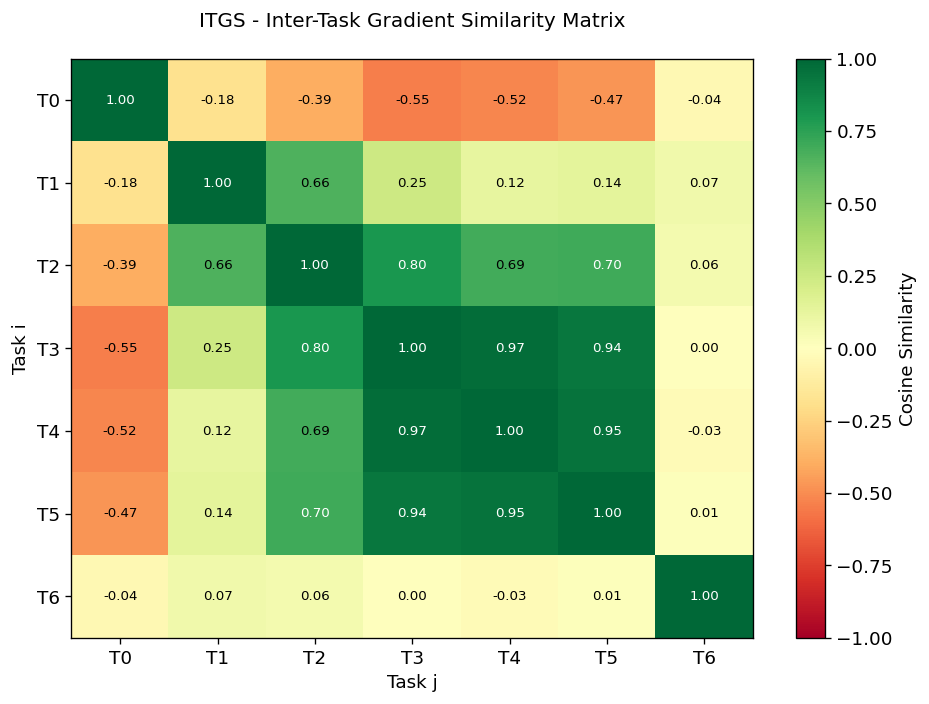

 /root/teg-cl-v3.5.10k/results/fig4_itgs_matrix.png


,T0,T1,T2,T3,T4,T5,T6
T0,1.000002,-0.183462,-0.394325,-0.546414,-0.516889,-0.474135,-0.042660
T1,-0.183462,1.000008,0.661063,0.248449,0.123865,0.138408,0.071623
T2,-0.394325,0.661063,1.000019,0.801040,0.688092,0.700250,0.059732
T3,-0.546414,0.248449,0.801040,1.000011,0.969862,0.935353,0.003717
T4,-0.516889,0.123865,0.688092,0.969862,1.000009,0.949986,-0.025303
T5,-0.474135,0.138408,0.700250,0.935353,0.949986,1.000010,0.007991
T6,-0.042660,0.071623,0.059732,0.003717,-0.025303,0.007991,1.000011


,Diagonal mean,Consecutive mean,Off-diagonal mean
0,1.0,0.5344,0.1989


 /root/teg-cl-v3.5.10k/results/itgs_analysis.json




In [ ]:
# @title Cell 24: ITGS: Inter-Task Gradient Similarity
import matplotlib.pyplot as plt

_res = CONFIG['logging']['results_dir']
# Pre-trains briefly, then computes pairwise cosine similarity between each task's gradients.
def compute_itgs(task_data_list: list,
                 config: dict,
                 device: torch.device,
                 pretrain_epochs: int = 5,
                 grad_samples: int = 500) -> np.ndarray:

    T         = len(task_data_list)
    criterion = build_criterion(config)

    # Step 1: quick pre-train (Bare, few epochs) for non-random gradients
    set_seed(42)
    model = build_model(config).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=0.001)
    print('  ITGS: pre-training model…')
    for td in task_data_list:
        model.train()
        loader = NeighborLoader(
            td['data'],
            num_neighbors = [10, 5],
            batch_size    = config['training']['batch_size'],
            input_nodes   = td['indices']['train'],
            shuffle       = True, num_workers = 0)
        for _ in range(pretrain_epochs):
            for batch in loader:
                batch = batch.to(device); opt.zero_grad()
                out   = model(batch.x, batch.edge_index).squeeze(-1)
                _bs   = batch.batch_size
                mask  = td['labeled_mask'][batch.n_id[:_bs]]
                if not mask.any(): continue
                criterion(out[:_bs][mask], batch.y[:_bs][mask].float()).backward()
                opt.step()
    print('  ITGS: computing task gradients…')

    # Step 2: per-task gradient
    model.eval()
    task_grads = []
    for ti, td in enumerate(task_data_list):
        model.zero_grad()
        train_idx = td['indices']['train']
        n    = min(grad_samples, len(train_idx))
        sel  = train_idx[torch.randperm(len(train_idx))[:n]]
        lbl  = td['data'].y.to(device)
        valid = (lbl[sel] == 0) | (lbl[sel] == 1)

        if not valid.any():
            task_grads.append(None)
            continue

        out  = model(td['data'].x, td['data'].edge_index).squeeze(-1)
        loss = criterion(out[sel[valid]], lbl[sel[valid]].float())
        loss.backward()

        grad = torch.cat([
            p.grad.detach().view(-1) if p.grad is not None
            else torch.zeros(p.numel(), device=device)
            for p in model.parameters()
        ]).cpu()
        task_grads.append(grad)
        model.zero_grad()

    # Step 3: pairwise cosine similarity
    itgs = np.full((T, T), np.nan)
    for i in range(T):
        for j in range(T):
            gi, gj = task_grads[i], task_grads[j]
            if gi is None or gj is None:
                continue
            ni, nj = gi.norm().item(), gj.norm().item()
            if ni > 1e-8 and nj > 1e-8:
                itgs[i, j] = float(torch.dot(gi, gj) / (ni * nj))
            else:
                itgs[i, j] = 1.0 if i == j else 0.0
    return itgs

print('CELL 24 - ITGS Analysis')

# Computes ITGS, or falls back to an identity matrix placeholder if skipped.
if RUN_ITGS:
    itgs_matrix = compute_itgs(task_data_list, CONFIG, DEVICE)
else:
    print('[SKIP] RUN_ITGS=False - using identity matrix placeholder')
    itgs_matrix = np.eye(len(task_data_list))
T = itgs_matrix.shape[0]

# Print ITGS matrix
print('\nITGS Matrix (Inter-Task Gradient Similarity):')
header = '      ' + ''.join(f'  T{j}   ' for j in range(T))
print(header)
for i in range(T):
    row = f'  T{i}  '
    for j in range(T):
        v = itgs_matrix[i, j]
        row += f' {v:6.3f}' if not np.isnan(v) else '    nan'
    print(row)

# Key statistics
_diag          = np.array([itgs_matrix[i,i] for i in range(T)])
_consec        = np.array([itgs_matrix[i,i+1] for i in range(T-1)
                           if not np.isnan(itgs_matrix[i,i+1])])
_off_diag_mask = ~np.eye(T, dtype=bool)
_off_diag      = itgs_matrix[_off_diag_mask]
_off_diag      = _off_diag[~np.isnan(_off_diag)]

print(f'\n  Diagonal mean (same-task):           {_diag.mean():.4f}')
print(f'  Consecutive task mean:               {_consec.mean():.4f}')
print(f'  All off-diagonal mean:               {_off_diag.mean():.4f}')
print(f'  Task 0 max similarity to others:     '
      f'{max(itgs_matrix[0,1:][~np.isnan(itgs_matrix[0,1:])], default=float("nan")):.4f}')

# ITGS heatmap
# Renders the ITGS matrix as a heatmap.
fig_itgs, ax_itgs = plt.subplots(figsize=(8, 6))
im = ax_itgs.imshow(itgs_matrix, cmap='RdYlGn',
                    vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax_itgs, label='Cosine Similarity')
ax_itgs.set_title('ITGS - Inter-Task Gradient Similarity Matrix\n'
                  '')
ax_itgs.set_xlabel('Task j')
ax_itgs.set_ylabel('Task i')
ax_itgs.set_xticks(range(T)); ax_itgs.set_xticklabels([f'T{j}' for j in range(T)])
ax_itgs.set_yticks(range(T)); ax_itgs.set_yticklabels([f'T{i}' for i in range(T)])
for i in range(T):
    for j in range(T):
        if not np.isnan(itgs_matrix[i, j]):
            ax_itgs.text(j, i, f'{itgs_matrix[i,j]:.2f}',
                         ha='center', va='center', fontsize=8,
                         color='black' if abs(itgs_matrix[i,j]) < 0.7 else 'white')
plt.tight_layout()
_itgs_fig_path = f'{_res}/fig4_itgs_matrix.png'
fig_itgs.savefig(_itgs_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f' {_itgs_fig_path}')

import pandas as pd
from IPython.display import display
display(pd.DataFrame(itgs_matrix, index=[f'T{i}' for i in range(T)],
                     columns=[f'T{j}' for j in range(T)]))
display(pd.DataFrame([{'Diagonal mean': round(_diag.mean(),4),
                       'Consecutive mean': round(_consec.mean(),4),
                       'Off-diagonal mean': round(_off_diag.mean(),4)}]))

# Save ITGS JSON
# Saves the matrix and summary statistics to disk.
_itgs_path = f'{_res}/itgs_analysis.json'
with open(_itgs_path, 'w') as f:
    json.dump({
        'itgs_matrix':          itgs_matrix.tolist(),
        'diagonal_mean':        float(_diag.mean()),
        'consecutive_mean':     float(_consec.mean()),
        'off_diagonal_mean':    float(_off_diag.mean()),
        'task0_max_similarity': float(max(itgs_matrix[0, 1:][
            ~np.isnan(itgs_matrix[0, 1:])], default=0)),
    }, f, indent=2)
print(f' {_itgs_path}')
print('\n')


## Results

Markdown/CSV export, the full results summary, diagnostic and publication
figures, subgraph visualization, investigator-workload metrics, timing
instrumentation, the H2GCN heterophily-awareness comparison, automated
regression/consistency checks, and the final report export.

In [ ]:
# @title Cell 25: Markdown Report Generation

import json, os, datetime
import numpy as np

_res = CONFIG['logging']['results_dir']
_ts  = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Self-loading block
# Loads a JSON file, returning default if it's missing or corrupt.
def _jload(path, default=None):
    try:
        with open(path) as _f:
            return json.load(_f)
    except Exception:
        return default if default is not None else {}

# Returns a variable from scope if it exists, else loads it from disk.
def _need(var_name, load_fn):
    import builtins
    try:
        val = eval(var_name)          # try current scope
        if val:
            return val
    except NameError:
        pass
    val = load_fn()
    if val:
        print(f'[LOAD] {var_name} loaded from disk')
    else:
        print(f'[WARN] {var_name} not found on disk - section will be empty')
    return val


# Loads all_results from disk if not already in scope.
try:
    _ = all_results
    if not all_results: raise NameError('empty')
except NameError:
    _raw = _jload(f'{_res}/final_comparison.json')
    all_results = {n: {**r,
        'perf_matrix': np.array(r['perf_matrix'])
                         if r.get('perf_matrix') else np.full((7,7),np.nan)}
        for n, r in _raw.items()} if _raw else {}
    print(f'[LOAD] all_results: {len(all_results)} methods from disk')

# Loads ablation results from disk if not already in scope.
try:
    _ = _abl_save
    if not _abl_save: raise NameError('empty')
except NameError:
    _abl_save = _jload(f'{_res}/ablation_studies.json')
    print(f'[LOAD] _abl_save: {len(_abl_save)} ablations from disk')

# Loads the multi-seed summary from disk if not already in scope.
try:
    _ = _ms_summary
    if not _ms_summary: raise NameError('empty')
except NameError:
    _ms_raw = _jload(f'{_res}/multi_seed_results.json')
    if _ms_raw:
        _SEEDS = resolve_seeds(CONFIG, CONFIRMATORY_RUN)
        _tegcl_f1s = [_ms_raw.get('TEG-CL',{}).get(str(s),{}).get('avg_f1',0)
                      for s in _SEEDS]
        _ms_summary = {}
        for _name, _vals in _ms_raw.items():
            _f1s = [_vals.get(str(s),{}).get('avg_f1',0) for s in _SEEDS]
            _afs = [_vals.get(str(s),{}).get('af',1)     for s in _SEEDS]
            _lo, _hi = bootstrap_ci(_f1s,
                           n_boot=CONFIG['evaluation']['n_bootstrap'],
                           ci=CONFIG['evaluation'].get('confidence_level', 0.95))
            try:
                from scipy.stats import mannwhitneyu as _mwu
                _, _pval = _mwu(_tegcl_f1s, _f1s, alternative='two-sided')
                _p = f'{_pval:.3f}'
            except Exception:
                _p = 'n/a'
            _ms_summary[_name] = {
                'f1_mean': float(np.mean(_f1s)),
                'f1_std':  float(np.std(_f1s)),
                'f1_ci':   (_lo, _hi),
                'af_mean': float(np.mean(_afs)),
                'af_std':  float(np.std(_afs)),
                'p_vs_tegcl': _p if _name != 'TEG-CL' else '-',
            }
        print(f'[LOAD] _ms_summary: {len(_ms_summary)} methods recomputed from disk')
    else:
        _ms_summary = {}
        print('[WARN] multi_seed_results.json not found')


# Loads the ITGS matrix from disk if not already in scope.
try:
    _ = itgs_matrix
except NameError:
    _itgs_raw = _jload(f'{_res}/itgs_analysis.json')
    if _itgs_raw:
        itgs_matrix = np.array(_itgs_raw['itgs_matrix'])
        print(f'[LOAD] itgs_matrix: {itgs_matrix.shape} from disk')
    else:
        itgs_matrix = None
        print('[WARN] itgs_analysis.json not found')

# Turns a list of result rows into a markdown table.
def _md_table(rows, cols):
    if not rows:
        return '_No data available._'
    lines = ['| ' + ' | '.join(cols) + ' |',
             '|' + '|'.join([':---']*len(cols)) + '|']
    for r in rows:
        lines.append('| ' + ' | '.join(str(r.get(c,'-')) for c in cols) + ' |')
    return '\n'.join(lines)

# Formats a number as text, or returns a dash if it's missing.
def _f(v, fmt='.4f'):
    try: return format(float(v), fmt)
    except: return '-'

# Build report content
_sorted_methods = sorted(all_results.items(),
                          key=lambda x: x[1].get('avg_f1',0), reverse=True)
_best_name = _sorted_methods[0][0] if _sorted_methods else '-'
_best_f1   = _sorted_methods[0][1].get('avg_f1',0) if _sorted_methods else 0
_best_abl  = max(_abl_save.items(),
                  key=lambda x: x[1].get('avg_f1',0),
                  default=('-',{'avg_f1':0}))

_exec_rows = [{'Method': n,
               'Avg.F1 ': _f(r.get('avg_f1',0)),
               'AF ':     _f(r.get('af',1)),
               'BWT':      _f(r.get('bwt',0)),
               'FWT':      _f(r.get('fwt_proxy',float('nan'))),
               'Accuracy': _f(r.get('final_accuracy',float('nan'))),
               'ROC-AUC':  _f(r.get('final_roc_auc',float('nan'))),
               'vs Bare':  f'{r.get("avg_f1",0)-all_results.get("Bare",{}).get("avg_f1",0):+.4f}'}
              for n, r in _sorted_methods]

_abl_rows = [{'Config': k,
              'Avg.F1 ': _f(v.get('avg_f1',0)),
              'AF ':     _f(v.get('af',1)),
              'BWT':      _f(v.get('bwt',0))}
             for k, v in sorted(_abl_save.items(),
                                  key=lambda x: x[1].get('avg_f1',0),
                                  reverse=True)]

_ms_rows = []
for _n, _s in _ms_summary.items():
    _lo2, _hi2 = _s.get('f1_ci', ('-','-'))
    _ms_rows.append({'Method': _n,
                     'F1 Mean':   _f(_s.get('f1_mean',0)),
                     'F1 Std':    _f(_s.get('f1_std',0)),
                     '95% CI':    f'[{_f(_lo2)},{_f(_hi2)}]',
                     'AF Mean':   _f(_s.get('af_mean',1)),
                     'p vs TEG-CL': str(_s.get('p_vs_tegcl','-'))})

# ITGS block
_itgs_rows = []
if itgs_matrix is not None:
    T = itgs_matrix.shape[0]
    _diag   = np.array([itgs_matrix[i,i] for i in range(T)])
    _consec = np.array([itgs_matrix[i,i+1] for i in range(T-1)
                        if not np.isnan(itgs_matrix[i,i+1])])
    _t0     = itgs_matrix[0,1:][~np.isnan(itgs_matrix[0,1:])]
    for i in range(T):
        r = {'Task': f'T{i}'}
        for j in range(T):
            r[f'T{j}'] = _f(itgs_matrix[i,j],'.3f')
        _itgs_rows.append(r)
    _itgs_stats = (f'Diagonal mean: **{_diag.mean():.4f}** | '
                   f'Consecutive mean: **{_consec.mean():.4f}** | '
                   f'Task 0 max sim: **{_t0.max():.4f}**')
else:
    T = 7
    _itgs_stats = '_ITGS not computed yet - run Cell 16_'

_tegcl_pm = all_results.get('TEG-CL',{}).get('perf_matrix')
_pm_rows  = []
if isinstance(_tegcl_pm, np.ndarray):
    for i in range(_tegcl_pm.shape[0]):
        r = {'After Task': f'T{i}'}
        for j in range(_tegcl_pm.shape[1]):
            v = _tegcl_pm[i,j]
            r[f'T{j}'] = _f(v) if not np.isnan(v) else '-'
        _pm_rows.append(r)

# Assembles the Executive Summary report.
_exec_md = f"""# TEG-CL: Executive Summary Report

**Generated:** {_ts}
**Environment:** Google Colab (Tesla T4 16GB)

---

## 1. Main Results (seed=42)

{_md_table(_exec_rows, ['Method','Avg.F1 ','AF ','BWT','FWT','Accuracy','ROC-AUC','vs Bare'])}

> Avg.F1 = mean F1-macro across all tasks after final task.
> AF = Average Forgetting. BWT = Backward Transfer. FWT = Forward Transfer
> proxy (next-step, not the literature zero-shot definition - see Cell 11).
> Accuracy/ROC-AUC = final task, final training stage.

---

## 2. Key Findings

- **Best method:** {_best_name} (Avg.F1 = {_f(_best_f1)})
- **TEG-CL:** Avg.F1={_f(all_results.get('TEG-CL',{}).get('avg_f1',0))} | AF={_f(all_results.get('TEG-CL',{}).get('af',1))}
- **Best ablation:** {_best_abl[0]} (Avg.F1 = {_f(_best_abl[1].get('avg_f1',0))})
- **GEM note:** If AP<0.50 this reflects gradient projection instability, not a code bug.

---

## 3. ITGS Summary

{_itgs_stats}

---

## 4. TEG-CL Performance Matrix

{_md_table(_pm_rows, ['After Task']+[f'T{j}' for j in range(T)]) if _pm_rows else '_Not available_'}

---
*Generated by TEG-CL v2.0 Cell 25 at {_ts}*
"""

# Assembles the Detailed Results report.
_detail_md = f"""# TEG-CL: Detailed Results

**Generated:** {_ts}

---

## 1. Ablation Results

{_md_table(_abl_rows, ['Config','Avg.F1 ','AF ','BWT'])}

**Ego vs Node:** {_f(_abl_save.get('Ego-Graph',{}).get('avg_f1',0))} vs {_f(_abl_save.get('Node-Only',{}).get('avg_f1',0))}
**Coverage vs Random:** {_f(_abl_save.get('Sel-Coverage',{}).get('avg_f1',0))} vs {_f(_abl_save.get('Sel-Random',{}).get('avg_f1',0))}

---

## 2. Multi-seed Statistical Validation (n=5)

{_md_table(_ms_rows, ['Method','F1 Mean','F1 Std','95% CI','AF Mean','p vs TEG-CL']) if _ms_rows else '_Cell 15a/15b not yet run_'}

> p-values: Mann-Whitney U (one-sided, TEG-CL > baseline).
> Bootstrap CI: n={CONFIG['evaluation']['n_bootstrap']} resamples.

---

## 3. ITGS Matrix

{_md_table(_itgs_rows, ['Task']+[f'T{j}' for j in range(T)]) if _itgs_rows else '_Cell 24 not yet run_'}

{_itgs_stats}

---
*Generated by TEG-CL v2.0 Cell 25 at {_ts}*
"""

# Assembles the Configuration log.
_cfg_md = f"""# TEG-CL: Configuration Log

**Generated:** {_ts}

## Hyperparameters

| Parameter | Value |
|---|---|
| input_dim | {CONFIG['model']['input_dim']} |
| hidden_dim | {CONFIG['model']['hidden_dim']} |
| batch_size | {CONFIG['training']['batch_size']} |
| buffer_size | {CONFIG['continual']['tegr']['replay_buffer_size']} |
| replay_lambda | {CONFIG['continual']['tegr']['replay_lambda']} |
| ego_hops | {CONFIG['continual']['tegr']['ego_graph_hops']} |
| selection | {CONFIG['continual']['tegr']['selection_strategy']} |
| stratified_ratio | {CONFIG['continual']['tegr']['stratified_ratio']} |
| local_epochs | {CONFIG['training']['local_epochs']} |
| learning_rate | {CONFIG['training']['learning_rate']} |
| mixed_precision | {CONFIG['training']['mixed_precision']} |
| n_seeds | {CONFIG['evaluation']['n_seeds']} |
| n_bootstrap | {CONFIG['evaluation']['n_bootstrap']} |

*Generated by TEG-CL v2.0 Cell 25 at {_ts}*
"""

for _content, _fname in [
    (_exec_md,  'TEGCL_Executive_Summary.md'),
    (_detail_md,'TEGCL_Detailed_Results.md'),
    (_cfg_md,   'TEGCL_Configuration.md'),
]:
    _path = f'{_res}/{_fname}'
    with open(_path, 'w') as _f2:
        _f2.write(_content)
    print(f' {_path}')

print('\n  Cell 25 complete - 3 markdown reports written')
print('\n')


 /root/teg-cl-v3.5.10k/results/TEGCL_Executive_Summary.md
 /root/teg-cl-v3.5.10k/results/TEGCL_Detailed_Results.md
 /root/teg-cl-v3.5.10k/results/TEGCL_Configuration.md

  Cell 25 complete - 3 markdown reports written




In [ ]:
# @title Cell 26: CSV Export

import json, os
import numpy as np
import pandas as pd
from IPython.display import display

_res = CONFIG['logging']['results_dir']

# Loads a JSON file, returns empty dict if missing.
def _jload2(path):
    try:
        with open(path) as _f: return json.load(_f)
    except Exception: return {}

# Loads all_results from disk if not already in scope.
try:
    _ = all_results
    if not all_results: raise NameError
except NameError:
    _raw = _jload2(f'{_res}/final_comparison.json')
    all_results = {n: {**r,
        'perf_matrix': np.array(r['perf_matrix'])
                         if r.get('perf_matrix') else np.full((7,7),np.nan)}
        for n, r in _raw.items()} if _raw else {}
    print(f'[LOAD] all_results: {len(all_results)} methods')

# Loads and recomputes the multi-seed summary from disk if not already in scope.
try:
    _ = _ms_summary
    if not _ms_summary: raise NameError
except NameError:
    _ms_raw2 = _jload2(f'{_res}/multi_seed_results.json')
    if _ms_raw2:
        _SEEDS2 = resolve_seeds(CONFIG, CONFIRMATORY_RUN)
        _tegcl2 = [_ms_raw2.get('TEG-CL',{}).get(str(s),{}).get('avg_f1',0)
                   for s in _SEEDS2]
        _ms_summary = {}
        for _n2, _v2 in _ms_raw2.items():
            _f1s2 = [_v2.get(str(s),{}).get('avg_f1',0) for s in _SEEDS2]
            _afs2 = [_v2.get(str(s),{}).get('af',1)     for s in _SEEDS2]
            _lo2, _hi2 = bootstrap_ci(_f1s2,
                             n_boot=CONFIG['evaluation']['n_bootstrap'],
                             ci=CONFIG['evaluation'].get('confidence_level', 0.95))
            _ms_summary[_n2] = {
                'f1_mean': float(np.mean(_f1s2)), 'f1_std': float(np.std(_f1s2)),
                'f1_ci':   (_lo2, _hi2),
                'af_mean': float(np.mean(_afs2)), 'af_std': float(np.std(_afs2)),
            }
        print(f'[LOAD] _ms_summary: {len(_ms_summary)} methods')
    else:
        _ms_summary = {}

# Loads ablation results from disk if not already in scope.
try:
    _ = _abl_save
    if not _abl_save: raise NameError
except NameError:
    _abl_save = _jload2(f'{_res}/ablation_studies.json')
    print(f'[LOAD] _abl_save: {len(_abl_save)} ablations')

# results_table.csv
# Writes the main single-seed results table.
_nan = float('nan')
_rt = pd.DataFrame([
    {'Method': n, 'Avg_F1': round(r.get('avg_f1',0),4),
     'AF': round(r.get('af',1),4), 'BWT': round(r.get('bwt',0),4),
     'FWT_proxy': round(r.get('fwt_proxy',_nan),4),
     'Final_Accuracy': round(r.get('final_accuracy',_nan),4),
     'Final_ROC_AUC':  round(r.get('final_roc_auc',_nan),4),
     'Accuracy_AF':  round(r.get('extended_metrics',{}).get('accuracy',{}).get('af',_nan),4),
     'Accuracy_BWT': round(r.get('extended_metrics',{}).get('accuracy',{}).get('bwt',_nan),4),
     'Accuracy_FWT': round(r.get('extended_metrics',{}).get('accuracy',{}).get('fwt_proxy',_nan),4),
     'ROC_AUC_AF':   round(r.get('extended_metrics',{}).get('roc_auc',{}).get('af',_nan),4),
     'ROC_AUC_BWT':  round(r.get('extended_metrics',{}).get('roc_auc',{}).get('bwt',_nan),4),
     'ROC_AUC_FWT':  round(r.get('extended_metrics',{}).get('roc_auc',{}).get('fwt_proxy',_nan),4),
     'Train_Val_Gap': round(r.get('train_val_gap',_nan),4)}
    for n, r in sorted(all_results.items(),
                        key=lambda x: x[1].get('avg_f1',0), reverse=True)
])
_rt.to_csv(f'{_res}/results_table.csv', index=False)
print(f' results_table.csv ({len(_rt)} rows) - saved to {_res}/results_table.csv')
display(_rt)

# results_ranked.csv
if len(_rt):
    _ranked = _rt.copy()
    _ranked['F1_Rank']  = _ranked['Avg_F1'].rank(ascending=False, method='dense').astype(int)
    _ranked['AF_Rank']  = _ranked['AF'].rank(ascending=True,  method='dense').astype(int)
    _ranked['BWT_Rank'] = _ranked['BWT'].rank(ascending=False, method='dense').astype(int)
    _ranked = _ranked.sort_values('F1_Rank').reset_index(drop=True)
    _ranked.to_csv(f'{_res}/results_ranked.csv', index=False)
    print(f' results_ranked.csv ({len(_ranked)} rows) - saved to {_res}/results_ranked.csv')
    display(_ranked)

# multi_seed_table.csv
# Writes the multi-seed statistics table, if available.
if _ms_summary:
    _ms_df = pd.DataFrame([
        {'Method':  n,
         'F1_Mean': round(s.get('f1_mean',0),4),
         'F1_Std':  round(s.get('f1_std',0),4),
         'F1_CI_Lo':round(s.get('f1_ci',('-','-'))[0],4)
                    if isinstance(s.get('f1_ci',(None,))[0], float) else '-',
         'F1_CI_Hi':round(s.get('f1_ci',('-','-'))[1],4)
                    if isinstance(s.get('f1_ci',(None,None))[1], float) else '-',
         'AF_Mean': round(s.get('af_mean',1),4),
         'AF_Std':  round(s.get('af_std',0),4)}
        for n, s in _ms_summary.items()
    ])
    _ms_df.to_csv(f'{_res}/multi_seed_table.csv', index=False)
    print(f' multi_seed_table.csv ({len(_ms_df)} rows)')
    display(_ms_df)
else:
    print('  multi_seed_table.csv skipped - run Cell 23 first')

# ablation_table.csv
# Writes the ablation results table, if available.
if _abl_save:
    _ab_df = pd.DataFrame([
        {'Config': k, 'Avg_F1': round(v.get('avg_f1',0),4),
         'AF': round(v.get('af',1),4), 'BWT': round(v.get('bwt',0),4)}
        for k, v in sorted(_abl_save.items(),
                             key=lambda x: x[1].get('avg_f1',0), reverse=True)
    ])
    _ab_df.to_csv(f'{_res}/ablation_table.csv', index=False)
    print(f' ablation_table.csv ({len(_ab_df)} rows)')
    display(_ab_df)
else:
    print('  ablation_table.csv skipped - run Cell 22a first')

# ITGS table
try:
    _ = itgs_matrix
except NameError:
    _it_raw = _jload2(f'{_res}/itgs_analysis.json')
    itgs_matrix = np.array(_it_raw['itgs_matrix']) if _it_raw else None

# Writes the ITGS matrix as a labeled table, if available.
if itgs_matrix is not None:
    _T = itgs_matrix.shape[0]
    _itgs_df = pd.DataFrame(
        itgs_matrix,
        index   = [f'T{i}' for i in range(_T)],
        columns = [f'T{j}' for j in range(_T)])
    _itgs_df.to_csv(f'{_res}/itgs_table.csv')
    print(f' itgs_table.csv')
    display(_itgs_df)
else:
    print('  itgs_table.csv skipped - run Cell 24 first')

print('\n  Cell 26 complete')
print('\n')


 results_table.csv (10 rows) - saved to /root/teg-cl-v3.5.10k/results/results_table.csv


,Method,Avg_F1,AF,BWT,FWT_proxy,Final_Accuracy,Final_ROC_AUC,Accuracy_AF,Accuracy_BWT,Accuracy_FWT,ROC_AUC_AF,ROC_AUC_BWT,ROC_AUC_FWT,Train_Val_Gap
0,GEM,0.7246,0.0045,0.0313,0.0061,0.7752,0.7359,0.0003,0.0400,0.0171,0.0010,0.0006,0.0014,0.0024
1,Joint,0.6990,0.0019,0.0214,0.0070,0.7117,0.7250,0.0003,0.0310,0.0123,0.0004,0.0035,0.0030,0.0008
2,TWP,0.6965,0.0105,0.0087,-0.0051,0.7715,0.7346,0.0048,0.0211,0.0049,0.0004,0.0030,0.0023,-0.0020
3,EWC,0.6962,0.0186,0.0004,-0.0100,0.7722,0.7212,0.0060,0.0208,0.0069,0.0005,0.0029,0.0023,-0.0026
4,EgoCL,0.6942,0.0028,0.0163,0.0041,0.7147,0.7033,0.0018,0.0234,0.0072,0.0002,0.0044,0.0032,0.0080
5,Bare,0.6902,0.0224,-0.0039,-0.0122,0.7610,0.7147,0.0071,0.0192,0.0061,0.0005,0.0030,0.0023,0.0031
6,Node-Replay,0.6872,0.0187,-0.0014,-0.0123,0.7670,0.6980,0.0047,0.0194,0.0051,0.0003,0.0038,0.0031,0.0046
7,TEG-CL,0.6800,0.0299,-0.0202,-0.0180,0.7565,0.7103,0.0162,-0.0019,-0.0037,0.0000,0.0034,0.0026,0.0018
8,SEA-ER,0.6665,0.0200,-0.0167,-0.0084,0.6669,0.7008,0.0159,-0.0119,-0.0068,0.0002,0.0032,0.0016,0.0055
9,DER++,0.6563,0.0003,0.0225,0.0110,0.5990,0.6488,0.0000,0.0192,0.0097,0.0003,0.0027,0.0019,0.0001


 results_ranked.csv (10 rows) - saved to /root/teg-cl-v3.5.10k/results/results_ranked.csv


,Method,Avg_F1,AF,BWT,FWT_proxy,Final_Accuracy,Final_ROC_AUC,Accuracy_AF,Accuracy_BWT,Accuracy_FWT,ROC_AUC_AF,ROC_AUC_BWT,ROC_AUC_FWT,Train_Val_Gap,F1_Rank,AF_Rank,BWT_Rank
0,GEM,0.7246,0.0045,0.0313,0.0061,0.7752,0.7359,0.0003,0.0400,0.0171,0.0010,0.0006,0.0014,0.0024,1,4,1
1,Joint,0.6990,0.0019,0.0214,0.0070,0.7117,0.7250,0.0003,0.0310,0.0123,0.0004,0.0035,0.0030,0.0008,2,2,3
2,TWP,0.6965,0.0105,0.0087,-0.0051,0.7715,0.7346,0.0048,0.0211,0.0049,0.0004,0.0030,0.0023,-0.0020,3,5,5
3,EWC,0.6962,0.0186,0.0004,-0.0100,0.7722,0.7212,0.0060,0.0208,0.0069,0.0005,0.0029,0.0023,-0.0026,4,6,6
4,EgoCL,0.6942,0.0028,0.0163,0.0041,0.7147,0.7033,0.0018,0.0234,0.0072,0.0002,0.0044,0.0032,0.0080,5,3,4
5,Bare,0.6902,0.0224,-0.0039,-0.0122,0.7610,0.7147,0.0071,0.0192,0.0061,0.0005,0.0030,0.0023,0.0031,6,9,8
6,Node-Replay,0.6872,0.0187,-0.0014,-0.0123,0.7670,0.6980,0.0047,0.0194,0.0051,0.0003,0.0038,0.0031,0.0046,7,7,7
7,TEG-CL,0.6800,0.0299,-0.0202,-0.0180,0.7565,0.7103,0.0162,-0.0019,-0.0037,0.0000,0.0034,0.0026,0.0018,8,10,10
8,SEA-ER,0.6665,0.0200,-0.0167,-0.0084,0.6669,0.7008,0.0159,-0.0119,-0.0068,0.0002,0.0032,0.0016,0.0055,9,8,9
9,DER++,0.6563,0.0003,0.0225,0.0110,0.5990,0.6488,0.0000,0.0192,0.0097,0.0003,0.0027,0.0019,0.0001,10,1,2


 multi_seed_table.csv (10 rows)


...

 ablation_table.csv (20 rows)


,Config,Avg_F1,AF,BWT
0,Strat-off,0.6975,0.0151,-0.0007
1,SEAER-Unstrat,0.6940,0.0075,0.0108
2,Lambda-0.5,0.6871,0.0282,-0.0126
3,Node-Only,0.6868,0.0186,-0.0014
4,Strat-50,0.6835,0.0261,-0.0153
5,Sel-Coverage,0.6813,0.0281,-0.0189
6,Hops-3,0.6809,0.0246,-0.0131
7,Strat-80,0.6795,0.0242,-0.0189
8,Sel-Random,0.6782,0.0141,-0.0036
9,Buf-250,0.6773,0.0230,-0.0114


 itgs_table.csv


,T0,T1,T2,T3,T4,T5,T6
T0,1.000002,-0.183462,-0.394325,-0.546414,-0.516889,-0.474135,-0.042660
T1,-0.183462,1.000008,0.661063,0.248449,0.123865,0.138408,0.071623
T2,-0.394325,0.661063,1.000019,0.801040,0.688092,0.700250,0.059732
T3,-0.546414,0.248449,0.801040,1.000011,0.969862,0.935353,0.003717
T4,-0.516889,0.123865,0.688092,0.969862,1.000009,0.949986,-0.025303
T5,-0.474135,0.138408,0.700250,0.935353,0.949986,1.000010,0.007991
T6,-0.042660,0.071623,0.059732,0.003717,-0.025303,0.007991,1.000011



  Cell 26 complete




In [ ]:
# @title Cell 27: Full Results Summary + Markdown Export

import json, os, datetime
import numpy as np

_res = CONFIG['logging']['results_dir']
_ts  = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Loads a JSON file, returns empty dict if missing.
def _jload3(path):
    try:
        with open(path) as _f: return json.load(_f)
    except Exception: return {}

# Formats a number as text, or returns a dash if it's missing.
def _f3(v, fmt='.4f'):
    try: return format(float(v), fmt)
    except: return '-'

# Turns a list of result rows into a markdown table.
def _md_t(rows, cols):
    if not rows: return '_No data_'
    lines = ['| '+'| '.join(cols)+' |',
             '|'+('|'.join([':---']*len(cols)))+'|']
    for r in rows:
        lines.append('| '+'| '.join(str(r.get(c,'-')) for c in cols)+' |')
    return '\n'.join(lines)

# Load everything from disk if not in scope
print('CELL 19 - Loading results')

# Loads all_results from disk if not already in scope.
try:
    _ = all_results; assert all_results
except (NameError, AssertionError):
    _raw = _jload3(f'{_res}/final_comparison.json')
    all_results = {n:{**r,'perf_matrix':
        np.array(r['perf_matrix']) if r.get('perf_matrix') else np.full((7,7),np.nan)}
        for n,r in _raw.items()} if _raw else {}
    print(f'[LOAD] all_results: {len(all_results)} methods')

# Loads ablation results from disk if not already in scope.
try:
    _ = ABL_GROUPS; assert ABL_GROUPS
except (NameError, AssertionError):
    ABL_GROUPS = _jload3(f'{_res}/ablation_studies.json')
    print(f'[LOAD] ABL_GROUPS: {len(ABL_GROUPS)} ablations')

# Loads raw multi-seed results from disk if not already in scope.
try:
    _ = multi_seed; assert multi_seed
except (NameError, AssertionError):
    multi_seed = _jload3(f'{_res}/multi_seed_results.json')
    print(f'[LOAD] multi_seed: loaded')

# Recomputes the multi-seed summary using the correct seed set for CONFIRMATORY_RUN.
try:
    _ = _ms_summary; assert _ms_summary
except (NameError, AssertionError):
    _ms_raw3 = multi_seed
    if _ms_raw3:
        _SEEDS3   = resolve_seeds(CONFIG, CONFIRMATORY_RUN)
        _tegcl3   = [_ms_raw3.get('TEG-CL',{}).get(str(s),{}).get('avg_f1',0)
                     for s in _SEEDS3]

        _ms_summary = {}
        _raw_p3 = {}
        for _n3, _v3 in _ms_raw3.items():
            if _n3 == 'TEG-CL': continue
            _f1s3 = [_v3.get(str(s),{}).get('avg_f1',0) for s in _SEEDS3]
            if len(_f1s3) != len(_tegcl3): continue
            try:
                from scipy.stats import mannwhitneyu as _mwu3
                _, _raw_p3[_n3] = _mwu3(_tegcl3, _f1s3, alternative='two-sided')
            except Exception:
                pass
        _corr_p3 = _holm(_raw_p3) if '_holm' in dir() else _raw_p3

        for _n3, _v3 in _ms_raw3.items():
            _f1s3 = [_v3.get(str(s),{}).get('avg_f1',0) for s in _SEEDS3]
            _afs3 = [_v3.get(str(s),{}).get('af',1)     for s in _SEEDS3]
            _lo3, _hi3 = bootstrap_ci(_f1s3,
                             n_boot=CONFIG['evaluation']['n_bootstrap'],
                             ci=CONFIG['evaluation'].get('confidence_level', 0.95))
            _p3 = f'{_corr_p3[_n3]:.3f}' if _n3 in _corr_p3 else '-'
            _ms_summary[_n3] = {
                'f1_mean': float(np.mean(_f1s3)),
                'f1_std':  float(np.std(_f1s3)),
                'f1_ci':   (_lo3, _hi3),
                'af_mean': float(np.mean(_afs3)),
                'p_vs_tegcl': _p3,
            }
        print(f'[LOAD] _ms_summary: {len(_ms_summary)} methods recomputed '
              f'(two-sided, Holm-corrected)')
    else:
        _ms_summary = {}
        print('[LOAD] _ms_summary: multi_seed empty - run Cell 23 first')

# Loads the ITGS matrix from disk if not already in scope.
try:
    _ = itgs_matrix
except NameError:
    _it3 = _jload3(f'{_res}/itgs_analysis.json')
    itgs_matrix = np.array(_it3['itgs_matrix']) if _it3 else None
    if itgs_matrix is not None:
        print(f'[LOAD] itgs_matrix: {itgs_matrix.shape}')

# Prints the run environment.
# Section 1: Environment
print('\nENVIRONMENT')
print(f'  Generated:  {_ts}')
print(f'  GPU:        {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'  PyTorch:    {torch.__version__}')
print(f'  input_dim:  {CONFIG["model"]["input_dim"]}')
print(f'  buffer:     {CONFIG["continual"]["tegr"]["replay_buffer_size"]}')
print(f'  n_seeds:    {CONFIG["evaluation"]["n_seeds"]}')

# Prints and tabulates the main single-seed results.
# Section 2: Main Results
print('\nMAIN RESULTS  (seed=42)')
_sm = sorted(all_results.items(), key=lambda x: x[1].get('avg_f1',0), reverse=True)
_main_rows = []
if _sm:
    print(f'\n{"Method":<16} {"Avg.F1":>8} {"AF":>8} {"BWT":>8} {"FWT":>8} {"Accuracy":>9} {"ROC-AUC":>8}')
    for _n, _r in _sm:
        _tag = ' <- best' if _n == _sm[0][0] else ''
        print(f'{_n:<16} {_f3(_r.get("avg_f1",0)):>8} '
              f'{_f3(_r.get("af",1)):>8} {_f3(_r.get("bwt",0)):>8} '
              f'{_f3(_r.get("fwt_proxy",float("nan"))):>8} '
              f'{_f3(_r.get("final_accuracy",float("nan"))):>8} '
              f'{_f3(_r.get("final_roc_auc",float("nan"))):>8}{_tag}')
        _main_rows.append({'Method':_n, 'Avg.F1':_f3(_r.get('avg_f1',0)),
                           'AF':_f3(_r.get('af',1)), 'BWT':_f3(_r.get('bwt',0)),
                           'FWT':_f3(_r.get('fwt_proxy',float('nan'))),
                           'Accuracy':_f3(_r.get('final_accuracy',float('nan'))),
                           'ROC-AUC':_f3(_r.get('final_roc_auc',float('nan')))})
else:
    print('    No results - run Cell 12 or ensure final_comparison.json exists')

# Prints ablation highlights: best config, Ego vs Node, Coverage vs Random.
# Section 3: Ablations
print('\nABLATION HIGHLIGHTS')
_abl_rows19 = []
if ABL_GROUPS:
    _best_a = max(ABL_GROUPS.items(), key=lambda x: x[1].get('avg_f1',0))
    print(f'  Best config:      {_best_a[0]} (Avg.F1={_f3(_best_a[1].get("avg_f1",0))})')
    print(f'  Ego vs Node:      {_f3(ABL_GROUPS.get("Ego-Graph",{}).get("avg_f1",0))} '
          f'vs {_f3(ABL_GROUPS.get("Node-Only",{}).get("avg_f1",0))}')
    print(f'  Coverage vs Rand: {_f3(ABL_GROUPS.get("Sel-Coverage",{}).get("avg_f1",0))} '
          f'vs {_f3(ABL_GROUPS.get("Sel-Random",{}).get("avg_f1",0))}')
    for _k, _v in sorted(ABL_GROUPS.items(),
                          key=lambda x: x[1].get('avg_f1',0), reverse=True):
        _abl_rows19.append({'Config':_k,'Avg.F1':_f3(_v.get('avg_f1',0)),
                            'AF':_f3(_v.get('af',1)),
                            'BWT':_f3(_v.get('bwt',0)),
                            'FWT':_f3(_v.get('fwt_proxy',float('nan')))})
else:
    print('    ABL_GROUPS empty - run Cell 14 first')

# Prints multi-seed statistics for every method.
# Section 4: Multi-seed
print('\nMULTI-SEED STATISTICS')
_ms_rows19 = []
if _ms_summary:
    print(f'\n{"Method":<14} {"F1 Mean":>8} {"± Std":>7} {"AF Mean":>8} '
          f'{"BWT Mean":>9} {"FWT Mean":>9} {"p":>8}')
    for _n, _s in _ms_summary.items():
        print(f'{_n:<14} {_f3(_s.get("f1_mean",0)):>8} '
              f'±{_f3(_s.get("f1_std",0)):>6} '
              f'{_f3(_s.get("af_mean",1)):>8} '
              f'{_f3(_s.get("bwt_mean",0)):>9} '
              f'{_f3(_s.get("fwt_mean",float("nan"))):>9} '
              f'{str(_s.get("p_vs_tegcl","-")):>8}')
        _lo4, _hi4 = _s.get('f1_ci',('-','-'))
        _ms_rows19.append({'Method':_n,
            'F1 Mean':_f3(_s.get('f1_mean',0)),
            'F1 Std': _f3(_s.get('f1_std',0)),
            '95% CI': f'[{_f3(_lo4)},{_f3(_hi4)}]',
            'AF Mean':_f3(_s.get('af_mean',1)),
            'BWT Mean':_f3(_s.get('bwt_mean',0)),
            'FWT Mean':_f3(_s.get('fwt_mean',float('nan'))),
            'p vs TEG-CL':str(_s.get('p_vs_tegcl','-'))})
else:
    print('    No multi-seed data - run Cells 15a/15b first')

# Section 5: ITGS
print('\nITGS ANALYSIS')
_itgs_rows19 = []
_itgs_stats19 = '_Not computed_'
if itgs_matrix is not None:
    T4 = itgs_matrix.shape[0]
    _d4 = np.array([itgs_matrix[i,i] for i in range(T4)])
    _c4 = np.array([itgs_matrix[i,i+1] for i in range(T4-1)
                    if not np.isnan(itgs_matrix[i,i+1])])
    _t04 = itgs_matrix[0,1:][~np.isnan(itgs_matrix[0,1:])]
    print(f'  Diagonal mean:     {_d4.mean():.4f}')
    print(f'  Consecutive mean:  {_c4.mean():.4f}')
    print(f'  Task 0 max sim:    {_t04.max():.4f}')
    _itgs_stats19 = (f'Diagonal: **{_d4.mean():.4f}** | '
                     f'Consecutive: **{_c4.mean():.4f}** | '
                     f'T0 max sim: **{_t04.max():.4f}**')
    for i in range(T4):
        r19 = {'Task': f'T{i}'}
        for j in range(T4):
            r19[f'T{j}'] = _f3(itgs_matrix[i,j],'.3f')
        _itgs_rows19.append(r19)
else:
    print('    itgs_matrix not available - run Cell 16 first')
    T4 = 7

# Section 6: File manifest
print('\nOUTPUT FILES (Cells 12-18 only - see Cell 27 for the full run manifest)')
_files19 = [
    ('JSON',   'final_comparison.json'),
    ('JSON',   'ablation_studies.json'),
    ('JSON',   'multi_seed_results.json'),
    ('JSON',   'itgs_analysis.json'),
    ('JSON',   'confirmatory_results.json'),
    ('Figure', 'fig1_avgf1_af.png'),
    ('Figure', 'fig2_perf_matrix.png'),
    ('Figure', 'fig3_forgetting_curves.png'),
    ('Figure', 'fig4_itgs_matrix.png'),
    ('CSV',    'results_table.csv'),
    ('CSV',    'results_ranked.csv'),
    ('CSV',    'multi_seed_table.csv'),
    ('CSV',    'ablation_table.csv'),
    ('CSV',    'itgs_table.csv'),
]
_mf_rows = []
for _cat, _fn in _files19:
    _fp  = f'{_res}/{_fn}'
    _ok  = os.path.exists(_fp)
    _sz  = f'{os.path.getsize(_fp):,}b' if _ok else '-'
    print(f'  {"" if _ok else ""}  [{_cat:<7}]  {_fn:<42} {_sz}')
    _mf_rows.append({'Type':_cat,'File':_fn,'Exists':'' if _ok else '','Size':_sz})

# Export markdown
_pm_rows19 = []
_tegcl_pm = all_results.get('TEG-CL',{}).get('perf_matrix')
if isinstance(_tegcl_pm, np.ndarray):
    for i in range(_tegcl_pm.shape[0]):
        r19b = {'After Task': f'T{i}'}
        for j in range(_tegcl_pm.shape[1]):
            v = _tegcl_pm[i,j]
            r19b[f'T{j}'] = _f3(v) if not np.isnan(v) else '-'
        _pm_rows19.append(r19b)




# Section 8: Extended Diagnostics (Cells 21-25)
print('\nEXTENDED DIAGNOSTICS (Cells 21-25) - '
      'only accurate if re-run after a full pass; see Cell 27 otherwise')
_diag_rows19 = []

# Cell 21 - Ablation 2D grid (buffer_size x replay_lambda)
_ag = _jload3(f'{_res}/ablation_2d_grid.json')
if _ag:
    _grid = np.array(_ag['avg_f1'])
    _bi, _li = np.unravel_index(np.nanargmax(_grid), _grid.shape)
    _best_cfg = f"buffer={_ag['buffers'][_bi]}, lambda={_ag['lambdas'][_li]}"
    print(f'  Cell 21 [2D Grid]     best config: {_best_cfg} '
          f'(Avg.F1={_grid[_bi,_li]:.4f})')
    _diag_rows19.append({'Cell':'21 - 2D Grid','Metric':'Best config',
                         'Value':f'{_best_cfg} (F1={_grid[_bi,_li]:.4f})'})
else:
    print('  Cell 21 [2D Grid]     not run')

# Cell 22 - NetworkX subgraph viz (figures only, no scalar metrics)
_c22_figs = ['fig16_degree_distribution.png', 'fig17_subgraph_visualization.png']
_c22_ok = [f for f in _c22_figs if os.path.exists(f'{_res}/{f}')]
print(f'  Cell 22 [Subgraph Viz] {len(_c22_ok)}/{len(_c22_figs)} figures present')
_diag_rows19.append({'Cell':'22 - Subgraph Viz','Metric':'Figures',
                     'Value':f'{len(_c22_ok)}/{len(_c22_figs)} present'})

# Cell 23 - Hits@K / P@K
_hk = _jload3(f'{_res}/hitsk_results.json')
if _hk:
    _best_hk = max(_hk.items(), key=lambda x: x[1].get('hitsk_hits@k', 0))
    print(f"  Cell 23 [Hits@K]      top: {_best_hk[0]} "
          f"(Hits@50={_best_hk[1].get('hitsk_hits@k',0)}, "
          f"PR-AUC={_best_hk[1].get('hitsk_pr_auc',0):.4f})")
    _diag_rows19.append({'Cell':'23 - Hits@K','Metric':'Top method',
                         'Value':f"{_best_hk[0]} (Hits@50={_best_hk[1].get('hitsk_hits@k',0)})"})
else:
    print('  Cell 23 [Hits@K]      not run')

# Cell 24 - Timing / GPU memory
_tm = _jload3(f'{_res}/timing_results.json')
if _tm:
    _fastest = min(_tm.items(), key=lambda x: x[1].get('total_minutes', float('inf')))
    _peak_gpu = max((v.get('peak_gpu_mb', 0) for v in _tm.values()), default=0)
    print(f"  Cell 24 [Timing]      fastest: {_fastest[0]} "
          f"({_fastest[1].get('total_minutes',0):.2f} min), "
          f"peak GPU={_peak_gpu:.0f}MB")
    _diag_rows19.append({'Cell':'24 - Timing','Metric':'Fastest / Peak GPU',
                         'Value':f"{_fastest[0]} ({_fastest[1].get('total_minutes',0):.2f}min) / {_peak_gpu:.0f}MB"})
else:
    print('  Cell 24 [Timing]      not run')

# Cell 25 - H2GCN heterophily test
_h2 = _jload3(f'{_res}/h2gcn_comparison.json')
if _h2:
    _delta = _h2.get('delta_avg_f1', 0)
    _verdict = ('H2GCN outperforms' if _delta > 0.01 else
                'GraphSAGE outperforms' if _delta < -0.01 else
                'Negligible difference')
    print(f"  Cell 25 [H2GCN]       GraphSAGE={_h2['graphsage']['avg_f1']:.4f} "
          f"vs H2GCN={_h2['h2gcn']['avg_f1']:.4f} (delta={_delta:+.4f}) -> {_verdict}")
    _diag_rows19.append({'Cell':'25 - H2GCN','Metric':'Delta / Verdict',
                         'Value':f'{_delta:+.4f} -> {_verdict}'})
else:
    print('  Cell 25 [H2GCN]       not run')




_export_md = f"""# TEG-CL Run Output - Analysis Export


**Generated:** {_ts}
**GPU:** {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}
**PyTorch:** {torch.__version__}
**Config:** input_dim={CONFIG['model']['input_dim']} hidden={CONFIG['model']['hidden_dim']} buffer={CONFIG['continual']['tegr']['replay_buffer_size']} seeds={CONFIG['evaluation']['n_seeds']}

---

## 1. Main Results (seed=42)

{_md_t(_main_rows, ['Method','Avg.F1','AF','BWT','FWT','Accuracy','ROC-AUC'])}

---

## 2. Ablation Results

{_md_t(_abl_rows19, ['Config','Avg.F1','AF','BWT','FWT'])}

**Ego vs Node:** {_f3(ABL_GROUPS.get('Ego-Graph',{}).get('avg_f1',0))} vs {_f3(ABL_GROUPS.get('Node-Only',{}).get('avg_f1',0))}
**Coverage vs Random:** {_f3(ABL_GROUPS.get('Sel-Coverage',{}).get('avg_f1',0))} vs {_f3(ABL_GROUPS.get('Sel-Random',{}).get('avg_f1',0))}

---

## 3. Multi-Seed Statistical Validation (n=5)

{_md_t(_ms_rows19, ['Method','F1 Mean','F1 Std','95% CI','AF Mean','BWT Mean','FWT Mean','p vs TEG-CL'])}

---

## 4. ITGS Matrix

{_md_t(_itgs_rows19, ['Task']+[f'T{j}' for j in range(T4)])}

{_itgs_stats19}

---

## 5. TEG-CL Performance Matrix

{_md_t(_pm_rows19, ['After Task']+[f'T{j}' for j in range(T4)])}

---

## 6. Output File Manifest

{_md_t(_mf_rows, ['Type','File','Exists','Size'])}

---

## 7. Configuration

```yaml
input_dim:      {CONFIG['model']['input_dim']}
hidden_dim:     {CONFIG['model']['hidden_dim']}
batch_size:     {CONFIG['training']['batch_size']}
buffer_size:    {CONFIG['continual']['tegr']['replay_buffer_size']}
replay_lambda:  {CONFIG['continual']['tegr']['replay_lambda']}
ego_hops:       {CONFIG['continual']['tegr']['ego_graph_hops']}
selection:      {CONFIG['continual']['tegr']['selection_strategy']}
stratified:     {CONFIG['continual']['tegr']['stratified_ratio']}
local_epochs:   {CONFIG['training']['local_epochs']}
learning_rate:  {CONFIG['training']['learning_rate']}
mixed_precision:{CONFIG['training']['mixed_precision']}
n_seeds:        {CONFIG['evaluation']['n_seeds']}
n_bootstrap:    {CONFIG['evaluation']['n_bootstrap']}

---


## 8. Extended Diagnostics (Cells 21-25)

{_md_t(_diag_rows19, ['Cell','Metric','Value'])}

---


*Exported by TEG-CL v2.0 Cell 27 at {_ts}*
"""

_export_path = f'{ROOT}/results/TEGCL_Run_Output.md'
with open(_export_path, 'w') as _f_out:
    _f_out.write(_export_md)

print(f'\n {_export_path}  ({os.path.getsize(_export_path):,} bytes)')
print(f'\n  CELL 27 COMPLETE')
print(f'    Send TEGCL_Run_Output.md here for analysis.')
print('\n')


CELL 19 - Loading results

ENVIRONMENT
  Generated:  2026-08-24 16:56:21
  GPU:        Tesla T4
  PyTorch:    2.10.0+cu128
  input_dim:  169
  buffer:     500
  n_seeds:    5

MAIN RESULTS  (seed=42)

Method             Avg.F1       AF      BWT      FWT  Accuracy  ROC-AUC
GEM                0.7246   0.0045   0.0313   0.0061   0.7752   0.7359 <- best
Joint              0.6990   0.0019   0.0214   0.0070   0.7117   0.7250
TWP                0.6965   0.0105   0.0087  -0.0051   0.7715   0.7346
EWC                0.6962   0.0186   0.0004  -0.0100   0.7722   0.7212
EgoCL              0.6942   0.0028   0.0163   0.0041   0.7147   0.7033
Bare               0.6902   0.0224  -0.0039  -0.0122   0.7610   0.7147
Node-Replay        0.6872   0.0187  -0.0014  -0.0123   0.7670   0.6980
TEG-CL             0.6800   0.0299  -0.0202  -0.0180   0.7565   0.7103
SEA-ER             0.6665   0.0200  -0.0167  -0.0084   0.6669   0.7008
DER++              0.6563   0.0003   0.0225   0.0110   0.5990   0.6488

ABLATION

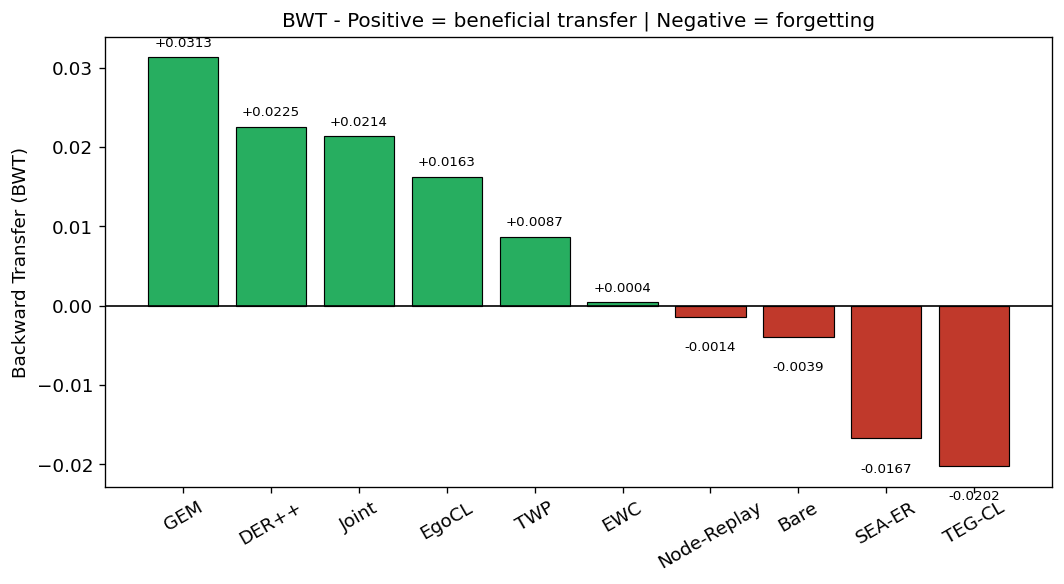

 /root/teg-cl-v3.5.10k/results/fig5_bwt_bar.png


,Method,BWT,FWT
0,GEM,0.031321,0.006054
1,DER++,0.022529,0.010990
2,Joint,0.021364,0.007016
3,EgoCL,0.016256,0.004119
4,TWP,0.008660,-0.005124
5,EWC,0.000422,-0.009989
6,Node-Replay,-0.001420,-0.012290
7,Bare,-0.003927,-0.012190
8,SEA-ER,-0.016718,-0.008447
9,TEG-CL,-0.020209,-0.017991


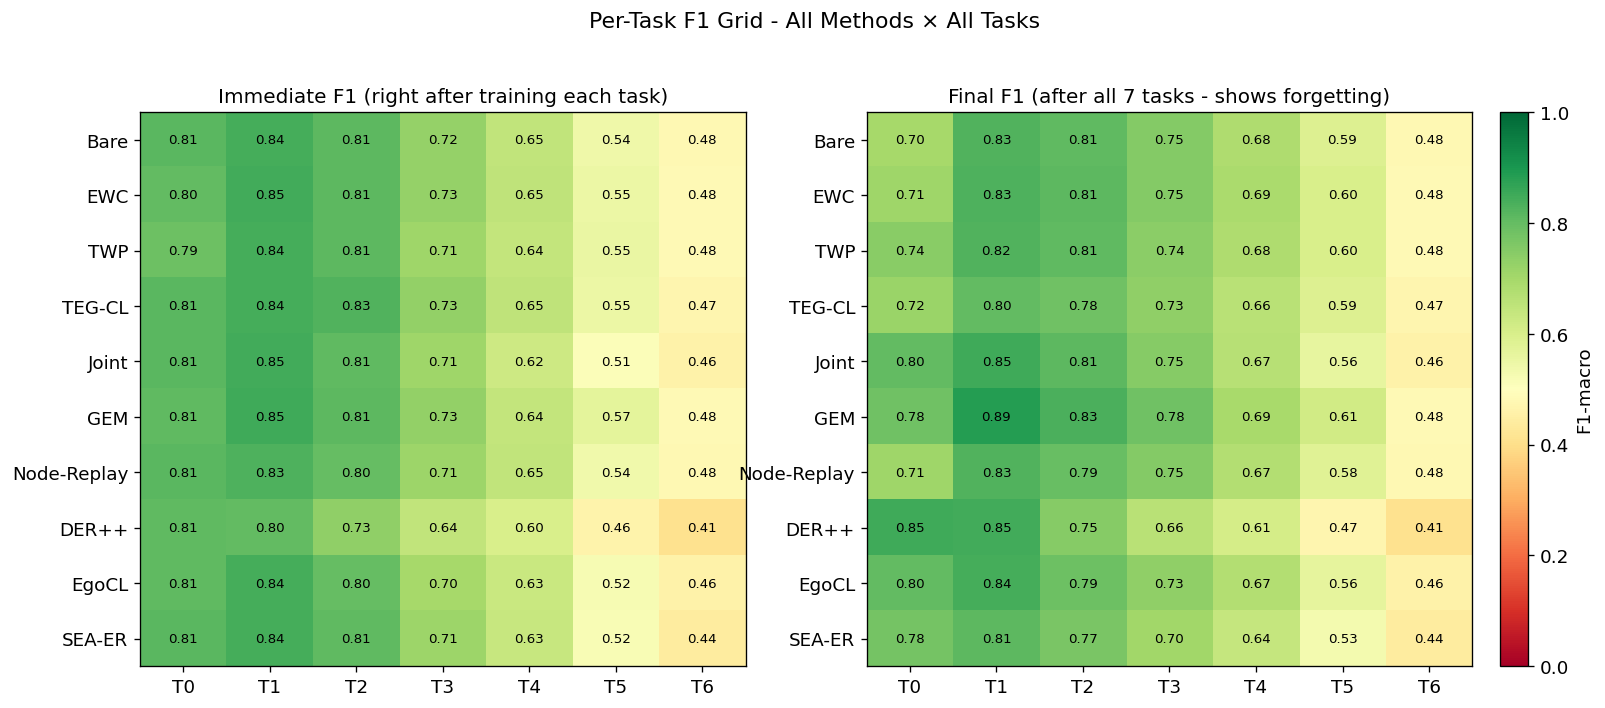

 /root/teg-cl-v3.5.10k/results/fig6_per_task_f1_grid.png


,T0,T1,T2,T3,T4,T5,T6
Bare,0.812582,0.841697,0.810466,0.723955,0.647102,0.542739,0.476667
EWC,0.804499,0.846474,0.811643,0.725966,0.650830,0.549020,0.482335
TWP,0.786731,0.840513,0.810412,0.709303,0.640645,0.553757,0.481953
TEG-CL,0.812582,0.842886,0.827961,0.726816,0.649753,0.549020,0.471937
Joint,0.812582,0.846474,0.807518,0.708029,0.621649,0.509674,0.459186
GEM,0.808491,0.849427,0.808685,0.726816,0.643067,0.566620,0.481193
Node-Replay,0.812582,0.830014,0.800000,0.713899,0.648164,0.537027,0.477079
DER++,0.808491,0.801678,0.731941,0.644878,0.599459,0.462897,0.409826
EgoCL,0.808491,0.842886,0.797674,0.698784,0.632555,0.522591,0.458549
SEA-ER,0.812582,0.842327,0.807471,0.713139,0.632942,0.518133,0.439419


,T0,T1,T2,T3,T4,T5,T6
Bare,0.697637,0.825439,0.807550,0.752055,0.682921,0.589377,0.476667
EWC,0.709670,0.831166,0.809898,0.752055,0.690498,0.597676,0.482335
TWP,0.744842,0.824304,0.805755,0.738901,0.681471,0.598048,0.481953
TEG-CL,0.717088,0.803340,0.783740,0.734152,0.660248,0.589195,0.471937
Joint,0.801467,0.847678,0.809244,0.748935,0.667582,0.559205,0.459186
GEM,0.781308,0.886645,0.832692,0.782354,0.693082,0.614947,0.481193
Node-Replay,0.709441,0.826578,0.794281,0.750042,0.672475,0.580348,0.477079
DER++,0.851318,0.846284,0.748641,0.661357,0.606205,0.470714,0.409826
EgoCL,0.804499,0.839949,0.787582,0.731055,0.672980,0.564455,0.458549
SEA-ER,0.777053,0.808749,0.765995,0.703955,0.640189,0.530343,0.439419


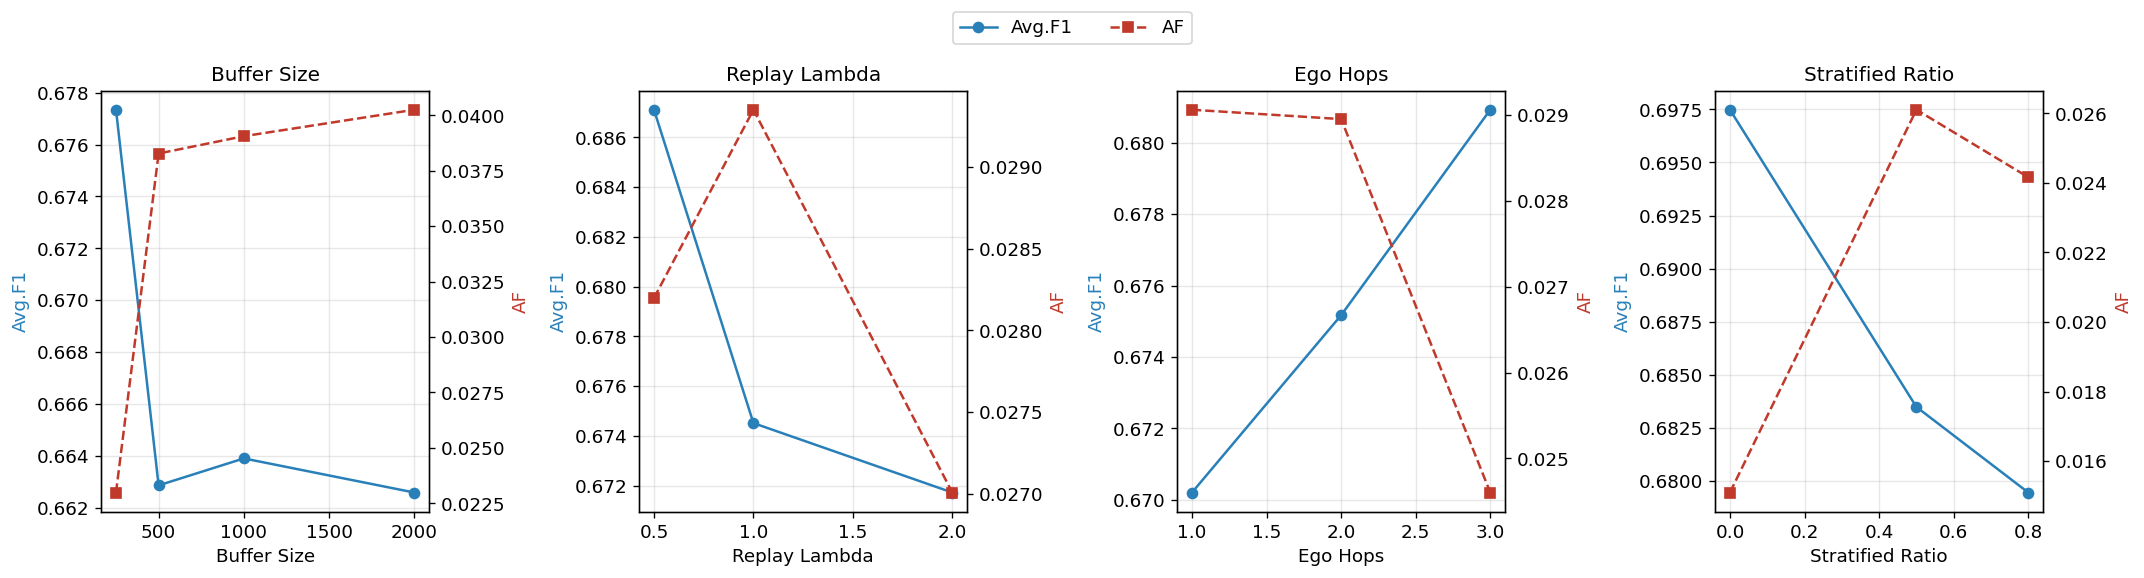

 /root/teg-cl-v3.5.10k/results/fig7_ablation_sweeps.png


,Buffer Size,Avg.F1,AF
0,250,0.677343,0.022985
1,500,0.662855,0.038277
2,1000,0.663894,0.039058
3,2000,0.662579,0.040252


,Replay Lambda,Avg.F1,AF
0,0.5,0.687112,0.028198
1,1.0,0.674520,0.029350
2,2.0,0.671730,0.027008


,Ego Hops,Avg.F1,AF
0,1,0.670208,0.029060
1,2,0.675168,0.028951
2,3,0.680918,0.024603


,Stratified Ratio,Avg.F1,AF
0,0.0,0.697478,0.015100
1,0.5,0.683494,0.026102
2,0.8,0.679467,0.024162


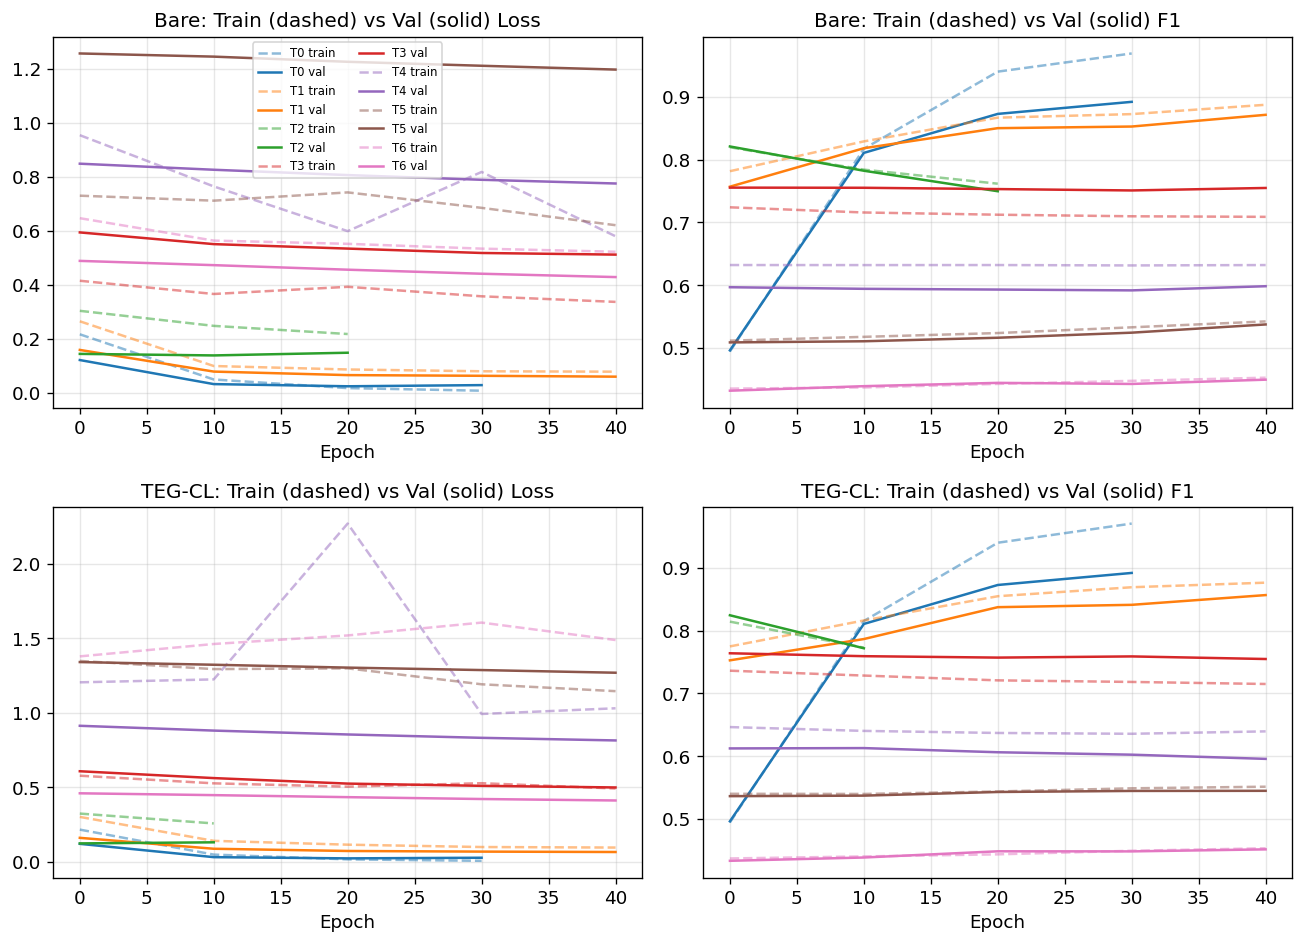

 /root/teg-cl-v3.5.10k/results/fig18_train_val_curves.png


,task,epoch,train_loss,val_loss,train_f1,val_f1
0,0,0,0.216524,0.121124,0.494672,0.496308
1,0,10,0.049047,0.031941,0.817304,0.810819
2,0,20,0.017082,0.023868,0.940181,0.872870
3,0,30,0.007453,0.028162,0.969110,0.892075
4,1,0,0.264724,0.158589,0.781649,0.756976
5,1,10,0.098950,0.078310,0.829102,0.818219
6,1,20,0.086130,0.065262,0.866901,0.850167
7,1,30,0.079494,0.062732,0.872541,0.852751
8,1,40,0.077986,0.059502,0.887400,0.871409
9,2,0,0.303551,0.143926,0.819770,0.821014


  Bare stopping epochs by task: {0: 34, 1: 49, 2: 22, 3: 49, 4: 49, 5: 49, 6: 49}
  Bare final train-val gap: 0.0031


,task,epoch,train_loss,val_loss,train_f1,val_f1
0,0,0,0.216525,0.121134,0.494672,0.496308
1,0,10,0.049025,0.031944,0.815447,0.810819
2,0,20,0.017071,0.023783,0.940181,0.872870
3,0,30,0.007458,0.028019,0.970730,0.892075
4,1,0,0.301752,0.161415,0.775018,0.752821
5,1,10,0.141232,0.088214,0.816339,0.786746
6,1,20,0.115594,0.073308,0.854969,0.837530
7,1,30,0.099830,0.069086,0.869279,0.841253
8,1,40,0.096317,0.066407,0.876568,0.856777
9,2,0,0.324107,0.124179,0.814476,0.824621


  TEG-CL stopping epochs by task: {0: 34, 1: 49, 2: 19, 3: 49, 4: 49, 5: 49, 6: 49}
  TEG-CL final train-val gap: 0.0018

  Cell 28 complete - 4 instant figures saved (fig5, fig6, fig7, fig18)




In [ ]:
# @title Cell 28: Additional Diagnostic Figures (instant, no retraining)

import json, os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'figure.dpi': 120})
_res = CONFIG['logging']['results_dir']

# Loads a JSON file, returns empty dict if missing.
def _jload4(path):
    try:
        with open(path) as f: return json.load(f)
    except Exception: return {}

# Loads all_results from disk if not already in scope.
try:
    _ = all_results; assert all_results
except (NameError, AssertionError):
    _raw = _jload4(f'{_res}/final_comparison.json')
    all_results = {n: {**r, 'perf_matrix':
        np.array(r['perf_matrix']) if r.get('perf_matrix') else np.full((7,7),np.nan)}
        for n, r in _raw.items()}
    print(f'[LOAD] all_results: {len(all_results)} methods')

# Loads ablation results from disk if not already in scope.
try:
    _ = _abl_save; assert _abl_save
except (NameError, AssertionError):
    _abl_save = _jload4(f'{_res}/ablation_studies.json')
    print(f'[LOAD] _abl_save: {len(_abl_save)} ablations')

_colors = {n: '#2980b9' for n in all_results}

# FIG 5 - BWT Bar Chart
_sm   = sorted(all_results.items(), key=lambda x: x[1].get('bwt', 0), reverse=True)
_names5 = [n for n, _ in _sm]
_bwts   = [r.get('bwt', 0) for _, r in _sm]
_clrs5  = ['#27ae60' if b >= 0 else '#c0392b' for b in _bwts]

# FIG 5: BWT bar chart, green for positive transfer, red for negative.
fig5, ax5 = plt.subplots(figsize=(9, 5))
bars5 = ax5.bar(_names5, _bwts, color=_clrs5, edgecolor='black', linewidth=0.7)
ax5.axhline(0, color='black', linewidth=1)
ax5.set_ylabel('Backward Transfer (BWT)')
ax5.set_title('BWT - Positive = beneficial transfer | Negative = forgetting')
ax5.tick_params(axis='x', rotation=30)
for b in bars5:
    ax5.text(b.get_x()+b.get_width()/2,
             b.get_height() + (0.001 if b.get_height()>=0 else -0.003),
             f'{b.get_height():+.4f}', ha='center',
             va='bottom' if b.get_height()>=0 else 'top', fontsize=8)
plt.tight_layout()
_p5 = f'{_res}/fig5_bwt_bar.png'
fig5.savefig(_p5, dpi=300, bbox_inches='tight')
plt.show(); print(f' {_p5}')

import pandas as pd
from IPython.display import display
display(pd.DataFrame({'Method': _names5, 'BWT': _bwts,
                      'FWT': [all_results[n].get('fwt_proxy', float('nan')) for n in _names5]}))

# FIG 6 - Per-Task F1 Grid (all methods × all tasks)
_methods6 = [n for n in all_results if isinstance(
    all_results[n].get('perf_matrix'), np.ndarray)]
T = 7

_diag_grid  = np.full((len(_methods6), T), np.nan)
_final_grid = np.full((len(_methods6), T), np.nan)
for i, m in enumerate(_methods6):
    pm = all_results[m]['perf_matrix']
    for t in range(T):
        _diag_grid[i, t]  = pm[t, t]       # immediately after training on task t
        _final_grid[i, t] = pm[T-1, t]     # after ALL training, eval on task t

# FIG 7: per-task F1 grid, immediate vs final, for every method.
fig6, (axA, axB) = plt.subplots(1, 2, figsize=(15, 6))
for ax, grid, title in [
    (axA, _diag_grid,  'Immediate F1 (right after training each task)'),
    (axB, _final_grid, 'Final F1 (after all 7 tasks - shows forgetting)'),
]:
    im = ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(T)); ax.set_xticklabels([f'T{t}' for t in range(T)])
    ax.set_yticks(range(len(_methods6))); ax.set_yticklabels(_methods6)
    ax.set_title(title)
    for i in range(len(_methods6)):
        for t in range(T):
            v = grid[i, t]
            if not np.isnan(v):
                ax.text(t, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                        color='black' if v > 0.4 else 'white')
plt.colorbar(im, ax=[axA, axB], label='F1-macro', fraction=0.025, pad=0.02)
fig6.suptitle('Per-Task F1 Grid - All Methods × All Tasks', y=1.02)
_p6 = f'{_res}/fig6_per_task_f1_grid.png'
fig6.savefig(_p6, dpi=300, bbox_inches='tight')
plt.show(); print(f' {_p6}')

display(pd.DataFrame(_diag_grid, index=_methods6, columns=[f'T{t}' for t in range(T)]))
display(pd.DataFrame(_final_grid, index=_methods6, columns=[f'T{t}' for t in range(T)]))

# FIG 8 - Ablation Parameter Sweeps (4 panels)
_sweep_groups = [
    ('Buffer Size', ['Buf-250','Buf-500','Buf-1000','Buf-2000'],
     [250,500,1000,2000]),
    ('Replay Lambda', ['Lambda-0.5','Lambda-1.0','Lambda-2.0'],
     [0.5,1.0,2.0]),
    ('Ego Hops', ['Hops-1','Hops-2','Hops-3'], [1,2,3]),
    ('Stratified Ratio', ['Strat-off','Strat-50','Strat-80'],
     [0,0.5,0.8]),
]

# FIG 9: four 1D ablation sweeps side by side.
fig7, axes7 = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (title, keys, xvals) in zip(axes7, _sweep_groups):
    f1s = [_abl_save.get(k, {}).get('avg_f1', np.nan) for k in keys]
    afs = [_abl_save.get(k, {}).get('af',     np.nan) for k in keys]
    ax2 = ax.twinx()
    l1, = ax.plot(xvals, f1s, 'o-', color='#2980b9', label='Avg.F1')
    l2, = ax2.plot(xvals, afs, 's--', color='#c0392b', label='AF')
    ax.set_xlabel(title)
    ax.set_ylabel('Avg.F1', color='#2980b9')
    ax2.set_ylabel('AF', color='#c0392b')
    ax.set_title(title)
    ax.grid(alpha=0.3)
fig7.legend(handles=[l1, l2], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
_p7 = f'{_res}/fig7_ablation_sweeps.png'
fig7.savefig(_p7, dpi=300, bbox_inches='tight')
plt.show(); print(f' {_p7}')

for title, keys, xvals in _sweep_groups:
    display(pd.DataFrame({
        title: xvals,
        'Avg.F1': [_abl_save.get(k, {}).get('avg_f1', np.nan) for k in keys],
        'AF':     [_abl_save.get(k, {}).get('af', np.nan) for k in keys],
    }))

# FIG 10 - Train vs Val loss/F1 for the two headline methods.
_curve_methods = [m for m in ('Bare', 'TEG-CL') if all_results.get(m, {}).get('curve_log')]
if _curve_methods:
    fig18, axes18 = plt.subplots(len(_curve_methods), 2, figsize=(11, 4*len(_curve_methods)), squeeze=False)
    for _row, _mname in enumerate(_curve_methods):
        _cl = pd.DataFrame(all_results[_mname]['curve_log'])
        ax_loss, ax_f1 = axes18[_row]
        for _task in sorted(_cl['task'].unique()):
            _sub = _cl[_cl['task'] == _task]
            ax_loss.plot(_sub['epoch'], _sub['train_loss'], '--', alpha=0.5,
                        color=f'C{_task}', label=f'T{_task} train' if _row==0 else None)
            ax_loss.plot(_sub['epoch'], _sub['val_loss'], '-', color=f'C{_task}',
                        label=f'T{_task} val' if _row==0 else None)
            ax_f1.plot(_sub['epoch'], _sub['train_f1'], '--', alpha=0.5, color=f'C{_task}')
            ax_f1.plot(_sub['epoch'], _sub['val_f1'], '-', color=f'C{_task}')
        ax_loss.set_title(f'{_mname}: Train (dashed) vs Val (solid) Loss')
        ax_f1.set_title(f'{_mname}: Train (dashed) vs Val (solid) F1')
        ax_loss.set_xlabel('Epoch'); ax_f1.set_xlabel('Epoch')
        ax_loss.grid(alpha=0.3); ax_f1.grid(alpha=0.3)
    axes18[0][0].legend(fontsize=7, ncol=2)
    plt.tight_layout()
    _p18 = f'{_res}/fig18_train_val_curves.png'
    fig18.savefig(_p18, dpi=300, bbox_inches='tight')
    plt.show(); print(f' {_p18}')
    for _mname in _curve_methods:
        display(pd.DataFrame(all_results[_mname]['curve_log']))
        print(f"  {_mname} stopping epochs by task: {all_results[_mname].get('stopping_epochs', {})}")
        print(f"  {_mname} final train-val gap: {all_results[_mname].get('train_val_gap', float('nan')):.4f}")
else:
    print('  fig18 skipped - Bare/TEG-CL have no curve_log recorded; rerun to populate')

print('\n  Cell 28 complete - 4 instant figures saved (fig5, fig6, fig7, fig18)')
print('\n')


21a - Buffer × Lambda 2D Grid

  buffer=250 lambda=0.5
[TRAINER] AMP=True  epochs=50  batch=4096
[RESUME] No checkpoint - starting fresh
Strategy: TEG-CL  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
  ep  0 | train=0.2165 val_loss=0.1211 train_f1=0.4947 val_f1=0.4963
 /root/teg-cl-v3.5.10k/checkpoints/grid_250_0.5/task0_ep0_1787590587.pt
  ep 10 | train=0.0491 val_loss=0.0320 train_f1=0.8154 val_f1=0.8108
  ep 20 | train=0.0171 val_loss=0.0239 train_f1=0.9402 val_f1=0.8729
  ep 30 | train=0.0075 val_loss=0.0282 train_f1=0.9691 val_f1=0.8921
  Early stop @ ep 34
  eval T0: f1=0.8085  auc_pr=0.7300  mcc=0.6203
  TEGR: buf=250 ill=10 sel=coverage
Task 1/6  train=3740  val=534  test=1069
  ep  0 | train=0.2940 val_loss=0.1606 train_f1=0.7762 val_f1=0.7549
  ep 10 | train=0.1329 val_loss=0.0928 train_f1=0.8048 val_f1=0.7825
  ep 20 | train=0.1054 val_loss=0.0719 train_f1=0.8621 val_f1=0.8451
  ep 30 | train=0.0984 val_loss=0.0695 train_f1=0.8552 val_f1=0.8425
  ep 40 

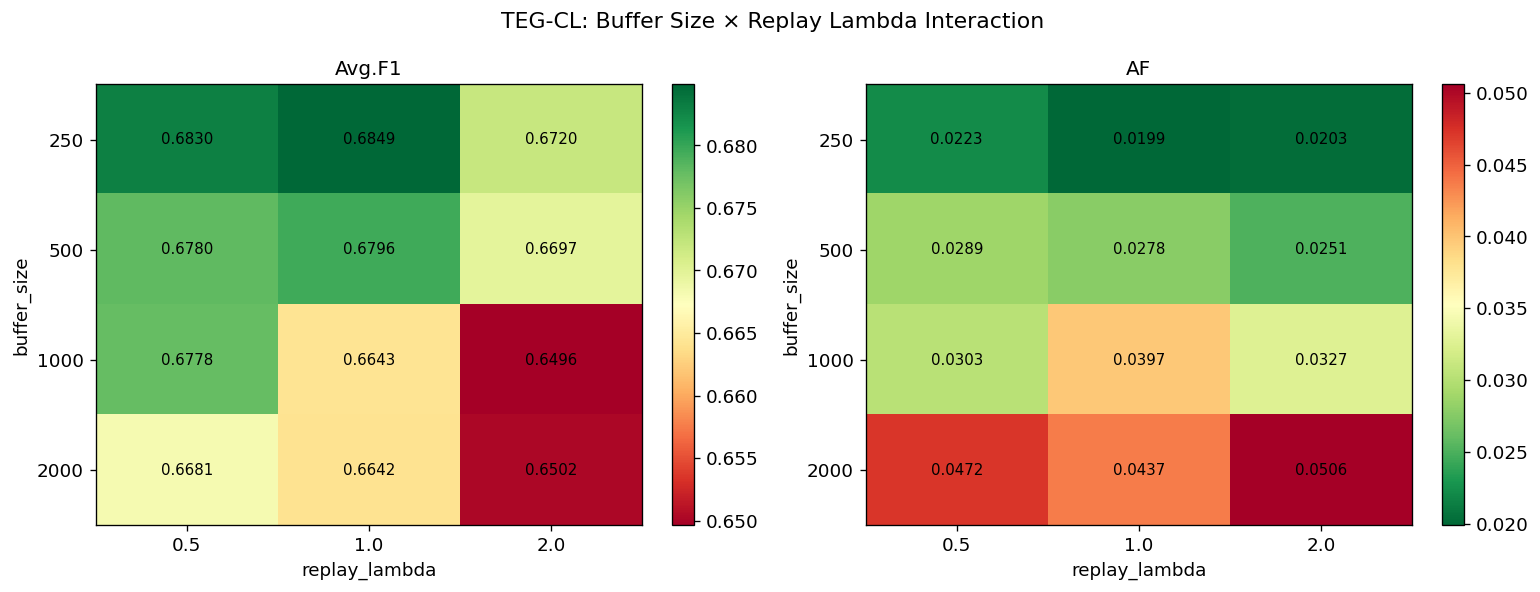

 /root/teg-cl-v3.5.10k/results/fig8_ablation_2d_grid.png


,0.5,1.0,2.0
250,0.683023,0.684877,0.672021
500,0.677996,0.679557,0.669690
1000,0.677821,0.664316,0.649617
2000,0.668105,0.664189,0.650227


,0.5,1.0,2.0
250,0.022258,0.019878,0.020308
500,0.028874,0.027786,0.025057
1000,0.030265,0.039714,0.032660
2000,0.047212,0.043684,0.050587


 /root/teg-cl-v3.5.10k/results/ablation_2d_grid.json
21b - PR Curves (final task test set)

  Bare
[TRAINER] AMP=True  epochs=50  batch=4096
[RESUME] No checkpoint - starting fresh
Strategy: Bare  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
  ep  0 | train=0.2165 val_loss=0.1211 train_f1=0.4947 val_f1=0.4963
 /root/teg-cl-v3.5.10k/checkpoints/pr_BareStrategy_42/task0_ep0_1787592887.pt
  ep 10 | train=0.0491 val_loss=0.0320 train_f1=0.8182 val_f1=0.8108
  ep 20 | train=0.0171 val_loss=0.0239 train_f1=0.9402 val_f1=0.8729
  Early stop @ ep 30
  eval T0: f1=0.7867  auc_pr=0.7007  mcc=0.5759
Task 1/6  train=3740  val=534  test=1069
  ep  0 | train=0.2319 val_loss=0.1727 train_f1=0.7768 val_f1=0.7409
  ep 10 | train=0.1086 val_loss=0.0826 train_f1=0.8285 val_f1=0.8067
  ep 20 | train=0.0932 val_loss=0.0681 train_f1=0.8611 val_f1=0.8400
  ep 30 | train=0.0827 val_loss=0.0645 train_f1=0.8681 val_f1=0.8515
  ep 40 | train=0.0816 val_loss=0.0621 train_f1=0.8805 val_f1=0.8

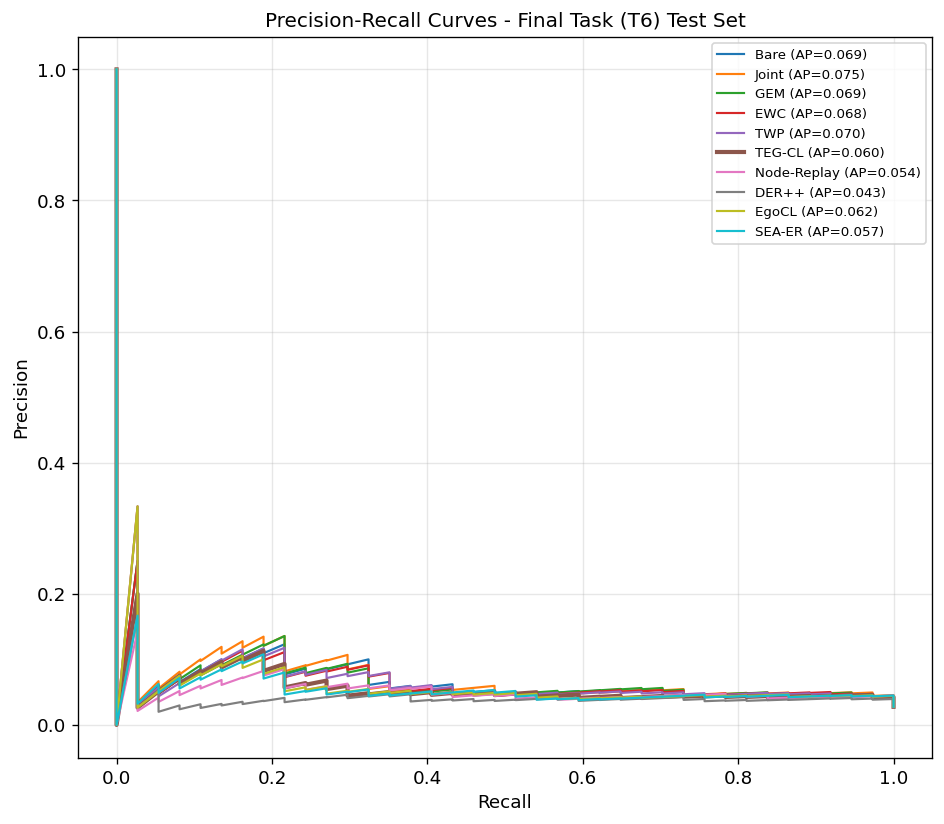

 /root/teg-cl-v3.5.10k/results/fig9_pr_curves.png


,Method,Average Precision
0,Bare,0.0691
1,Joint,0.0748
2,GEM,0.0686
3,EWC,0.0680
4,TWP,0.0700
5,TEG-CL,0.0595
6,Node-Replay,0.0538
7,DER++,0.0432
8,EgoCL,0.0619
9,SEA-ER,0.0565


21c - TEG-CL Loss Decomposition + Buffer Composition
[TRAINER] AMP=True  epochs=50  batch=4096
[RESUME] No checkpoint - starting fresh
Strategy: TEG-CL  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
  ep  0 | train=0.2165 val_loss=0.1211 train_f1=0.4947 val_f1=0.4963
 /root/teg-cl-v3.5.10k/checkpoints/loss_decomp/task0_ep0_1787594131.pt
  ep 10 | train=0.0491 val_loss=0.0320 train_f1=0.8182 val_f1=0.8108
  eval T0: f1=0.8045  auc_pr=0.7291  mcc=0.6131
  TEGR: buf=500 ill=13 sel=coverage
Task 1/6  train=3740  val=534  test=1069
  ep  0 | train=0.3248 val_loss=0.1551 train_f1=0.7678 val_f1=0.7501
  ep 10 | train=0.1243 val_loss=0.0765 train_f1=0.8726 val_f1=0.8451
  eval T0: f1=0.7452  auc_pr=0.7149  mcc=0.5222
  eval T1: f1=0.8538  auc_pr=0.9323  mcc=0.7373
  TEGR: buf=500 ill=18 sel=coverage
Task 2/6  train=3243  val=463  test=928
  ep  0 | train=0.3459 val_loss=0.1311 train_f1=0.8230 val_f1=0.8283
  ep 10 | train=0.2179 val_loss=0.1011 train_f1=0.8175 val_f1=0.824

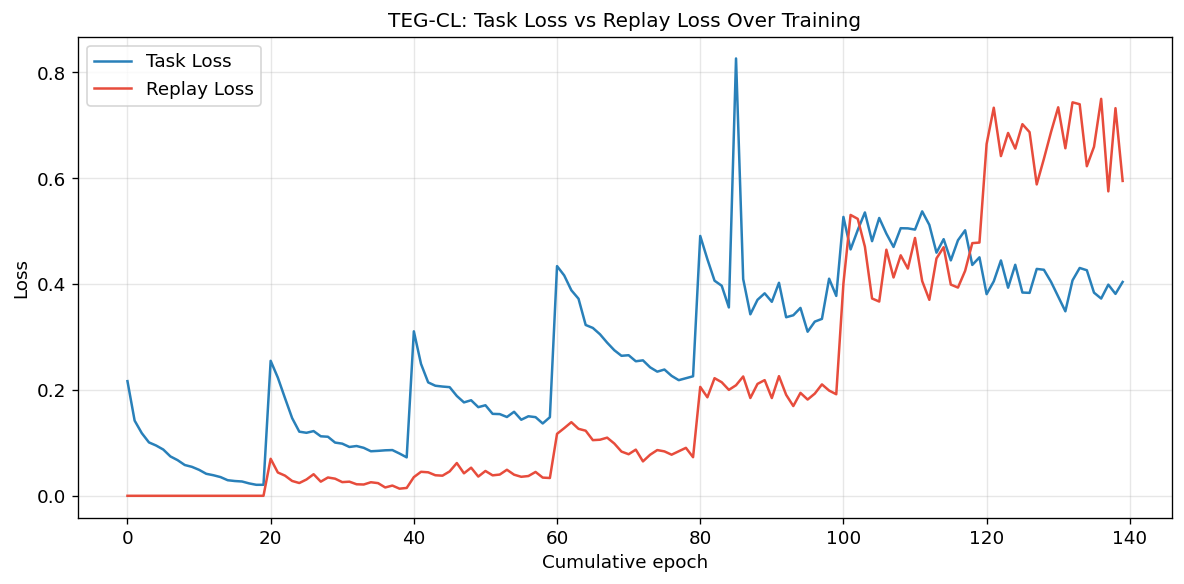

 /root/teg-cl-v3.5.10k/results/fig10_loss_decomposition.png


,Epoch,Task Loss,Replay Loss
0,0,0.216523,0.000000
1,1,0.142024,0.000000
2,2,0.118340,0.000000
3,3,0.100855,0.000000
4,4,0.094975,0.000000
...,...,...,...
135,135,0.383704,0.659156
136,136,0.372575,0.749759
137,137,0.398812,0.574998
138,138,0.381378,0.732141


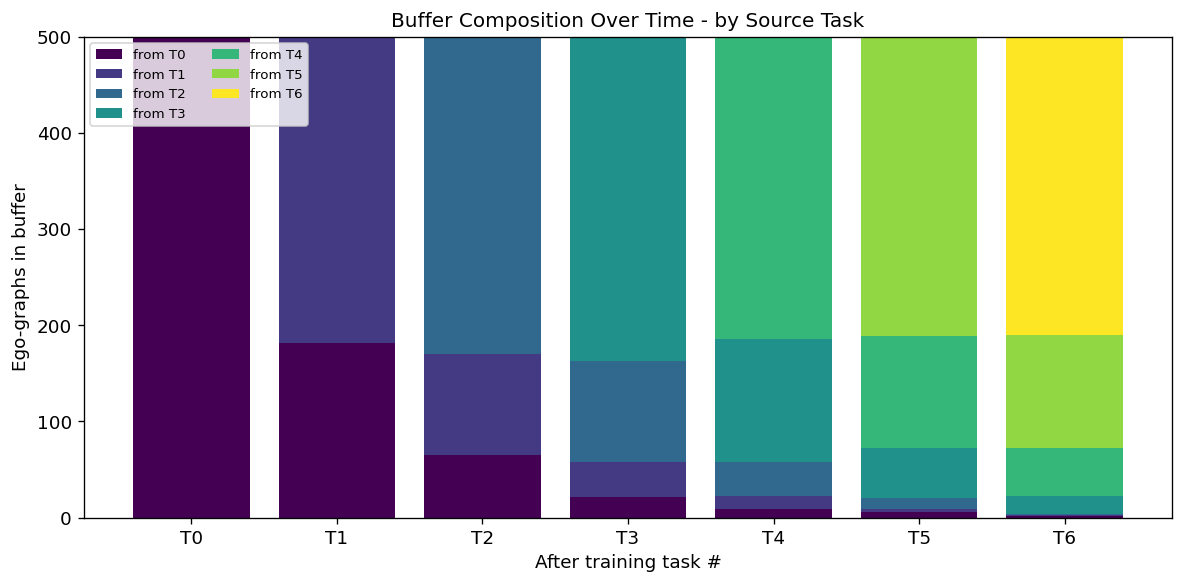

 /root/teg-cl-v3.5.10k/results/fig11_buffer_composition.png


,from T0,from T1,from T2,from T3,from T4,from T5,from T6
After T0,500.0,0.0,0.0,0.0,0.0,0.0,0.0
After T1,182.0,318.0,0.0,0.0,0.0,0.0,0.0
After T2,65.0,105.0,330.0,0.0,0.0,0.0,0.0
After T3,21.0,37.0,105.0,337.0,0.0,0.0,0.0
After T4,9.0,14.0,35.0,128.0,314.0,0.0,0.0
After T5,6.0,3.0,11.0,52.0,117.0,311.0,0.0
After T6,2.0,1.0,1.0,18.0,50.0,118.0,310.0



  Cell 29 complete




In [ ]:
# @title Cell 29: Instrumented Diagnostics
import copy, json, os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

_res = CONFIG['logging']['results_dir']
# RUN_2D_GRID / RUN_PR_CURVES / RUN_LOSS_DECOMP
RUN_21A = RUN_2D_GRID
RUN_21B = RUN_PR_CURVES
RUN_21C = RUN_LOSS_DECOMP

# 21a: true 2D grid over buffer size and replay lambda together.
if RUN_21A:
    print('21a - Buffer × Lambda 2D Grid')

    _buffers = [250, 500, 1000, 2000]
    _lambdas = [0.5, 1.0, 2.0]
    _grid_f1 = np.full((len(_buffers), len(_lambdas)), np.nan)
    _grid_af = np.full((len(_buffers), len(_lambdas)), np.nan)

    for bi, buf in enumerate(_buffers):
        for li, lam in enumerate(_lambdas):
            print(f'\n  buffer={buf} lambda={lam}')
            cfg = copy.deepcopy(CONFIG)
            cfg['continual']['tegr']['replay_buffer_size'] = buf
            cfg['continual']['tegr']['replay_lambda']      = lam
            cfg['continual']['tegr']['replay_batch_size']  = min(128, buf // 4)
            try:
                r = run_method(TEGRStrategy, task_data_list, cfg, DEVICE,
                               seed=42,
                               ckpt_dir=f"{CONFIG['logging']['checkpoint_dir']}/grid_{buf}_{lam}")
                _grid_f1[bi, li] = r.get('avg_f1', np.nan)
                _grid_af[bi, li] = r.get('af',     np.nan)
            except Exception as ex:
                print(f'  [ERROR] {ex}')

    fig21a, (axf, axa) = plt.subplots(1, 2, figsize=(13, 5))
    for ax, grid, title, cmap in [(axf, _grid_f1, 'Avg.F1', 'RdYlGn'),
                                   (axa, _grid_af, 'AF', 'RdYlGn_r')]:
        im = ax.imshow(grid, cmap=cmap, aspect='auto')
        ax.set_xticks(range(len(_lambdas))); ax.set_xticklabels(_lambdas)
        ax.set_yticks(range(len(_buffers))); ax.set_yticklabels(_buffers)
        ax.set_xlabel('replay_lambda'); ax.set_ylabel('buffer_size')
        ax.set_title(title)
        for i in range(len(_buffers)):
            for j in range(len(_lambdas)):
                if not np.isnan(grid[i,j]):
                    ax.text(j, i, f'{grid[i,j]:.4f}', ha='center', va='center', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig21a.suptitle('TEG-CL: Buffer Size × Replay Lambda Interaction')
    plt.tight_layout()
    _p21a = f'{_res}/fig8_ablation_2d_grid.png'
    fig21a.savefig(_p21a, dpi=300, bbox_inches='tight')
    plt.show(); print(f' {_p21a}')

    import pandas as pd
    from IPython.display import display
    display(pd.DataFrame(_grid_f1, index=_buffers, columns=_lambdas))
    display(pd.DataFrame(_grid_af, index=_buffers, columns=_lambdas))

    with open(f'{_res}/ablation_2d_grid.json', 'w') as f:
        json.dump({'buffers': _buffers, 'lambdas': _lambdas,
                   'avg_f1': _grid_f1.tolist(), 'af': _grid_af.tolist()}, f, indent=2)
    print(f' {_res}/ablation_2d_grid.json')

# 21b - Precision-Recall Curves, all 9 methods, final task test set
if RUN_21B:
    print('21b - PR Curves (final task test set)')

    # Trains a method and also returns its raw (y_true, y_prob) on the final task's test set.
    def run_method_with_probs(StratClass, task_data_list, config, device,
                              seed=42, **kw):
        set_seed(seed)
        model    = build_model(config).to(device)
        strategy = StratClass(**kw)
        trainer  = ContinualLearningTrainer(config, device)
        # Isolated checkpoint dir per method
        trainer.ckpt = CheckpointManager(
            save_dir=f"{config['logging']['checkpoint_dir']}/pr_{StratClass.__name__}_{seed}")
        trainer.setup(model, strategy)
        result = trainer.train(task_data_list)

        final_td = task_data_list[-1]
        loader = trainer._loader(final_td, 'test', shuffle=False)
        model.eval()
        probs, labels = [], []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                out   = model(batch.x, batch.edge_index).squeeze(-1)
                _bs   = batch.batch_size  # seed nodes only, per NeighborLoader's batching in ContinualLearningTrainer._eval_loader
                mask  = final_td['labeled_mask'][batch.n_id[:_bs]]
                if not mask.any(): continue
                probs.extend(torch.sigmoid(out[:_bs][mask]).cpu().numpy())
                labels.extend(batch.y[:_bs][mask].cpu().numpy())
        assert len(labels) == len(final_td['indices']['test']), (
            f"run_method_with_probs scored {len(labels)} nodes, test split has "
            f"{len(final_td['indices']['test'])} - seed-node masking regression")
        return result, np.array(labels), np.array(probs)

    # All 10 methods scored for the precision-recall comparison.
    _PR_METHODS = [
        ('Bare',        BareStrategy,        {}),
        ('Joint',       JointStrategy,       {}),
        ('GEM',         GEMStrategy,         {}),
        ('EWC',         EWCStrategy,         {}),
        ('TWP',         TWPStrategy,         {}),
        ('TEG-CL',      TEGRStrategy,        {}),
        ('Node-Replay', NodeReplayStrategy,  {}),
        ('DER++',       DERPPStrategy,       {}),
        ('EgoCL',       EgoCLStrategy,       {}),
        ('SEA-ER',      SEAERStrategy,       {}),
    ]

    _pr_data = {}
    for name, SC, kw in _PR_METHODS:
        print(f'\n  {name}')
        try:
            _, y_true, y_prob = run_method_with_probs(
                SC, task_data_list, CONFIG, DEVICE, seed=42, **kw)
            _pr_data[name] = (y_true, y_prob)
        except Exception as ex:
            print(f'  [ERROR] {ex}')

    # Plots a precision-recall curve for every method on the same axes.
    fig21b, ax21b = plt.subplots(figsize=(8, 7))
    for name, (y_true, y_prob) in _pr_data.items():
        if len(np.unique(y_true)) < 2: continue
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        lw = 2.5 if name == 'TEG-CL' else 1.3
        ax21b.plot(rec, prec, label=f'{name} (AP={ap:.3f})', linewidth=lw)
    ax21b.set_xlabel('Recall'); ax21b.set_ylabel('Precision')
    ax21b.set_title('Precision-Recall Curves - Final Task (T6) Test Set')
    ax21b.legend(loc='upper right', fontsize=8)
    ax21b.grid(alpha=0.3)
    plt.tight_layout()
    _p21b = f'{_res}/fig9_pr_curves.png'
    fig21b.savefig(_p21b, dpi=300, bbox_inches='tight')
    plt.show(); print(f' {_p21b}')

    import pandas as pd
    from IPython.display import display
    display(pd.DataFrame([
        {'Method': name, 'Average Precision': round(average_precision_score(y_t, y_p), 4)}
        for name, (y_t, y_p) in _pr_data.items() if len(np.unique(y_t)) >= 2
    ]))

# 21c - TEG-CL: task vs replay loss decomposition + buffer composition by source task, over time
if RUN_21C:
    print('21c - TEG-CL Loss Decomposition + Buffer Composition')

    # Logs per-epoch task/replay loss and buffer source-task composition after every task.
    class _InstrumentedTEGR(TEGRStrategy):

        # Sets up the loss and buffer-composition logs.
        def __init__(self, **kw):
            super().__init__(**kw)
            self.loss_log       = []   # (task_idx, epoch, task_loss, replay_loss)
            self.composition_log = []  # (after_task_idx, {source_task: count})
            self._epoch_counter  = 0

        # Trains one epoch like TEGRStrategy, but also logs task/replay loss per epoch.
        def train_epoch(self, **kw):
            model, loader, opt, crit = kw['model'], kw['train_loader'], kw['optimizer'], kw['criterion']
            device, lmask, ti        = kw['device'], kw['labeled_mask'], kw['task_idx']
            norm   = self.config['training']['max_grad_norm']
            scaler = kw.get('scaler'); amp = kw.get('use_amp', False)
            egos = self.buffer.sample(self.replay_batch) if (ti > 0 and len(self.buffer) > 0) else []

            model.train(); total = nb = 0
            task_loss_sum = replay_loss_sum = 0.0
            for batch in loader:
                batch = batch.to(device); opt.zero_grad()
                with _amp.autocast('cuda', enabled=amp):
                    out  = model(batch.x, batch.edge_index).squeeze(-1)
                    _bs  = batch.batch_size
                    mask = lmask[batch.n_id[:_bs]]
                    if not mask.any(): continue
                    tl = crit(out[:_bs][mask], batch.y[:_bs][mask].float())
                    rl = self._ego_loss(model, crit, device, egos)
                    loss = tl + self.replay_lambda * rl
                self._step(loss, opt, model, norm, scaler, amp)
                total += loss.item(); nb += 1
                task_loss_sum   += tl.item()
                replay_loss_sum += rl.item() if torch.is_tensor(rl) else rl
            if nb:
                self.loss_log.append((ti, self._epoch_counter,
                                      task_loss_sum/nb, replay_loss_sum/nb))
            self._epoch_counter += 1
            return total / nb if nb else 0.0

        # Runs the normal TEG-CL after_task, then logs the buffer's source-task composition.
        def after_task(self, td, ti):
            super().after_task(td, ti)
            comp = {}
            for e in self.buffer._buf:
                st = e.get('source_task', -1)
                comp[st] = comp.get(st, 0) + 1
            self.composition_log.append((ti, comp))

    set_seed(42)
    _model_c = build_model(CONFIG).to(DEVICE)
    _strat_c = _InstrumentedTEGR()
    _trainer_c = ContinualLearningTrainer(CONFIG, DEVICE)
    _trainer_c.ckpt = CheckpointManager(
        save_dir=f"{CONFIG['logging']['checkpoint_dir']}/loss_decomp")
    _trainer_c.setup(_model_c, _strat_c)
    _trainer_c.epochs = min(_trainer_c.epochs, 20)   # shorter - diagnostic only
    _result_c = _trainer_c.train(task_data_list)

    # Plot loss decomposition
    if _strat_c.loss_log:
        _epochs_l  = [x[1] for x in _strat_c.loss_log]
        _task_l    = [x[2] for x in _strat_c.loss_log]
        _replay_l  = [x[3] for x in _strat_c.loss_log]
        fig21c, ax21c = plt.subplots(figsize=(10, 5))
        ax21c.plot(_epochs_l, _task_l,   label='Task Loss',   color='#2980b9')
        ax21c.plot(_epochs_l, _replay_l, label='Replay Loss', color='#e74c3c')
        ax21c.set_xlabel('Cumulative epoch'); ax21c.set_ylabel('Loss')
        ax21c.set_title('TEG-CL: Task Loss vs Replay Loss Over Training')
        ax21c.legend(); ax21c.grid(alpha=0.3)
        plt.tight_layout()
        _p21c = f'{_res}/fig10_loss_decomposition.png'
        fig21c.savefig(_p21c, dpi=300, bbox_inches='tight')
        plt.show(); print(f' {_p21c}')

        import pandas as pd
        from IPython.display import display
        display(pd.DataFrame({'Epoch': _epochs_l, 'Task Loss': _task_l, 'Replay Loss': _replay_l}))

    # Plot buffer composition over time
    if _strat_c.composition_log:
        T_max = 7
        comp_grid = np.zeros((len(_strat_c.composition_log), T_max))
        for row, (ti, comp) in enumerate(_strat_c.composition_log):
            for src, cnt in comp.items():
                if 0 <= src < T_max:
                    comp_grid[row, src] = cnt

        fig21d, ax21d = plt.subplots(figsize=(10, 5))
        bottom = np.zeros(len(_strat_c.composition_log))
        cmap   = plt.cm.viridis(np.linspace(0, 1, T_max))
        for src in range(T_max):
            vals = comp_grid[:, src]
            if vals.sum() == 0: continue
            ax21d.bar(range(len(_strat_c.composition_log)), vals,
                     bottom=bottom, label=f'from T{src}', color=cmap[src])
            bottom += vals
        ax21d.set_xlabel('After training task #')
        ax21d.set_xticks(range(len(_strat_c.composition_log)))
        ax21d.set_xticklabels([f'T{x[0]}' for x in _strat_c.composition_log])
        ax21d.set_ylabel('Ego-graphs in buffer')
        ax21d.set_title('Buffer Composition Over Time - by Source Task')
        ax21d.legend(loc='upper left', fontsize=8, ncol=2)
        plt.tight_layout()
        _p21d = f'{_res}/fig11_buffer_composition.png'
        fig21d.savefig(_p21d, dpi=300, bbox_inches='tight')
        plt.show(); print(f' {_p21d}')

        import pandas as pd
        from IPython.display import display
        display(pd.DataFrame(comp_grid,
                             index=[f'After T{x[0]}' for x in _strat_c.composition_log],
                             columns=[f'from T{s}' for s in range(T_max)]))

print('\n  Cell 29 complete')
print('\n')


  Reusing _pr_data from Cell 21 (10 methods, no retraining)


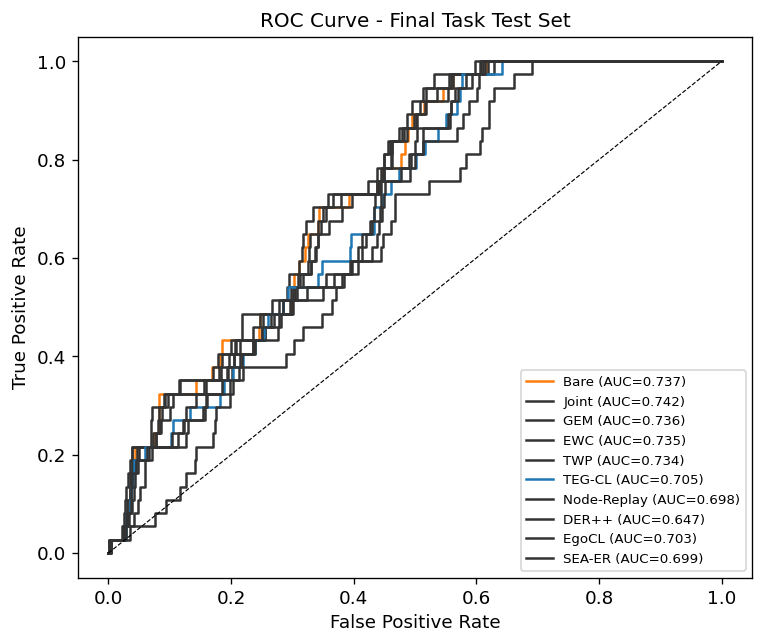

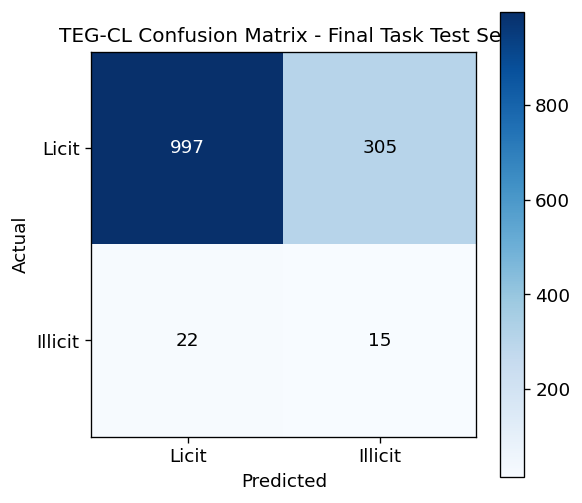

  Saved -> /root/teg-cl-v3.5.10k/results/fig12_roc_curve.png
  Saved -> /root/teg-cl-v3.5.10k/results/fig13_confusion_matrix.png
  (Precision-Recall curve already covered by Cell 21 -> fig9_pr_curves.png)


,Method,AUC
0,Bare,0.7366
1,Joint,0.7416
2,GEM,0.7360
3,EWC,0.7355
4,TWP,0.7335
5,TEG-CL,0.7046
6,Node-Replay,0.6982
7,DER++,0.6474
8,EgoCL,0.7030
9,SEA-ER,0.6993


,Pred: Licit,Pred: Illicit
Actual: Licit,997,305
Actual: Illicit,22,15


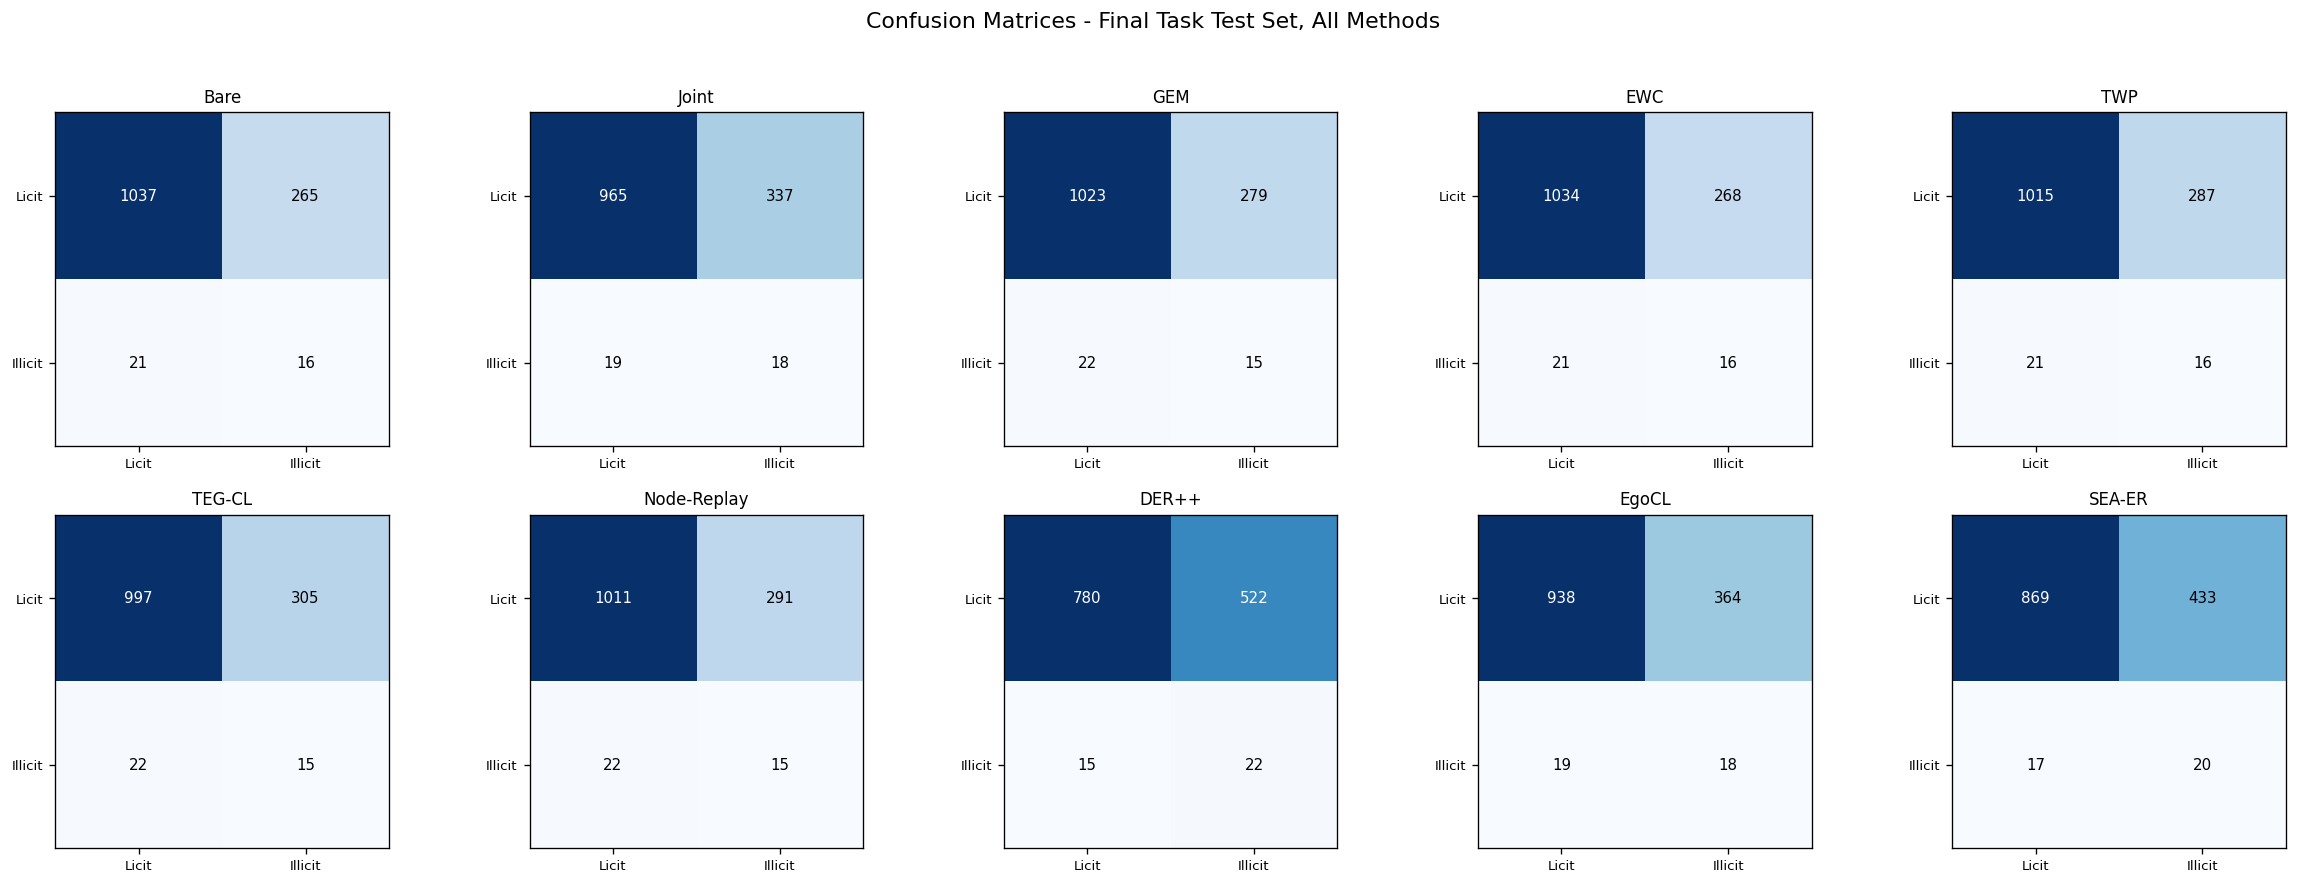

 /root/teg-cl-v3.5.10k/results/fig15_confusion_matrices_all_methods.png


,Method,TN,FP,FN,TP,Predicted Illicit Rate,Actual Illicit Rate
7,DER++,780,522,15,22,0.4063,0.0276
9,SEA-ER,869,433,17,20,0.3383,0.0276
8,EgoCL,938,364,19,18,0.2853,0.0276
1,Joint,965,337,19,18,0.2651,0.0276
5,TEG-CL,997,305,22,15,0.2390,0.0276
6,Node-Replay,1011,291,22,15,0.2285,0.0276
4,TWP,1015,287,21,16,0.2263,0.0276
2,GEM,1023,279,22,15,0.2196,0.0276
3,EWC,1034,268,21,16,0.2121,0.0276
0,Bare,1037,265,21,16,0.2099,0.0276


In [ ]:
# @title Cell 30: Publication Figures - ROC and Confusion Matrix (reuses Cell 21's _pr_data)
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


if '_pr_data' in globals() and _pr_data:
    print(f'  Reusing _pr_data from Cell 21 ({len(_pr_data)} methods, no retraining)')
    _preds = _pr_data
else:
    print('  _pr_data not in scope (Cell 21 / RUN_21B not run) - retraining TEG-CL and Bare only')

    if 'run_method_with_probs' not in globals():
        def run_method_with_probs(StratClass, task_data_list, config, device, seed=42, **kw):
            set_seed(seed)
            model    = build_model(config).to(device)
            strategy = StratClass(**kw)
            trainer  = ContinualLearningTrainer(config, device)
            trainer.ckpt = CheckpointManager(
                save_dir=f"{config['logging']['checkpoint_dir']}/pubfig_{StratClass.__name__}_{seed}")
            trainer.setup(model, strategy)
            result = trainer.train(task_data_list)
            final_td = task_data_list[-1]
            loader = trainer._loader(final_td, 'test', shuffle=False)
            model.eval()
            probs, labels = [], []
            with torch.no_grad():
                for batch in loader:
                    batch = batch.to(device)
                    out   = model(batch.x, batch.edge_index).squeeze(-1)
                    _bs   = batch.batch_size  # seed nodes only - see Cell 10's _eval_loader docstring
                    mask  = final_td['labeled_mask'][batch.n_id[:_bs]]
                    if not mask.any(): continue
                    probs.extend(torch.sigmoid(out[:_bs][mask]).cpu().numpy())
                    labels.extend(batch.y[:_bs][mask].cpu().numpy())
            assert len(labels) == len(final_td['indices']['test']), (
                f"run_method_with_probs scored {len(labels)} nodes, test split has "
                f"{len(final_td['indices']['test'])} - seed-node masking regression")
            return result, np.array(labels), np.array(probs)

    _preds = {}
    for name, SC in [('TEG-CL', TEGRStrategy), ('Bare', BareStrategy)]:
        _, y_true, y_prob = run_method_with_probs(SC, task_data_list, CONFIG, DEVICE, seed=42)
        _preds[name] = (y_true, y_prob)

# FIG: ROC curve - the piece Cell 21 doesn't already produce
fig, ax1 = plt.subplots(figsize=(6.5, 5.5))
_colors = {'TEG-CL': '#1f77b4', 'Bare': '#ff7f0e'}
for name, (y_true, y_prob) in _preds.items():
    if len(np.unique(y_true)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})',
             color=_colors.get(name, '#333333'), linewidth=1.5)
ax1.plot([0, 1], [0, 1], 'k--', linewidth=0.7)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve - Final Task Test Set'); ax1.legend(fontsize=8)
plt.tight_layout()
_p1 = f"{CONFIG['logging']['results_dir']}/fig12_roc_curve.png"
fig.savefig(_p1, dpi=300, bbox_inches='tight')
plt.show()

# FIG: Confusion matrix for TEG-CL
y_true, y_prob = _preds['TEG-CL']
cm = confusion_matrix(y_true, (y_prob > 0.5).astype(int))
fig2, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Licit', 'Illicit'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Licit', 'Illicit'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('TEG-CL Confusion Matrix - Final Task Test Set')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
_p2 = f"{CONFIG['logging']['results_dir']}/fig13_confusion_matrix.png"
fig2.savefig(_p2, dpi=300, bbox_inches='tight')
plt.show()

print(f'  Saved -> {_p1}\n  Saved -> {_p2}')
print('  (Precision-Recall curve already covered by Cell 21 -> fig9_pr_curves.png)')

import pandas as pd
from IPython.display import display
display(pd.DataFrame([
    {'Method': name, 'AUC': round(auc(*roc_curve(y_t, y_p)[:2]), 4)}
    for name, (y_t, y_p) in _preds.items() if len(np.unique(y_t)) >= 2
]))
display(pd.DataFrame(cm, index=['Actual: Licit','Actual: Illicit'],
                     columns=['Pred: Licit','Pred: Illicit']))

# FIG: confusion matrix small multiples for all 10 methods
_cm_rows = []
_n_methods = len(_preds)
_ncols = 5
_nrows = -(-_n_methods // _ncols)
fig3, axes = plt.subplots(_nrows, _ncols, figsize=(4*_ncols, 3.6*_nrows))
axes = np.atleast_1d(axes).flatten()
for _ax_i, (name, (y_t, y_p)) in enumerate(_preds.items()):
    _cm_i = confusion_matrix(y_t, (y_p > 0.5).astype(int), labels=[0, 1])
    _tn, _fp, _fn, _tp = _cm_i.ravel()
    _n_total = _tn + _fp + _fn + _tp
    _cm_rows.append({
        'Method': name, 'TN': int(_tn), 'FP': int(_fp), 'FN': int(_fn), 'TP': int(_tp),
        'Predicted Illicit Rate': round((_fp + _tp) / _n_total, 4) if _n_total else float('nan'),
        'Actual Illicit Rate': round((_fn + _tp) / _n_total, 4) if _n_total else float('nan'),
    })
    _ax = axes[_ax_i]
    _im = _ax.imshow(_cm_i, cmap='Blues')
    _ax.set_xticks([0, 1]); _ax.set_xticklabels(['Licit', 'Illicit'], fontsize=8)
    _ax.set_yticks([0, 1]); _ax.set_yticklabels(['Licit', 'Illicit'], fontsize=8)
    _ax.set_title(name, fontsize=10)
    for _i in range(2):
        for _j in range(2):
            _ax.text(_j, _i, _cm_i[_i, _j], ha='center', va='center', fontsize=9,
                     color='white' if _cm_i[_i, _j] > _cm_i.max() / 2 else 'black')
for _ax_i in range(_n_methods, len(axes)):
    axes[_ax_i].axis('off')
plt.suptitle('Confusion Matrices - Final Task Test Set, All Methods', y=1.02)
plt.tight_layout()
_p3 = f"{CONFIG['logging']['results_dir']}/fig15_confusion_matrices_all_methods.png"
fig3.savefig(_p3, dpi=300, bbox_inches='tight')
plt.show()
print(f' {_p3}')
display(pd.DataFrame(_cm_rows).sort_values('Predicted Illicit Rate', ascending=False))
print('\n')


[TASK T6] Nodes: 29,684 | Edges: 16,829 | Labeled: 6,687


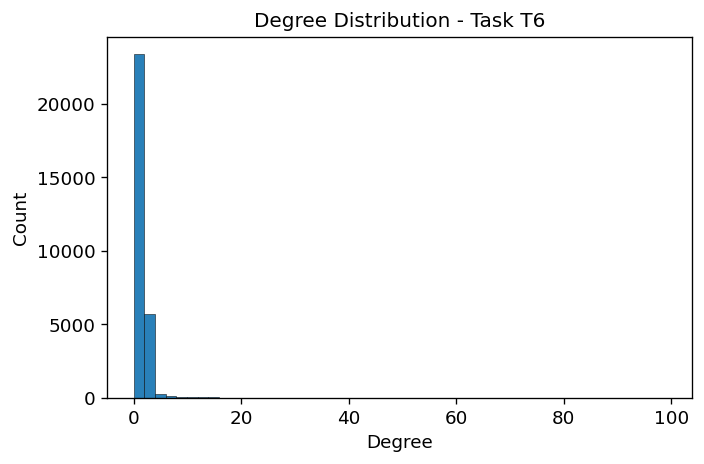

 /root/teg-cl-v3.5.10k/results/fig16_degree_distribution.png


,Min,Max,Mean,Median
0,0,99,1.134,1.0


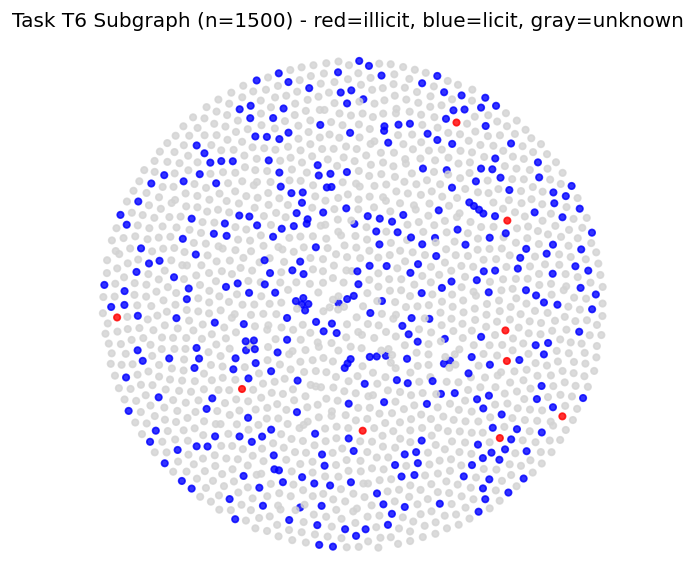

 /root/teg-cl-v3.5.10k/results/fig17_subgraph_visualization.png

Sampled subgraph class balance: illicit=9 (0.6%) | licit=333 (22.2%) | unknown=1158 (77.2%)


,Nodes,Edges,Labeled,Sampled illicit,Sampled licit,Sampled unknown
0,29684,16829,6687,9,333,1158



  Cell 32 complete




In [ ]:
# @title Cell 31: NetworkX Subgraph Visualization

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

_res = CONFIG['logging']['results_dir']

try:
    _ = task_data_list; assert task_data_list
except (NameError, AssertionError):
    raise RuntimeError('task_data_list not in scope - run Batch 1 Cells 1-6 first')

# Picks a task to visualize (default: most recent, most laundering activity).
VIZ_TASK_IDX  = min(6, len(task_data_list) - 1)   # T6 if available, else last task
MAX_NODES_VIS = 1500       # cap for layout speed

# Selects the chosen task (final task under a full run, richest illicit activity).
td   = task_data_list[VIZ_TASK_IDX]
data = td['data']

num_nodes   = data.num_nodes
num_edges   = data.edge_index.size(1) // 2
num_labeled = int(td['labeled_mask'].sum())
print(f'[TASK T{VIZ_TASK_IDX}] Nodes: {num_nodes:,} | Edges: {num_edges:,} | '
      f'Labeled: {num_labeled:,}')

# FIG 12: degree distribution histogram.
deg = torch.bincount(data.edge_index[0], minlength=num_nodes).cpu().numpy()
fig_deg, ax_deg = plt.subplots(figsize=(6, 4))
ax_deg.hist(deg, bins=50, color='#2980b9', edgecolor='black', linewidth=0.3)
ax_deg.set_xlabel('Degree'); ax_deg.set_ylabel('Count')
ax_deg.set_title(f'Degree Distribution - Task T{VIZ_TASK_IDX}')
plt.tight_layout()
_p_deg = f'{_res}/fig16_degree_distribution.png'
fig_deg.savefig(_p_deg, dpi=300, bbox_inches='tight')
plt.show(); print(f' {_p_deg}')

import pandas as pd
from IPython.display import display
display(pd.DataFrame([{'Min': int(deg.min()), 'Max': int(deg.max()),
                       'Mean': round(float(deg.mean()),3),
                       'Median': float(np.median(deg))}]))

# Sampled subgraph visualization
# Samples up to MAX_NODES_VIS nodes for the subgraph visualization.
candidate_nodes = np.arange(num_nodes)
if candidate_nodes.size > MAX_NODES_VIS:
    rng = np.random.default_rng(123)
    candidate_nodes = rng.choice(candidate_nodes, size=MAX_NODES_VIS, replace=False)

node_set = set(candidate_nodes.tolist())
src = data.edge_index[0].cpu().numpy()
dst = data.edge_index[1].cpu().numpy()
mask_edges = np.isin(src, candidate_nodes) & np.isin(dst, candidate_nodes)
src_s, dst_s = src[mask_edges], dst[mask_edges]

# Builds the sampled subgraph and colors nodes by class.
G = nx.Graph()
G.add_nodes_from(candidate_nodes.tolist())
G.add_edges_from(zip(src_s.tolist(), dst_s.tolist()))

y_np = data.y.cpu().numpy()
color_map = []
for n in G.nodes():
    if y_np[n] == 1:   color_map.append('red')      # illicit
    elif y_np[n] == 0: color_map.append('blue')     # licit
    else:               color_map.append('lightgray')  # unknown

# FIG 13: renders the sampled subgraph with a spring layout.
fig_g, ax_g = plt.subplots(figsize=(5, 5))
pos = nx.spring_layout(G, seed=123, k=0.15)
nx.draw_networkx_nodes(G, pos, node_size=15, node_color=color_map, alpha=0.8, ax=ax_g)
nx.draw_networkx_edges(G, pos, width=0.2, alpha=0.3, ax=ax_g)
ax_g.set_title(f'Task T{VIZ_TASK_IDX} Subgraph (n={len(candidate_nodes)}) - '
              f'red=illicit, blue=licit, gray=unknown')
ax_g.axis('off')
plt.tight_layout()
_p_sub = f'{_res}/fig17_subgraph_visualization.png'
fig_g.savefig(_p_sub, dpi=300, bbox_inches='tight')
plt.show(); print(f' {_p_sub}')

# Class balance readout: Reports the class balance of the sampled subgraph.
n_ill = int((y_np[list(node_set)] == 1).sum())
n_lic = int((y_np[list(node_set)] == 0).sum())
n_unk = len(node_set) - n_ill - n_lic
print(f'\nSampled subgraph class balance: '
      f'illicit={n_ill} ({n_ill/len(node_set)*100:.1f}%) | '
      f'licit={n_lic} ({n_lic/len(node_set)*100:.1f}%) | '
      f'unknown={n_unk} ({n_unk/len(node_set)*100:.1f}%)')

display(pd.DataFrame([{'Nodes': num_nodes, 'Edges': num_edges, 'Labeled': num_labeled,
                       'Sampled illicit': n_ill, 'Sampled licit': n_lic,
                       'Sampled unknown': n_unk}]))

print('\n  Cell 32 complete')
print('\n')


In [ ]:
# @title Cell 32: Hits@K / P@K Investigator-Workload Metrics

import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score

_res = CONFIG['logging']['results_dir']

# Computes best F1, PR-AUC, and Hits@K/Precision@K/Recall@K for the illicit class under extreme imbalance.
def evaluate_illicit_metrics(y_true: np.ndarray, y_score: np.ndarray,
                              k: int = 50) -> dict:
    if len(y_true) == 0 or y_true.sum() == 0:
        return {'best_f1': 0.0, 'best_thr': 0.5, 'pr_auc': 0.0,
                'hits@k': 0, 'precision@k': 0.0, 'recall@k': 0.0}

    precision, recall, thr = precision_recall_curve(y_true, y_score, pos_label=1)
    pr_auc = float(average_precision_score(y_true, y_score))
    f1s = (2 * precision * recall) / (precision + recall + 1e-9)
    best_idx = int(np.nanargmax(f1s))
    best_f1  = float(f1s[best_idx])
    best_thr = float(thr[max(best_idx - 1, 0)]) if thr.size else 0.5

    idx_sorted = np.argsort(-y_score)
    topk = idx_sorted[:min(k, len(idx_sorted))]
    hits_at_k   = int(y_true[topk].sum())
    prec_at_k   = float(y_true[topk].sum() / max(1, len(topk)))
    recall_at_k = float(y_true[topk].sum() / max(1, y_true.sum()))

    return {'best_f1': best_f1, 'best_thr': best_thr, 'pr_auc': pr_auc,
            'hits@k': hits_at_k, 'precision@k': prec_at_k,
            'recall@k': recall_at_k}

# Collects (y_true, y_prob) for the illicit class over a loader; expected_n is an optional tripwire for the seed-node masking regression checked in ContinualLearningTrainer._eval_loader.
@torch.no_grad()
def get_probs_labels(model, loader, labeled_mask, device, expected_n: int = None) -> tuple:
    model.eval()
    probs, labels = [], []
    for batch in loader:
        batch = batch.to(device)
        out   = model(batch.x, batch.edge_index).squeeze(-1)
        _bs   = batch.batch_size
        mask  = labeled_mask[batch.n_id[:_bs]]
        if not mask.any(): continue
        probs.extend(torch.sigmoid(out[:_bs][mask]).cpu().numpy())
        labels.extend(batch.y[:_bs][mask].cpu().numpy())
    if expected_n is not None:
        assert len(labels) == expected_n, (
            f'get_probs_labels scored {len(labels)} nodes, split has {expected_n} - '
            f'seed-node masking regression')
    return np.array(labels), np.array(probs)

# Trains a method, then scores it with the Hits@K metrics above on the final task's test set.
def run_method_with_hitsk(StratClass, task_data_list, config, device,
                          seed=42, k=50, **kw) -> dict:
    set_seed(seed)
    model    = build_model(config).to(device)
    strategy = StratClass(**kw)
    trainer  = ContinualLearningTrainer(config, device)
    # Isolated checkpoint dir per method (without this every method in this loop shares the default checkpoint dir and can silently resume from whatever the previous method)
    trainer.ckpt = CheckpointManager(
        save_dir=f"{config['logging']['checkpoint_dir']}/hitsk_{StratClass.__name__}_{seed}")
    trainer.setup(model, strategy)
    result = trainer.train(task_data_list)

    final_td = task_data_list[-1]
    loader   = trainer._loader(final_td, 'test', shuffle=False)
    y_true, y_prob = get_probs_labels(model, loader, final_td['labeled_mask'], device,
                                     expected_n=len(final_td['indices']['test']))
    hitsk = evaluate_illicit_metrics(y_true, y_prob, k=k)
    return {**result, **{f'hitsk_{key}': v for key, v in hitsk.items()}}



# Run for all 10 methods (final task, K=50). Single seed=42 by default
K_VALUE   = 50

if RUN_HITSK:
    print(f'CELL 33 - Hits@{K_VALUE} / P@{K_VALUE} on Final Task (T6)')

    # All 10 methods evaluated at K=50 on the final task.
    _HITSK_METHODS = [
        ('Bare',        BareStrategy,        {}),
        ('Joint',       JointStrategy,       {}),
        ('GEM',         GEMStrategy,         {}),
        ('EWC',         EWCStrategy,         {}),
        ('TWP',         TWPStrategy,         {}),
        ('TEG-CL',      TEGRStrategy,        {}),
        ('Node-Replay', NodeReplayStrategy,  {}),
        ('DER++',       DERPPStrategy,       {}),
        ('EgoCL',       EgoCLStrategy,       {}),
        ('SEA-ER',      SEAERStrategy,       {}),
    ]

    _hitsk_seeds = (CONFIG['evaluation'].get('confirmatory_seeds', [1001,2002,3003,4004,5005])
                    if CONFIRMATORY_RUN else [42])

    hitsk_results = {}
    for name, SC, kw in _HITSK_METHODS:
        print(f'\n  {name}')
        per_seed = []
        for s in _hitsk_seeds:
            try:
                r = run_method_with_hitsk(SC, task_data_list, CONFIG, DEVICE,
                                          seed=s, k=K_VALUE, **kw)
                per_seed.append(r)
            except Exception as ex:
                print(f'  [ERROR] seed={s}: {ex}')
                per_seed.append({'hitsk_hits@k': 0, 'hitsk_precision@k': 0,
                                 'hitsk_recall@k': 0, 'hitsk_pr_auc': 0})
        if len(_hitsk_seeds) == 1:
            hitsk_results[name] = per_seed[0]
        else:
            hits_list = [p.get('hitsk_hits@k', 0) for p in per_seed]
            hitsk_results[name] = {
                'hitsk_hits@k':       float(np.mean(hits_list)),
                'hitsk_hits@k_std':   float(np.std(hits_list)),
                'hitsk_precision@k':  float(np.mean([p.get('hitsk_precision@k', 0) for p in per_seed])),
                'hitsk_recall@k':     float(np.mean([p.get('hitsk_recall@k', 0) for p in per_seed])),
                'hitsk_pr_auc':       float(np.mean([p.get('hitsk_pr_auc', 0) for p in per_seed])),
                'hitsk_per_seed_hits': hits_list,
            }

    print(f'\n{"Method":<14} {"Hits@50":>8} {"P@50":>7} {"R@50":>7} {"PR-AUC":>8}')
    for name, r in sorted(hitsk_results.items(),
                          key=lambda x: x[1].get('hitsk_hits@k', 0), reverse=True):
        print(f"{name:<14} {r.get('hitsk_hits@k',0):>8} "
              f"{r.get('hitsk_precision@k',0):>7.3f} "
              f"{r.get('hitsk_recall@k',0):>7.3f} "
              f"{r.get('hitsk_pr_auc',0):>8.4f}")

    import json
    with open(f'{_res}/hitsk_results.json', 'w') as f:
        json.dump({n: {k2: float(v2) if not isinstance(v2, (int,)) else v2
                       for k2, v2 in r.items() if k2.startswith('hitsk_')}
                  for n, r in hitsk_results.items()}, f, indent=2)
    print(f'\n {_res}/hitsk_results.json')

    import pandas as pd
    from IPython.display import display
    display(pd.DataFrame([
        {'Method': n, f'Hits@{K_VALUE}': r.get('hitsk_hits@k',0),
         f'P@{K_VALUE}': round(r.get('hitsk_precision@k',0),4),
         f'R@{K_VALUE}': round(r.get('hitsk_recall@k',0),4),
         'PR-AUC': round(r.get('hitsk_pr_auc',0),4)}
        for n, r in hitsk_results.items()
    ]))
else:
    print('RUN_HITSK=False - skipped. Set True to compute Hits@K.')

print('\n  Cell 32 complete')
print('\n')


CELL 33 - Hits@50 / P@50 on Final Task (T6)

  Bare
[TRAINER] AMP=True  epochs=50  batch=4096
[RESUME] No checkpoint - starting fresh
Strategy: Bare  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
  ep  0 | train=0.2165 val_loss=0.1211 train_f1=0.4947 val_f1=0.4963
 /root/teg-cl-v3.5.10k/checkpoints/hitsk_BareStrategy_42/task0_ep0_1787594226.pt
  ep 10 | train=0.0491 val_loss=0.0320 train_f1=0.8173 val_f1=0.8108
  ep 20 | train=0.0171 val_loss=0.0239 train_f1=0.9402 val_f1=0.8729
  ep 30 | train=0.0074 val_loss=0.0283 train_f1=0.9691 val_f1=0.8921
  Early stop @ ep 34
  eval T0: f1=0.8085  auc_pr=0.7292  mcc=0.6203
Task 1/6  train=3740  val=534  test=1069
  ep  0 | train=0.2656 val_loss=0.1585 train_f1=0.7810 val_f1=0.7570
  ep 10 | train=0.0990 val_loss=0.0785 train_f1=0.8298 val_f1=0.8182
  ep 20 | train=0.0860 val_loss=0.0654 train_f1=0.8676 val_f1=0.8476
  ep 30 | train=0.0795 val_loss=0.0629 train_f1=0.8736 val_f1=0.8502
  ep 40 | train=0.0779 val_loss=0.0596 t

,Method,Hits@50,P@50,R@50,PR-AUC
0,Bare,3,0.06,0.0811,0.0619
1,Joint,3,0.06,0.0811,0.0614
2,GEM,4,0.08,0.1081,0.0686
3,EWC,3,0.06,0.0811,0.0570
4,TWP,5,0.10,0.1351,0.0677
5,TEG-CL,3,0.06,0.0811,0.0583
6,Node-Replay,2,0.04,0.0541,0.0536
7,DER++,2,0.04,0.0541,0.0588
8,EgoCL,4,0.08,0.1081,0.0625
9,SEA-ER,3,0.06,0.0811,0.0570



  Cell 33 complete




CELL 34 - Train/Eval Timing, All 9 Methods

  Bare
[TRAINER] AMP=True  epochs=50  batch=4096
[RESUME] No checkpoint - starting fresh
Strategy: Bare  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
  ep  0 | train=0.2165 val_loss=0.1211 train_f1=0.4947 val_f1=0.4963
 /root/teg-cl-v3.5.10k/checkpoints/timing_BareStrategy_42/task0_ep0_1787595472.pt
  ep 10 | train=0.0490 val_loss=0.0320 train_f1=0.8164 val_f1=0.8108
  ep 20 | train=0.0170 val_loss=0.0239 train_f1=0.9402 val_f1=0.8729
  ep 30 | train=0.0075 val_loss=0.0280 train_f1=0.9707 val_f1=0.8921
  Early stop @ ep 34
  eval T0: f1=0.8126  auc_pr=0.7289  mcc=0.6278
Task 1/6  train=3740  val=534  test=1069
  ep  0 | train=0.2665 val_loss=0.1591 train_f1=0.7808 val_f1=0.7549
  ep 10 | train=0.0990 val_loss=0.0784 train_f1=0.8294 val_f1=0.8182
  ep 20 | train=0.0861 val_loss=0.0654 train_f1=0.8680 val_f1=0.8476
  ep 30 | train=0.0796 val_loss=0.0629 train_f1=0.8722 val_f1=0.8502
  ep 40 | train=0.0780 val_loss=0.0596 t

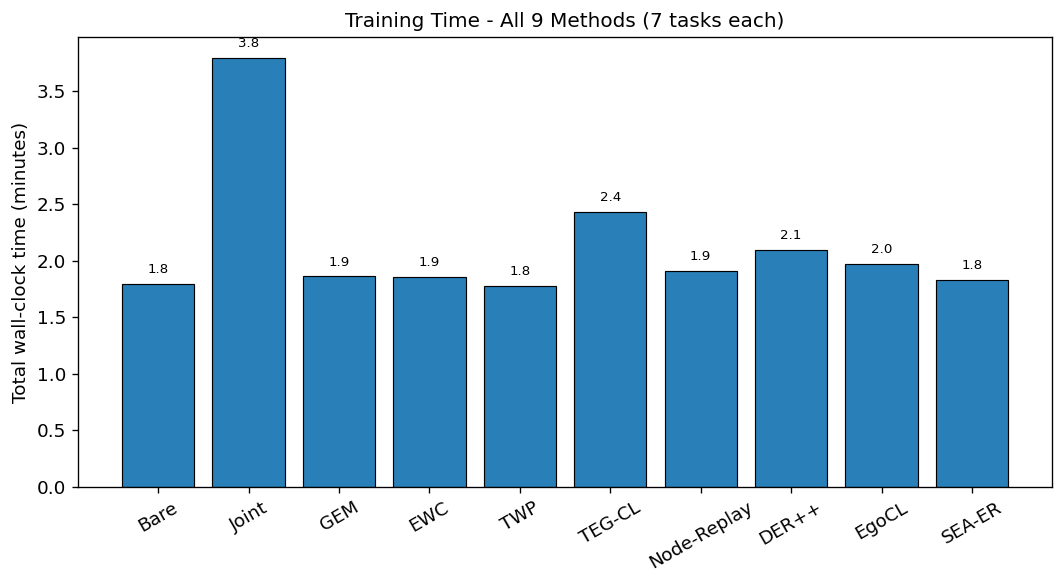

 /root/teg-cl-v3.5.10k/results/fig14_timing_comparison.png


,Method,Total (min),Eval (s),Peak GPU (MB),Buffer (MB)
0,Bare,1.79,14.3,514.0,0.00
1,Joint,3.79,14.3,1067.0,0.00
2,GEM,1.86,13.7,544.0,1.24
3,EWC,1.86,14.6,706.0,0.00
4,TWP,1.77,13.7,708.0,0.00
5,TEG-CL,2.43,14.8,633.0,3.96
6,Node-Replay,1.91,14.3,524.0,0.32
7,DER++,2.09,15.0,623.0,1.44
8,EgoCL,1.97,14.8,518.0,2.42
9,SEA-ER,1.83,13.4,626.0,2.66



  Cell 34 complete




In [ ]:
# @title Cell 33: Train / Validation / Test Timing Instrumentation

import time
import numpy as np

_res = CONFIG['logging']['results_dir']

# ContinualLearningTrainer with per-task train/val/test timing, plus peak GPU memory and replay-buffer memory tracking
class TimedTrainer(ContinualLearningTrainer):

    # Sets up the per-task timing log.
    def __init__(self, config, device):
        super().__init__(config, device)
        self.timing_log = []   # list of dicts, one per task

    # Estimate replay buffer storage in MB by summing tensor element counts across every known buffer attribute name.
    @staticmethod
    def _buffer_size_mb(strategy) -> float:

        total_bytes = 0
        for attr_name in ('buffer', '_rx', '_x', '_mems', '_buf'):
            obj = getattr(strategy, attr_name, None)
            if obj is None:
                continue
            container = getattr(obj, '_buf', obj)   # unwrap EgoBuffer
            if not isinstance(container, list):
                continue
            for item in container:
                if isinstance(item, torch.Tensor):
                    total_bytes += item.element_size() * item.nelement()
                elif isinstance(item, dict):
                    for v in item.values():
                        if isinstance(v, torch.Tensor):
                            total_bytes += v.element_size() * v.nelement()
                elif isinstance(item, tuple):
                    for v in item:
                        if isinstance(v, torch.Tensor):
                            total_bytes += v.element_size() * v.nelement()
        return total_bytes / (1024 ** 2)

    # Wraps evaluation calls to time them and tracks peak GPU memory for the whole run.
    def train(self, task_data_list: list) -> dict:
        T = len(task_data_list)

        _timing_this_run = {'train': [], 'val': [], 'test': []}
        original_eval_loader = self._eval_loader

        # Wraps _eval_loader to record its elapsed time for every call.
        def _timed_eval_loader(loader, lmask, expected_n=None):
            t0 = time.perf_counter()
            result = original_eval_loader(loader, lmask, expected_n=expected_n)
            elapsed = time.perf_counter() - t0
            _timing_this_run['test'].append(elapsed)
            return result

        self._eval_loader = _timed_eval_loader

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats(self.device)

        t_start = time.perf_counter()
        result = super().train(task_data_list)
        t_total = time.perf_counter() - t_start

        peak_mem_mb = (torch.cuda.max_memory_allocated(self.device) / (1024**2)
                      if torch.cuda.is_available() else 0.0)
        buf_mb = self._buffer_size_mb(self.strategy)

        self._eval_loader = original_eval_loader   # restore

        self.timing_log.append({
            'method':          self.strategy.name,
            'total_seconds':   t_total,
            'total_minutes':   t_total / 60,
            'eval_seconds':    sum(_timing_this_run['test']),
            'n_eval_calls':    len(_timing_this_run['test']),
            'peak_gpu_mb':     peak_mem_mb,
            'buffer_mb':       buf_mb,
            'avg_eval_sec':    (np.mean(_timing_this_run['test'])
                                if _timing_this_run['test'] else 0.0),
        })
        return result

# Same contract as run_method(), but also returns the timing dict.
def run_method_timed(StratClass, task_data_list, config, device,
                     seed=42, **kw) -> tuple:
    set_seed(seed)
    model    = build_model(config).to(device)
    strategy = StratClass(**kw)
    trainer  = TimedTrainer(config, device)
    # Isolated checkpoint dir per method (without this every method in this loop shares the default checkpoint dir, resumes from whatever ran before it, and reports artificially fast timing)
    trainer.ckpt = CheckpointManager(
        save_dir=f"{config['logging']['checkpoint_dir']}/timing_{StratClass.__name__}_{seed}")
    trainer.setup(model, strategy)
    result = trainer.train(task_data_list)
    return result, trainer.timing_log[-1]

# Run for all 9 methods, capture timing

if RUN_TIMING:
    print('CELL 34 - Train/Eval Timing, All 9 Methods')

    # All 10 methods timed under identical conditions.
    _TIMING_METHODS = [
        ('Bare',        BareStrategy,        {}),
        ('Joint',       JointStrategy,       {}),
        ('GEM',         GEMStrategy,         {}),
        ('EWC',         EWCStrategy,         {}),
        ('TWP',         TWPStrategy,         {}),
        ('TEG-CL',      TEGRStrategy,        {}),
        ('Node-Replay', NodeReplayStrategy,  {}),
        ('DER++',       DERPPStrategy,       {}),
        ('EgoCL',       EgoCLStrategy,       {}),
        ('SEA-ER',      SEAERStrategy,       {}),
    ]

    timing_results = {}
    for name, SC, kw in _TIMING_METHODS:
        print(f'\n  {name}')
        try:
            _, timing = run_method_timed(SC, task_data_list, CONFIG, DEVICE,
                                         seed=42, **kw)
            timing_results[name] = timing
            print(f'    total={timing["total_minutes"]:.2f} min | '
                  f'eval={timing["eval_seconds"]:.1f}s over '
                  f'{timing["n_eval_calls"]} calls | '
                  f'peak_gpu={timing.get("peak_gpu_mb",0):.0f}MB | '
                  f'buffer={timing.get("buffer_mb",0):.2f}MB')
        except Exception as ex:
            print(f'  [ERROR] {ex}')
            timing_results[name] = {'total_minutes': 0, 'eval_seconds': 0,
                                    'n_eval_calls': 0, 'avg_eval_sec': 0,
                                    'peak_gpu_mb': 0, 'buffer_mb': 0}

    print(f'\n{"Method":<14} {"Total (min)":>12} {"Eval (s)":>9} '
          f'{"Peak GPU (MB)":>14} {"Buffer (MB)":>12}')
    for name, t in sorted(timing_results.items(),
                          key=lambda x: x[1].get('total_minutes', 0)):
        print(f"{name:<14} {t.get('total_minutes',0):>12.2f} "
              f"{t.get('eval_seconds',0):>9.1f} "
              f"{t.get('peak_gpu_mb',0):>14.0f} "
              f"{t.get('buffer_mb',0):>12.2f}")

    import json
    with open(f'{_res}/timing_results.json', 'w') as f:
        json.dump(timing_results, f, indent=2)
    print(f'\n {_res}/timing_results.json')

    # Bar chart of total training time per method.
    import matplotlib.pyplot as plt
    _names_t = list(timing_results.keys())
    _mins_t  = [timing_results[n].get('total_minutes', 0) for n in _names_t]
    _colors_t = ['#2980b9' for n in _names_t]

    fig_t, ax_t = plt.subplots(figsize=(9, 5))
    bars_t = ax_t.bar(_names_t, _mins_t, color=_colors_t,
                      edgecolor='black', linewidth=0.7)
    ax_t.set_ylabel('Total wall-clock time (minutes)')
    ax_t.set_title('Training Time - All 9 Methods (7 tasks each)')
    ax_t.tick_params(axis='x', rotation=30)
    for b in bars_t:
        ax_t.text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
                  f'{b.get_height():.1f}', ha='center', fontsize=8)
    plt.tight_layout()
    _p_t = f'{_res}/fig14_timing_comparison.png'
    fig_t.savefig(_p_t, dpi=300, bbox_inches='tight')
    plt.show(); print(f' {_p_t}')

    import pandas as pd
    from IPython.display import display
    display(pd.DataFrame([
        {'Method': n, 'Total (min)': round(t.get('total_minutes',0),2),
         'Eval (s)': round(t.get('eval_seconds',0),1),
         'Peak GPU (MB)': round(t.get('peak_gpu_mb',0),0),
         'Buffer (MB)': round(t.get('buffer_mb',0),2)}
        for n, t in timing_results.items()
    ]))
else:
    print('RUN_TIMING=False - skipped. Set True to measure timing.')

print('\n  Cell 33 complete')
print('\n')


In [ ]:
# @title Cell 34: H2GCN Heterophily-Awareness Test
import pandas as pd
import torch.nn as nn
import os
import torch.nn.functional as F

try:
    from torch_scatter import scatter_mean
except ImportError:
    print('[WARN] torch_scatter not found - using pure-PyTorch scatter_mean fallback')
    # Pure-PyTorch fallback for torch_scatter's scatter_mean when the package isn't installed.
    def scatter_mean(src, index, dim=0, dim_size=None):
        dim_size = dim_size or int(index.max().item()) + 1
        out = torch.zeros(dim_size, *src.shape[1:], device=src.device, dtype=src.dtype)
        count = torch.zeros(dim_size, device=src.device, dtype=src.dtype)
        out.index_add_(0, index, src)
        count.index_add_(0, index, torch.ones_like(index, dtype=src.dtype))
        return out / count.clamp(min=1).unsqueeze(-1)

_res = CONFIG['logging']['results_dir']


# H2GCN style encoder: separates ego, 1-hop, and 2-hop representations instead of smoothing them together, to improve heterophily awareness.
class H2GCNEncoder(nn.Module):

    # Builds the linear layers for the concatenated ego/1-hop/2-hop representation.
    def __init__(self, input_dim: int, hidden_dim: int, dropout: float = 0.3):
        super().__init__()
        self.dropout = dropout
        self.lin1 = nn.Linear(3 * input_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, hidden_dim)

    # Computes 1-hop and 2-hop neighbor means, concatenates them with the ego features, and passes the result through two linear layers.
    def forward(self, x, edge_index):
        row, col = edge_index
        num_nodes = x.size(0)

        # 1-hop neighbor mean (ego's direct neighbors)
        h1 = scatter_mean(x[row], col, dim=0, dim_size=num_nodes)
        # 2-hop neighbor mean (aggregate over h1 - NOT recursive smoothing, captures the 2-hop signal separately from 1-hop)
        h2 = scatter_mean(h1[row], col, dim=0, dim_size=num_nodes)

        # Concatenate ego + 1-hop + 2-hop - preserves distinct signal per hop instead of averaging them together
        h = torch.cat([x, h1, h2], dim=-1)
        h = F.relu(self.lin1(h))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.lin2(h)
        return h

# Same shape contract as GraphSAGEClassifier - encoder + linear head.
class H2GCNClassifier(nn.Module):

    # Wires the H2GCN encoder to a linear binary head.
    def __init__(self, input_dim: int, hidden_dim: int, dropout: float = 0.3):
        super().__init__()
        self.encoder    = H2GCNEncoder(input_dim, hidden_dim, dropout)
        self.classifier = nn.Linear(hidden_dim, 1)
        self.dropout    = dropout

    # Encodes, applies dropout, then classifies.
    def forward(self, x, edge_index):
        h = self.encoder(x, edge_index)
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.classifier(h)

# Builds the H2GCN model from config values.
def build_h2gcn_model(cfg: dict) -> H2GCNClassifier:
    idim = cfg['model']['input_dim']
    return H2GCNClassifier(idim, cfg['model']['hidden_dim'], cfg['model']['dropout'])

# Runs TEG-CL with a chosen encoder (GraphSAGE or H2GCN) for comparison
def run_tegr_with_encoder(build_fn, task_data_list, config, device,
                          seed=42, ckpt_subdir=None) -> dict:
    set_seed(seed)
    model    = build_fn(config).to(device)
    strategy = TEGRStrategy()
    trainer  = ContinualLearningTrainer(config, device)
    if ckpt_subdir:
        os.makedirs(f"{config['logging']['checkpoint_dir']}/{ckpt_subdir}", exist_ok=True)
        trainer.ckpt = CheckpointManager(
            save_dir=f"{config['logging']['checkpoint_dir']}/{ckpt_subdir}")
    trainer.setup(model, strategy)
    return trainer.train(task_data_list)


# Runs the controlled comparison and reports the F1 delta between encoders.
if RUN_H2GCN_TEST:
    print('CELL 34 - H2GCN vs GraphSAGE Encoder (TEGR strategy, all else equal)')

    print('\n  [1/2] GraphSAGE encoder (baseline - reuse if already run)')
    try:
        _ = all_results['TEG-CL']
        result_sage = all_results['TEG-CL']
        print(f'  [REUSE] TEG-CL Avg.F1={result_sage.get("avg_f1",0):.4f} '
              f'(from Cell 12 main run)')
    except (NameError, KeyError):
        result_sage = run_tegr_with_encoder(build_model, task_data_list,
                                            CONFIG, DEVICE, seed=42)

    print('\n  [2/2] H2GCN encoder (heterophily-aware)')
    result_h2gcn = run_tegr_with_encoder(build_h2gcn_model, task_data_list,
                                         CONFIG, DEVICE, seed=42,
                                         ckpt_subdir='h2gcn')


    # Comparison table
    print('ENCODER COMPARISON  (TEGR strategy, seed=42, all else identical)')
    print(f'\n{"Encoder":<16} {"Avg.F1":>8} {"AF":>8} {"BWT":>8} {"FWT":>8} '
          f'{"Accuracy":>9} {"ROC-AUC":>8}')
    _h2gcn_rows = []
    for _enc_name, _r in [('GraphSAGE', result_sage), ('H2GCN', result_h2gcn)]:
        _f = _r.get('fwt_proxy', float('nan'))
        _a = _r.get('final_accuracy', float('nan'))
        _ra = _r.get('final_roc_auc', float('nan'))
        print(f'{_enc_name:<16} {_r.get("avg_f1",0):>8.4f} '
              f'{_r.get("af",1):>8.4f} {_r.get("bwt",0):>8.4f} {_f:>8.4f} '
              f'{_a:>9.4f} {_ra:>8.4f}')
        _h2gcn_rows.append({'Encoder': _enc_name, 'Avg.F1': round(_r.get('avg_f1',0),4),
                            'AF': round(_r.get('af',1),4), 'BWT': round(_r.get('bwt',0),4),
                            'FWT': round(_f,4), 'Accuracy': round(_a,4), 'ROC-AUC': round(_ra,4)})
    from IPython.display import display
    display(pd.DataFrame(_h2gcn_rows))

    delta = result_h2gcn.get('avg_f1',0) - result_sage.get('avg_f1',0)
    print(f'\n  Δ Avg.F1 (H2GCN - GraphSAGE): {delta:+.4f}')
    if delta > 0.01:
        print('  -> H2GCN meaningfully outperforms GraphSAGE.')
        print('    Evidence supports heterophily smoothing as a real')
        print('    limitation of the current encoder.')
    elif delta < -0.01:
        print('  -> GraphSAGE outperforms H2GCN.')
        print('    Heterophily is not the dominant issue here; ')
        print('    the encoder choice is not the bottleneck.')
    else:
        print('  -> Negligible difference. Encoder choice is not')
        print('    a significant factor - heterophily smoothing is')
        print('    NOT the explanation for TEG-CL underperformance.')

    import json
    with open(f'{_res}/h2gcn_comparison.json', 'w') as f:
        json.dump({
            'graphsage': {'avg_f1': float(result_sage.get('avg_f1',0)),
                         'af':      float(result_sage.get('af',1)),
                         'bwt':     float(result_sage.get('bwt',0)),
                         'fwt':     float(result_sage.get('fwt_proxy', float('nan'))),
                         'accuracy': float(result_sage.get('final_accuracy', float('nan'))),
                         'roc_auc':  float(result_sage.get('final_roc_auc', float('nan')))},
            'h2gcn':     {'avg_f1': float(result_h2gcn.get('avg_f1',0)),
                         'af':      float(result_h2gcn.get('af',1)),
                         'bwt':     float(result_h2gcn.get('bwt',0)),
                         'fwt':     float(result_h2gcn.get('fwt_proxy', float('nan'))),
                         'accuracy': float(result_h2gcn.get('final_accuracy', float('nan'))),
                         'roc_auc':  float(result_h2gcn.get('final_roc_auc', float('nan')))},
            'delta_avg_f1': float(delta),
        }, f, indent=2)
    print(f'\n {_res}/h2gcn_comparison.json')
else:
    print('RUN_H2GCN_TEST=False - skipped. Set True to run the comparison.')

print('\n  Cell 34 complete')
print('\n')


CELL 35 - H2GCN vs GraphSAGE Encoder (TEGR strategy, all else equal)

  [1/2] GraphSAGE encoder (baseline - reuse if already run)
  [REUSE] TEG-CL Avg.F1=0.6800 (from Cell 12 main run)

  [2/2] H2GCN encoder (heterophily-aware)
[TRAINER] AMP=True  epochs=50  batch=4096
[RESUME] No checkpoint - starting fresh
Strategy: TEG-CL  |  Tasks: 7  |  AMP: True
Task 0/6  train=6687  val=955  test=1911
  ep  0 | train=0.2083 val_loss=0.1173 train_f1=0.4947 val_f1=0.4963
 /root/teg-cl-v3.5.10k/checkpoints/h2gcn/task0_ep0_1787596750.pt
  ep 10 | train=0.0351 val_loss=0.0271 train_f1=0.8096 val_f1=0.7649
  ep 20 | train=0.0110 val_loss=0.0272 train_f1=0.9384 val_f1=0.8299
  Early stop @ ep 28
  eval T0: f1=0.8071  auc_pr=0.7007  mcc=0.6144
  TEGR: buf=500 ill=10 sel=coverage
Task 1/6  train=3740  val=534  test=1069
  ep  0 | train=0.2763 val_loss=0.1377 train_f1=0.7671 val_f1=0.7684
  ep 10 | train=0.1270 val_loss=0.0841 train_f1=0.8315 val_f1=0.8159
  ep 20 | train=0.0955 val_loss=0.0678 train_f1=0

,Encoder,Avg.F1,AF,BWT,FWT,Accuracy,ROC-AUC
0,GraphSAGE,0.6800,0.0299,-0.0202,-0.0180,0.7565,0.7103
1,H2GCN,0.6802,0.0174,-0.0046,-0.0128,0.7162,0.6904



  Δ Avg.F1 (H2GCN - GraphSAGE): +0.0002
  -> Negligible difference. Encoder choice is not
    a significant factor - heterophily smoothing is
    NOT the explanation for TEG-CL underperformance.

 /root/teg-cl-v3.5.10k/results/h2gcn_comparison.json

  Cell 35 complete




In [ ]:
# @title Cell 35: Final Report Export (Universal)


import os
import shutil
from pathlib import Path


# Configuration
RESULTS_DIR = Path(ROOT) / "results"

SUPPORTED_EXTENSIONS = {
    ".md",
    ".csv",
    ".json",
    ".png",
    ".pdf",
    ".docx",
    ".xlsx",  # merged CSV workbook
}

# Set to False if you don't want the report contents printed
SHOW_REPORT_CONTENT = True

# Maximum preview length (characters)
MAX_PREVIEW = 10000


# Header
print("TEG-CL FINAL REPORT EXPORT")

print(f"\nResults directory:\n{RESULTS_DIR}\n")

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results directory not found:\n{RESULTS_DIR}")

# Discovers every report file in the results directory.
report_files = sorted(
    f for f in RESULTS_DIR.iterdir()
    if f.is_file()
    and f.suffix.lower() in SUPPORTED_EXTENSIONS
)

if not report_files:
    print("No reports found.")
    raise SystemExit()

print(f"Found {len(report_files)} report file(s):\n")

total_size = 0

for f in report_files:
    size = f.stat().st_size / 1024
    total_size += size
    print(f"  {f.name:<45} {size:8.1f} KB")

print(f"Total size : {total_size:.1f} KB")

# Merge step: one JSON, one XLSX (CSVs, one sheet per table), one MD.
import pandas as pd

_json_files = sorted(f for f in report_files if f.suffix.lower() == '.json')
_csv_files  = sorted(f for f in report_files if f.suffix.lower() == '.csv')
_md_files   = sorted(f for f in report_files if f.suffix.lower() == '.md')

_merged_json_path = RESULTS_DIR / 'all_results_merged.json'
_merged_xlsx_path = RESULTS_DIR / 'all_results_merged.xlsx'
_merged_md_path   = RESULTS_DIR / 'all_reports_merged.md'

if _json_files:
    _merged_json = {}
    for f in _json_files:
        try:
            with open(f) as _fh:
                _merged_json[f.stem] = json.load(_fh)
        except Exception as e:
            _merged_json[f.stem] = {'_error': str(e)}
    with open(_merged_json_path, 'w') as _fh:
        json.dump(_merged_json, _fh, indent=2, default=str)
    print(f"\nMerged {len(_json_files)} JSON files -> {_merged_json_path.name}")

if _csv_files:
    with pd.ExcelWriter(_merged_xlsx_path, engine='openpyxl') as _xw:
        for f in _csv_files:
            try:
                pd.read_csv(f).to_excel(_xw, sheet_name=f.stem[:31], index=False)
            except Exception as e:
                pd.DataFrame({'error': [str(e)]}).to_excel(_xw, sheet_name=f.stem[:31], index=False)
    print(f"Merged {len(_csv_files)} CSV files -> {_merged_xlsx_path.name} "
          f"(one sheet per table - schemas differ, so this isn't a single flat CSV)")

if _md_files:
    _parts = []
    for f in _md_files:
        _parts.append(f"\n\n# SOURCE: {f.name}\n")
        _parts.append(f.read_text())
    _merged_md_path.write_text(''.join(_parts))
    print(f"Merged {len(_md_files)} MD files -> {_merged_md_path.name}")

# Include the merged files in the download/zip step below
report_files = sorted(report_files + [p for p in
    (_merged_json_path, _merged_xlsx_path, _merged_md_path) if p.exists()])


# Expected output files for Cells 18, 19, 21, 22, 23, 24, 25.
CELL_OUTPUTS = {
    "Cell 20 - Run all 10 methods": ["final_comparison.json"],
    "Cell 21": [
        "fig1_avgf1_af.png", "fig2_perf_matrix.png", "fig3_forgetting_curves.png",
    ],
    "Cell 22a - Ablation Suite": ["ablation_studies.json"],
    "Cell 22b - Confirmatory Phase": ["confirmatory_results.json"],
    "Cell 23 - Multi-seed Validation": ["multi_seed_results.json"],
    "Cell 24 - ITGS": ["fig4_itgs_matrix.png", "itgs_analysis.json"],
    "Cell 26 - CSV Export": [
        "results_table.csv", "results_ranked.csv", "multi_seed_table.csv",
        "ablation_table.csv", "itgs_table.csv",
    ],
    "Cell 27 - Full Results Summary": [
        "TEGCL_Run_Output.md", "TEGCL_Executive_Summary.md",
        "TEGCL_Detailed_Results.md", "TEGCL_Configuration.md",
    ],
    "Cell 28 - Additional Diagnostic Figures": [
        "fig5_bwt_bar.png", "fig6_per_task_f1_grid.png", "fig7_ablation_sweeps.png",
    ],
    "Cell 29 - Instrumented Diagnostics": [
        "fig8_ablation_2d_grid.png", "fig9_pr_curves.png",
        "fig10_loss_decomposition.png", "fig11_buffer_composition.png",
        "ablation_2d_grid.json",
    ],
    "Cell 32 - NetworkX Subgraph Viz": [
        "fig16_degree_distribution.png", "fig17_subgraph_visualization.png",
    ],
    "Cell 33 - Hits@K / P@K Metrics": ["hitsk_results.json"],
    "Cell 34 - Timing Instrumentation": [
        "fig14_timing_comparison.png", "timing_results.json",
    ],
    "Cell 35 - H2GCN Heterophily Test": ["h2gcn_comparison.json"],
    "Cell 30 - Publication Figures - ROC and Confusion Matrix": [
        "fig12_roc_curve.png", "fig13_confusion_matrix.png",
        "fig15_confusion_matrices_all_methods.png",
    ],
    "Cell 17 - Hyperparameter Optimisation": ["hyperparam_search.csv"],
    "Cell 18 - Sensitivity Analysis": ["sensitivity_analysis.csv"],
    "Cell 19 - Robustness Analysis": ["robustness_analysis.csv"],
}

print("PER-CELL OUTPUT STATUS")
for cell_name, files in CELL_OUTPUTS.items():
    present = [f for f in files if (RESULTS_DIR / f).exists()]
    missing = [f for f in files if f not in present]
    status = "OK" if not missing else ("PARTIAL" if present else "NOT RUN")
    print(f"[{status:>7}] {cell_name}  ({len(present)}/{len(files)})")
    if missing:
        print(f"          missing: {missing}")


# Previews every markdown and CSV report's contents.
if SHOW_REPORT_CONTENT:

    print("\n")
    print("REPORT PREVIEW")

    for f in report_files:

        if f.suffix.lower() not in {".md", ".csv"}:
            continue

        print("\n")
        print(f.name)
        print("\n")

        try:

            text = f.read_text(encoding="utf-8")

            if len(text) > MAX_PREVIEW:
                print(text[:MAX_PREVIEW])
                print("\n...[Preview Truncated]...\n")

            else:
                print(text)

        except Exception as e:
            print(f"Could not preview file ({e})")


# Google Colab
# Downloads every report file directly in Colab.
if IS_COLAB:

    from google.colab import files

    print("\n")
    print("GOOGLE COLAB DOWNLOAD")

    for f in report_files:

        try:
            files.download(str(f))
            print(f" Downloaded {f.name}")

        except Exception as e:
            print(f" Failed: {f.name}")
            print(e)

    print("\nAll downloads initiated.")


# Kaggle
# Zips every report file into one archive on Kaggle.
elif IS_KAGGLE:

    print("\n")
    print("KAGGLE EXPORT")
    zip_path = shutil.make_archive(
        str(Path(ROOT) / "TEGCL_Reports"),
        "zip",
        RESULTS_DIR,
    )

    print(f"\nZIP archive created:\n{zip_path}")

    print("\nDownload it from the Kaggle Files panel.")


# Local
else:

    print("\n")
    print("LOCAL ENVIRONMENT")

    for f in report_files:
        print(f.resolve())


# Finished
print("\n")
print("EXPORT COMPLETE")
print('\n')


TEG-CL FINAL REPORT EXPORT

Results directory:
/root/teg-cl-v3.5.10k/results

Found 42 report file(s):

  TEGCL_Configuration.md                             0.5 KB
  TEGCL_Detailed_Results.md                          2.6 KB
  TEGCL_Executive_Summary.md                         2.2 KB
  TEGCL_Run_Output.md                                5.0 KB
  ablation_2d_grid.json                              0.9 KB
  ablation_studies.json                              4.4 KB
  ablation_table.csv                                 0.6 KB
  eda_class_temporal.png                            94.6 KB
  eda_feature_corr.png                              89.4 KB
  eda_feature_hist.png                             153.2 KB
  fig10_loss_decomposition.png                     253.2 KB
  fig11_buffer_composition.png                     103.8 KB
  fig12_roc_curve.png                              189.2 KB
  fig13_confusion_matrix.png                        66.3 KB
  fig14_timing_comparison.png                      149.1

In [ ]:
# @title End Time
end_time = datetime.datetime.now()
print(datetime.datetime.now())
print(end_time - start_time)
print('\n')


2026-08-24 18:41:33.012271
9:06:19.464163




# References
1. https://pytorch-geometric.readthedocs.io/en/2.5.3/modules/utils.html (pytorch geometric)
2. https://rathina-saba-dhandapani.medium.com (H2GCN, H@50)
3. https://fraud-detection-on-the-elliptic-bitcoin-network-ca91df7762df
4. https://github.com/williamleif/GraphSAGE (GraphSAGE)
5. https://snap.stanford.edu/graphsage/#datasets
6. https://github.com/aimagelab/mammoth/tree/master/models (DER)
7. https://github.com/hhliu79/TWP (TWP)
8. https://github.com/GemsLab/H2GCN (H2GCN)
9. https://docs.pytorch.org/docs/2.14/notes/amp_examples.html (PyTorch Geometric NeighborLoader)
10. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  (StandardScaler)
